# Analytics - Product Quality

#### Date: 2020/02

#### SUMMARY:

- This notebook represents the project quality analysis of the date exposed right above.

### TEAM: AnatoQuizUp

##### Semester: 2026/01
##### Professor: Hilmer Neri

##### Members:

- Member x
- Member y


### LIBRARIES


In [49]:
# Deal with data
import pandas as pd
import json
from glob import glob
import os

# Deal with visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Deal with type hints
from typing import List

# Deal with time
import datetime


### GRAPH SETTINGS


In [50]:
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid',
              {'xtick.bottom' : True,
               'ytick.left': True,
               'grid.linestyle':'--',
               'font.monospace': ['Computer Modern Typewriter'],
               'axes.edgecolor' : 'white'})


### DATAFRAME SETTINGS


In [51]:
pd.set_option("display.max_rows", None, "display.max_columns", None)


#### Replace your semester, project name, repository name, and the programming language extension


In [52]:
# Set your repo major name here
# Example: fga-eps-mds-2026-1-AnatoQuizUp-
repo_name = 'fga-eps-mds-2026-1-AnatoQuizUp-'

# Add your repos here
# Example: 'Front': 'py',
repos_language = {
    'BFF': 'ts',
    'Quiz-Service': 'ts',
    'Usuario-Service': 'ts',
    'AI': 'ts',
    'Web': 'ts',
}


### SonarCloud
##### Path to the folder with all your jsons


In [53]:
# Maybe you should change this path to your own path

sonar_files = glob('./analytics-raw-data/fga-eps-mds-*.json')

#print de arquivos encontrados
print(sonar_files)


[]


In [54]:
sonar_files = glob('./analytics-raw-data/**/fga-eps-mds-*.json', recursive=True)

print(len(sonar_files))
print(sonar_files[:5])


8
['./analytics-raw-data/BFF/fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-21-2026-12-23-17-1.0.3.json', './analytics-raw-data/BFF/fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-13-23-18-1.0.2.json', './analytics-raw-data/Web/fga-eps-mds-2026-1-AnatoQuizUp-Web-05-18-2026-13-22-40-1.2.1.json', './analytics-raw-data/Web/fga-eps-mds-2026-1-AnatoQuizUp-Web-05-21-2026-12-22-26-1.2.1.json', './analytics-raw-data/Quiz-Service/fga-eps-mds-2026-1-AnatoQuizUp-Quiz-Service-05-20-2026-16-59-14-0.0.4.json']


## Create DataFrame


#### Unmarshall json


In [55]:
def unmarshall(json_path: str) -> dict:
    with open(json_path) as json_file:
        json_obj = json.load(json_file)
    return json_obj


#### Create a list with all valid columns


In [56]:
metric_list = ['files',
               'functions',
               'complexity',
               'comment_lines_density',
               'duplicated_lines_density',
               'coverage',
               'ncloc',
               'tests',
               'test_errors',
               'test_failures',
               'test_execution_time',
               'security_rating']


#### Extract files dataframe out of component dataframe


In [57]:
def get_files_df(df: pd.DataFrame) -> pd.DataFrame:

    files_df = df[df['qualifier'] == 'FIL']

    files_df = files_df.dropna(subset=['functions', 'complexity','comment_lines_density', 'duplicated_lines_density', 'coverage' ])

    return files_df


#### Extract directories dataframe out of component dataframe


In [58]:
def get_dir_df(df: pd.DataFrame) -> pd.DataFrame:
    dirs = df[df["qualifier"] == "DIR"]

    newdf = pd.to_numeric(dirs["tests"])

    max_value_index = newdf.idxmax()

    return dirs.loc[max_value_index]


#### Extract uts dataframe out of component dataframe


In [59]:
def get_uts_df(df: pd.DataFrame) -> pd.DataFrame:
    uts_df = df[df['qualifier'] == 'UTS']

    uts_df = uts_df.fillna(0)

    uts_df = uts_df.dropna(subset=['test_execution_time'])

    return uts_df


#### Generate component dataframe


In [60]:
def metric_per_file(json_dict: dict) -> List[dict]:
    file_json = []

    if 'components' not in json_dict:
        print(f"Warning: 'components' key not found in JSON dictionary. Keys present: {json_dict.keys()}. Skipping file.")
        return file_json

    if not isinstance(json_dict['components'], list):
        print(f"Warning: 'components' value is not a list in JSON dictionary. Type found: {type(json_dict['components'])}. Skipping file.")
        return file_json

    for component in json_dict['components']:
        try:
            ncloc_value = 0
            if 'measures' not in component or not isinstance(component['measures'], list):
                print(f"Warning: 'measures' key not found or not a list in component. Skipping component: {component.get('key', 'unknown')}")
                continue

            for measure in component['measures']:
                if measure['metric'] == 'ncloc':
                    ncloc_value = float(measure['value'])
                    break

            if (component['qualifier'] == 'FIL' and ncloc_value > 0) \
                    or component['qualifier'] == 'DIR' \
                    or component['qualifier'] == 'UTS':
                file_json.append(component)
        except KeyError as e:
            print(f"Warning: Missing key {e} in component: {component.get('key', 'unknown')}. Skipping this component.")
            continue
        except ValueError as e:
            print(f"Warning: ValueError '{e}' when processing component: {component.get('key', 'unknown')}. Skipping this component.")
            continue
        except TypeError as e:
            print(f"Warning: TypeError '{e}' when processing component: {component.get('key', 'unknown')}. Skipping this component.")
            continue

    return file_json


def generate_component_dataframe_data(
        metrics_list: List[str],
        file_component_data: List[dict],
        language_extension: str) -> pd.DataFrame:

    df_columns = metrics_list

    files_df = pd.DataFrame(columns = df_columns)
    dirs_df = pd.DataFrame(columns = df_columns)
    uts_df = pd.DataFrame(columns = df_columns)

    for file in file_component_data:
        try:
                if file['qualifier'] == 'FIL' and file['language'] == language_extension:
                    for measure in file['measures']:
                        files_df.at[file['path'], measure['metric']] = measure['value']

                    files_df['qualifier'] = file['qualifier']

                elif file['qualifier'] == 'DIR':
                    for measure in file['measures']:
                        dirs_df.at[file['path'], measure['metric']] = measure['value']

                    dirs_df['qualifier'] = file['qualifier']

                elif file['qualifier'] == 'UTS':
                    for measure in file['measures']:
                        uts_df.at[file['path'], measure['metric']] = measure['value']

                    uts_df['qualifier'] = file['qualifier']

        except:
            pass

    files_df.reset_index(inplace = True)
    dirs_df.reset_index(inplace = True)
    uts_df.reset_index(inplace = True)

    files_df = files_df.rename({'index': 'path'}, axis=1).drop(['files'], axis=1)
    dirs_df = dirs_df.rename({'index': 'path'}, axis=1).drop(['files'], axis=1)
    uts_df = uts_df.rename({'index': 'path'}, axis=1).drop(['files'], axis=1)

    df = pd.concat([files_df, dirs_df, uts_df], axis=0)

    return df


def create_component_df(json_list):
    df = pd.DataFrame()
    all_extracted_repo_names = []

    for json_path in json_list:
        file_component = unmarshall(json_path)
        file_component_data = metric_per_file(file_component)

        if not file_component_data:
            print(f"No component data extracted for {json_path}. Skipping.")
            continue

        base_name = os.path.basename(json_path)

        # Robust repository name extraction
        extracted_repo_name = None
        temp_name = base_name.replace(repo_name, '')

        # Sort repos_language keys by length in descending order to match longest first
        sorted_repo_keys = sorted(repos_language.keys(), key=len, reverse=True)

        for repo_key in sorted_repo_keys:
            if temp_name.startswith(repo_key):
                extracted_repo_name = repo_key
                break

        if extracted_repo_name is None:
            print(f"Warning: Could not extract a valid repository name from '{base_name}'. Skipping file.")
            continue

        file_component_dataframe = generate_component_dataframe_data(
            metric_list,
            file_component_data,
            language_extension = repos_language[extracted_repo_name])

        if file_component_dataframe.empty:
            print(f"No DataFrame generated for {json_path}. Skipping.")
            continue

        file_component_dataframe['filename'] = base_name
        all_extracted_repo_names.extend([extracted_repo_name] * len(file_component_dataframe))

        df = pd.concat([df, file_component_dataframe], ignore_index=True)

    if df.empty:
        print("Warning: Final DataFrame is empty after processing all JSON files. No data to analyze.")
        return df

    # Assign the extracted repository names directly, prefixed as expected by later cells
    df['repository'] = [repo_name + r_name for r_name in all_extracted_repo_names]

    # Extract datetime and version using regex on the filename
    # The regex targets the date and version part of the filename.
    aux_df = df['filename'].str.split(r"-(\d{2}-\d{2}-\d{4}-\d{2}-\d{2}-\d{2})-(.*?)\.json", expand=True)

    if aux_df.shape[1] < 3:
        print("Warning: 'filename' splitting for datetime and version did not produce expected number of columns.")
        df['datetime'] = None
        df['version'] = None
    else:
        df['datetime'] = aux_df[1]
        df['version'] = aux_df[2]

    df = df.sort_values(by=['repository', 'datetime'])

    return df


In [61]:
file_component_df = create_component_df(sonar_files)
if not file_component_df.empty:
    file_component_df.repository.unique()
else:
    print("file_component_df is empty, cannot access 'repository' column.")


### Create dataframe per repository


In [62]:
repos_dataframes = []

if not file_component_df.empty:
    for repo in repos_language.keys():
        # Ensure the column exists before filtering
        if 'repository' in file_component_df.columns:
            dataframe = file_component_df[file_component_df['repository'] == repo_name+repo]
            repos_dataframes.append({'name': repo, 'df': dataframe})
        else:
            print(f"Warning: 'repository' column not found in file_component_df. Skipping repo {repo}.")
else:
    print("file_component_df is empty, no dataframes to create for repositories.")


In [63]:
file_component_df


,path,functions,complexity,comment_lines_density,duplicated_lines_density,coverage,ncloc,tests,test_errors,test_failures,test_execution_time,security_rating,qualifier,filename,repository,datetime,version
46,src/routes/admin.routes.ts,0,0,0.0,0.0,100.0,8,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
47,src/shared/clients/ai.client.ts,0,1,0.0,0.0,80.0,9,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
48,src/shared/types/api.types.ts,0,0,0.0,0.0,NaN,11,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
49,src/config/app.ts,2,2,0.0,0.0,100.0,37,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
50,src/shared/middlewares/autenticacao.middleware.ts,1,6,0.0,0.0,88.9,48,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
51,src/routes/auth.routes.ts,2,4,0.0,0.0,100.0,27,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
52,src/shared/clients/backend.client.ts,0,0,0.0,0.0,100.0,7,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
53,src/shared/errors/codigos-de-erro.ts,0,0,0.0,0.0,100.0,11,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
54,src/config/cors.ts,4,6,0.0,0.0,100.0,28,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2
55,src/config/env.ts,4,7,0.0,0.0,81.0,41,NaN,0,0,NaN,1.0,FIL,fga-eps-mds-2026-1-AnatoQuizUp-BFF-05-18-2026-...,fga-eps-mds-2026-1-AnatoQuizUp-BFF,05-18-2026-13-23-18,1.0.2


## Measure calculations according to Q-Rapids quality model


In [64]:
def _ncloc(df: pd.DataFrame) -> int:
    ncloc = 0
    for each in df['ncloc']:
        # try to cast the current ncloc value to int, if the value is NaN/Null, consider it as zero.
        try:
            n = int(each)
        except ValueError:
            n = 0
        ncloc += n

    return ncloc


## Quality Aspect - Maintainability


### Factor - Code Quality


#### Complexity


**functions**: quantidade de funções/métodos no código.
Mais funções ≠ pior, mas muitas funções pequenas ou duplicadas podem indicar complexidade desnecessária.

**complexity**: normalmente é a Complexidade Ciclomática.
Mede quantos caminhos lógicos existem no código (if, for, while, case, etc.).


retorna: valor da quantidade de arquivos que não são considerados complexos


In [65]:
def complexity(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_non_complex_files = len(files_df[(files_df['complexity'].astype(float) /
                                              files_df['functions'].astype(float)) < 10]) / len(files_df)

    return density_non_complex_files


#### Comments


In [66]:
def comments(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_comment_files = len(files_df[(files_df['comment_lines_density'].astype(float) > 10) &
                                         (files_df['comment_lines_density'].astype(float) < 30)]) / len(files_df)

    return density_comment_files


#### Duplications


In [67]:
def duplication(df: pd.DataFrame):

    files_df = get_files_df(df)

    duplication = len(files_df[(files_df['duplicated_lines_density'].astype(float) < 5)])/len(files_df)

    return duplication


## Quality Aspect - Reliability


### Factor - Testing Status


#### Passed tests


In [68]:
def test_success(df: pd.DataFrame):

    dir_df = get_dir_df(df)

    passed_tests = (float(dir_df['tests']) - (float(dir_df['test_errors']) + float(dir_df['test_failures']))) /\
               float(dir_df['tests'])

    return passed_tests


#### Fast test builds


In [69]:
def fast_tests(df: pd.DataFrame):
    dir_df = get_uts_df(df)

    density_fast_test_builds = len(dir_df[(dir_df['test_execution_time'].astype(float)) < 300000]) /\
                               len(dir_df['test_execution_time'].astype(float))
    return density_fast_test_builds


#### Test coverage


In [70]:
def coverage(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_test_coverage = len(files_df[(files_df['coverage'].astype(float) > 60)]) / len(files_df)

    return density_test_coverage


## Calculate measures for each repository


In [71]:
def create_metrics_df(df: pd.DataFrame) -> pd.DataFrame:

    date_time_vec = df['datetime'].unique()

    m1_list = []
    m2_list = []
    m3_list = []
    m4_list = []
    m5_list = []
    m6_list = []

    ncloc_list = []
    repository_list = []
    version_list = []

    for version in date_time_vec:

        version_df = df[df['datetime'] == version]

        try:
            m1_list.append(complexity(version_df))
        except Exception:
            m1_list.append(0)

        try:
            m2_list.append(comments(version_df))
        except Exception:
            m2_list.append(0)

        try:
            m3_list.append(duplication(version_df))
        except Exception:
            m3_list.append(0)

        try:
            m4_list.append(test_success(version_df))
        except Exception:
            m4_list.append(0)

        try:
            m5_list.append(fast_tests(version_df))
        except Exception:
            m5_list.append(0)

        try:
            m6_list.append(coverage(version_df))
        except Exception:
            m6_list.append(0)

        ncloc_list.append(_ncloc(version_df))
        repository_list.append(version_df['repository'].iloc[0])
        version_list.append(version)

    final_dict = {
        'complexity': m1_list,
        'comments': m2_list,
        'duplication': m3_list,
        'test_success': m4_list,
        'fast_tests': m5_list,
        'coverage': m6_list,
        'repository': repository_list,
        'version': version_list,
        'ncloc': ncloc_list
    }

    metrics_df = pd.DataFrame(final_dict)

    return metrics_df


In [72]:
# Here we will create a dictionary with the metrics for each repository
metrics = {}
missing_sonar_repositories = []

for repo_df in repos_dataframes:
    if repo_df['df'].empty:
        missing_sonar_repositories.append(repo_name + repo_df['name'])
        continue

    metrics[repo_df['name']] = create_metrics_df(repo_df['df'])

if missing_sonar_repositories:
    print('Sem JSON SonarQube local para:', ', '.join(missing_sonar_repositories))


/tmp/ipykernel_4898/2067229751.py:6: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_value_index = newdf.idxmax()
/tmp/ipykernel_4898/1196986679.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  uts_df = uts_df.fillna(0)
/tmp/ipykernel_4898/2067229751.py:6: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_value_index = newdf.idxmax()
/tmp/ipykernel_4898/1196986679.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-i

## Data visualization

In this area you will need to plot the metrics of each repository.


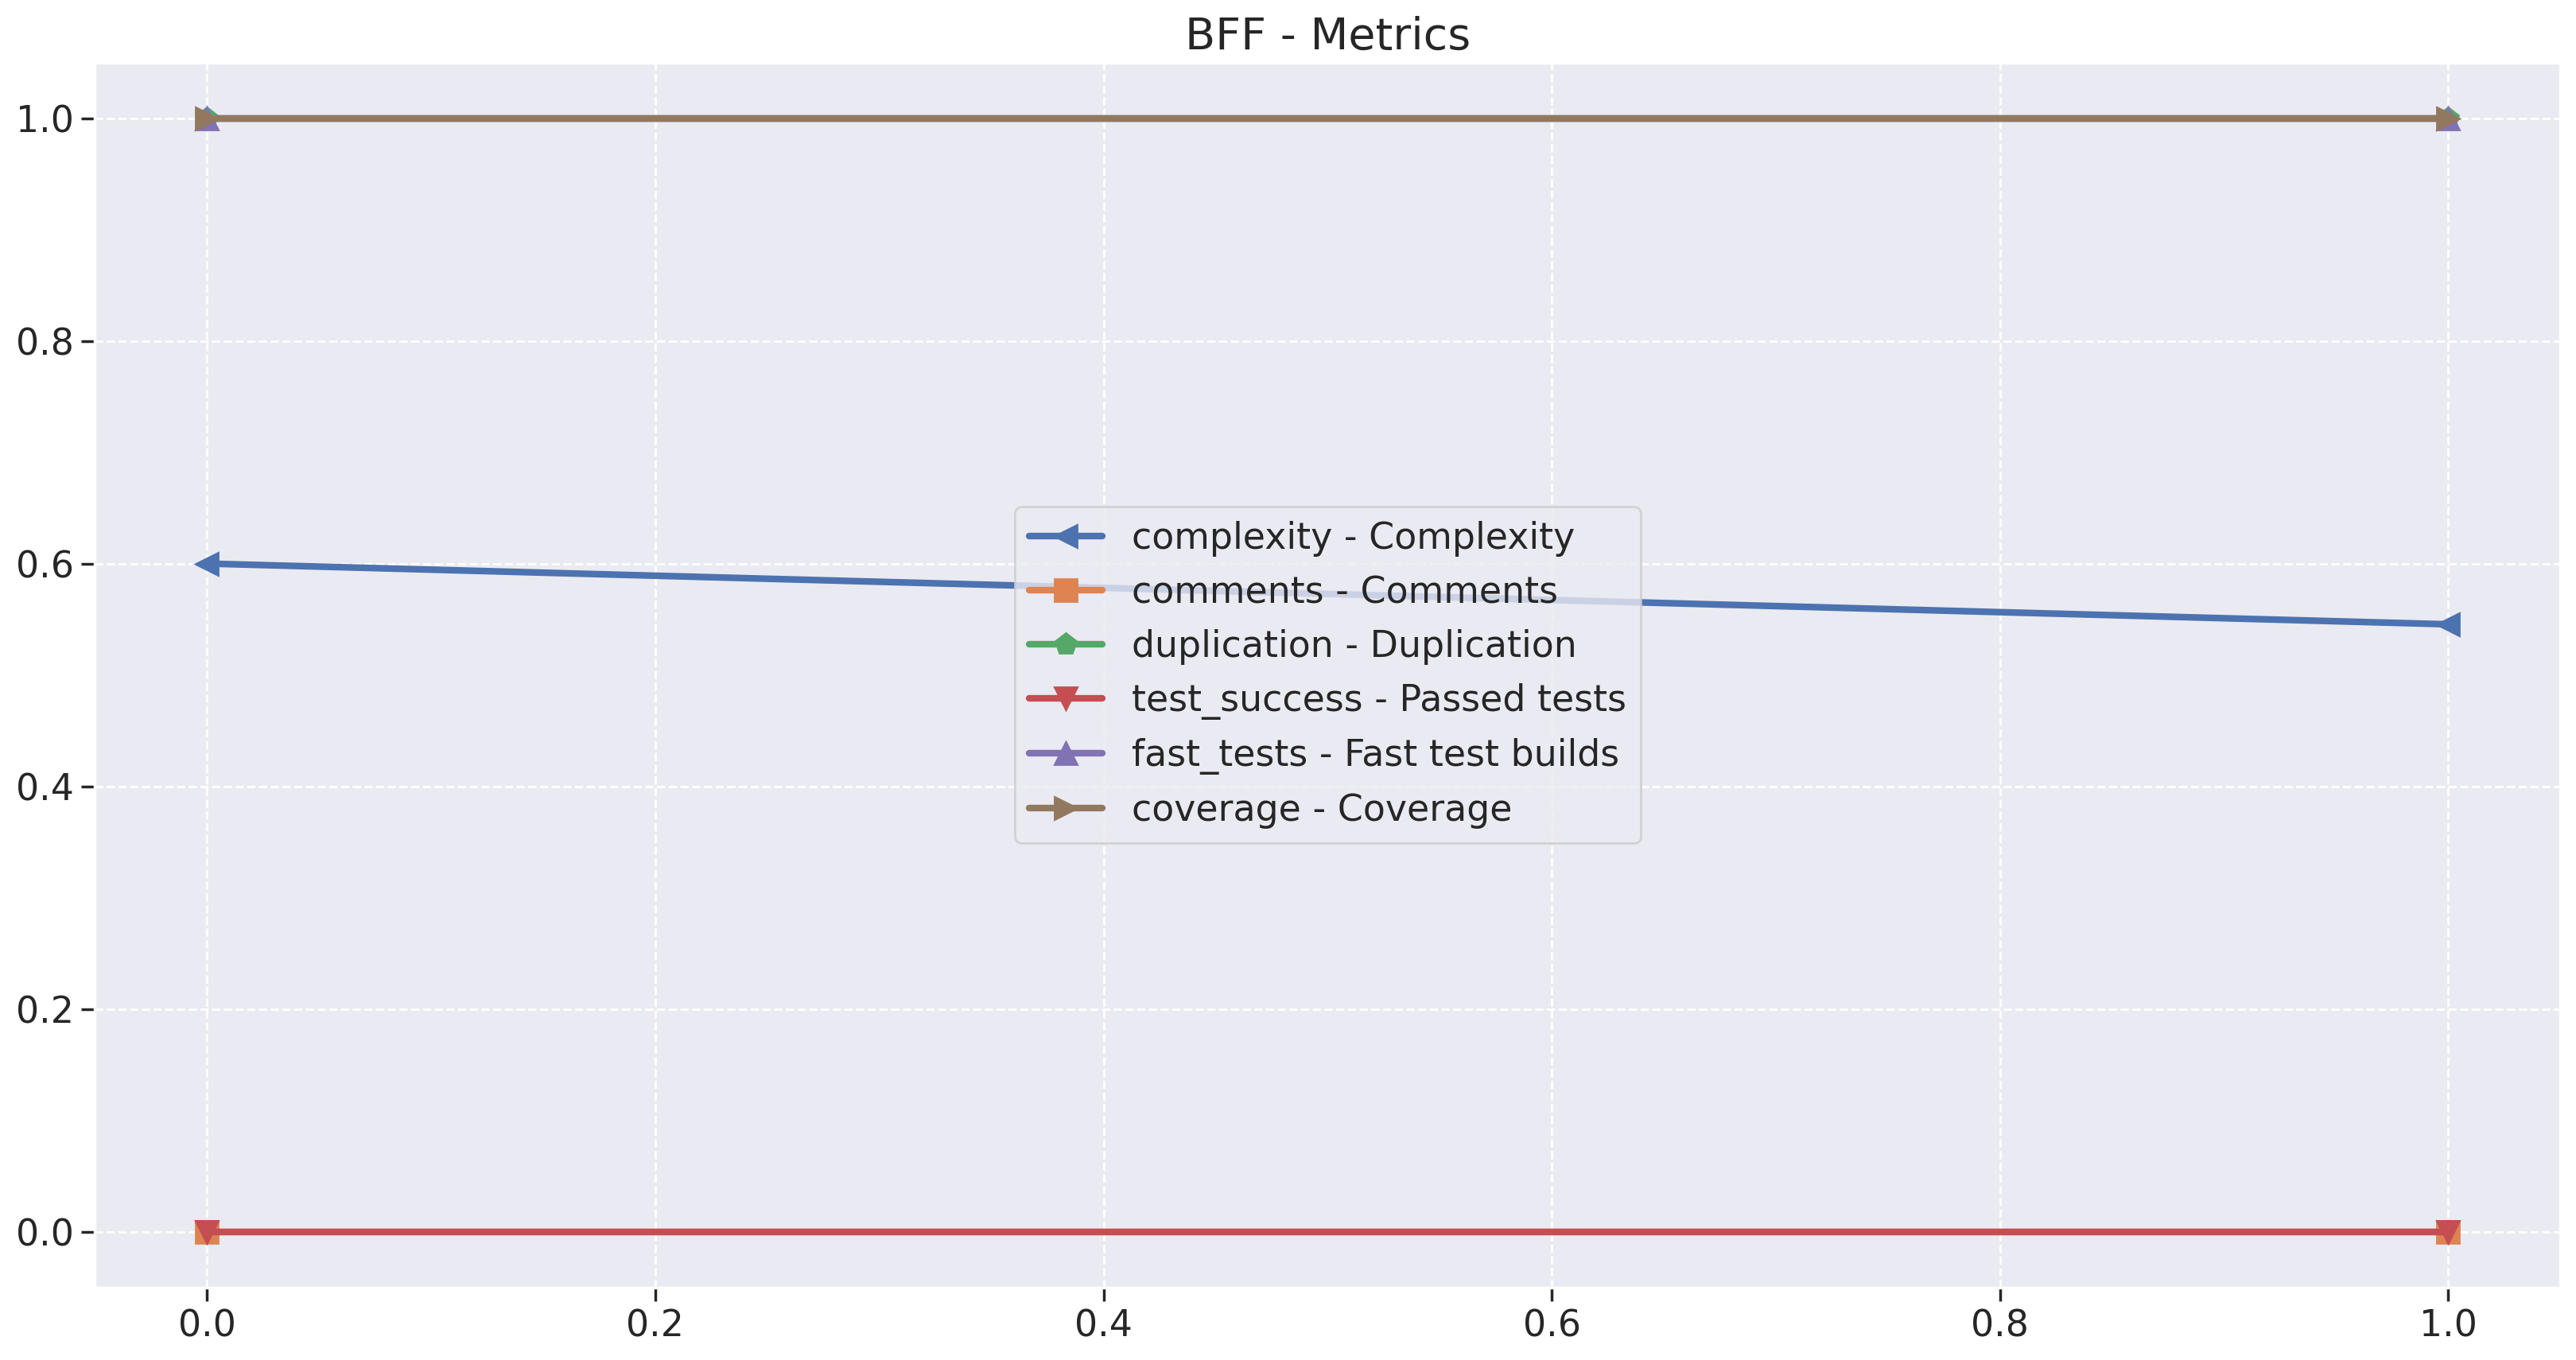

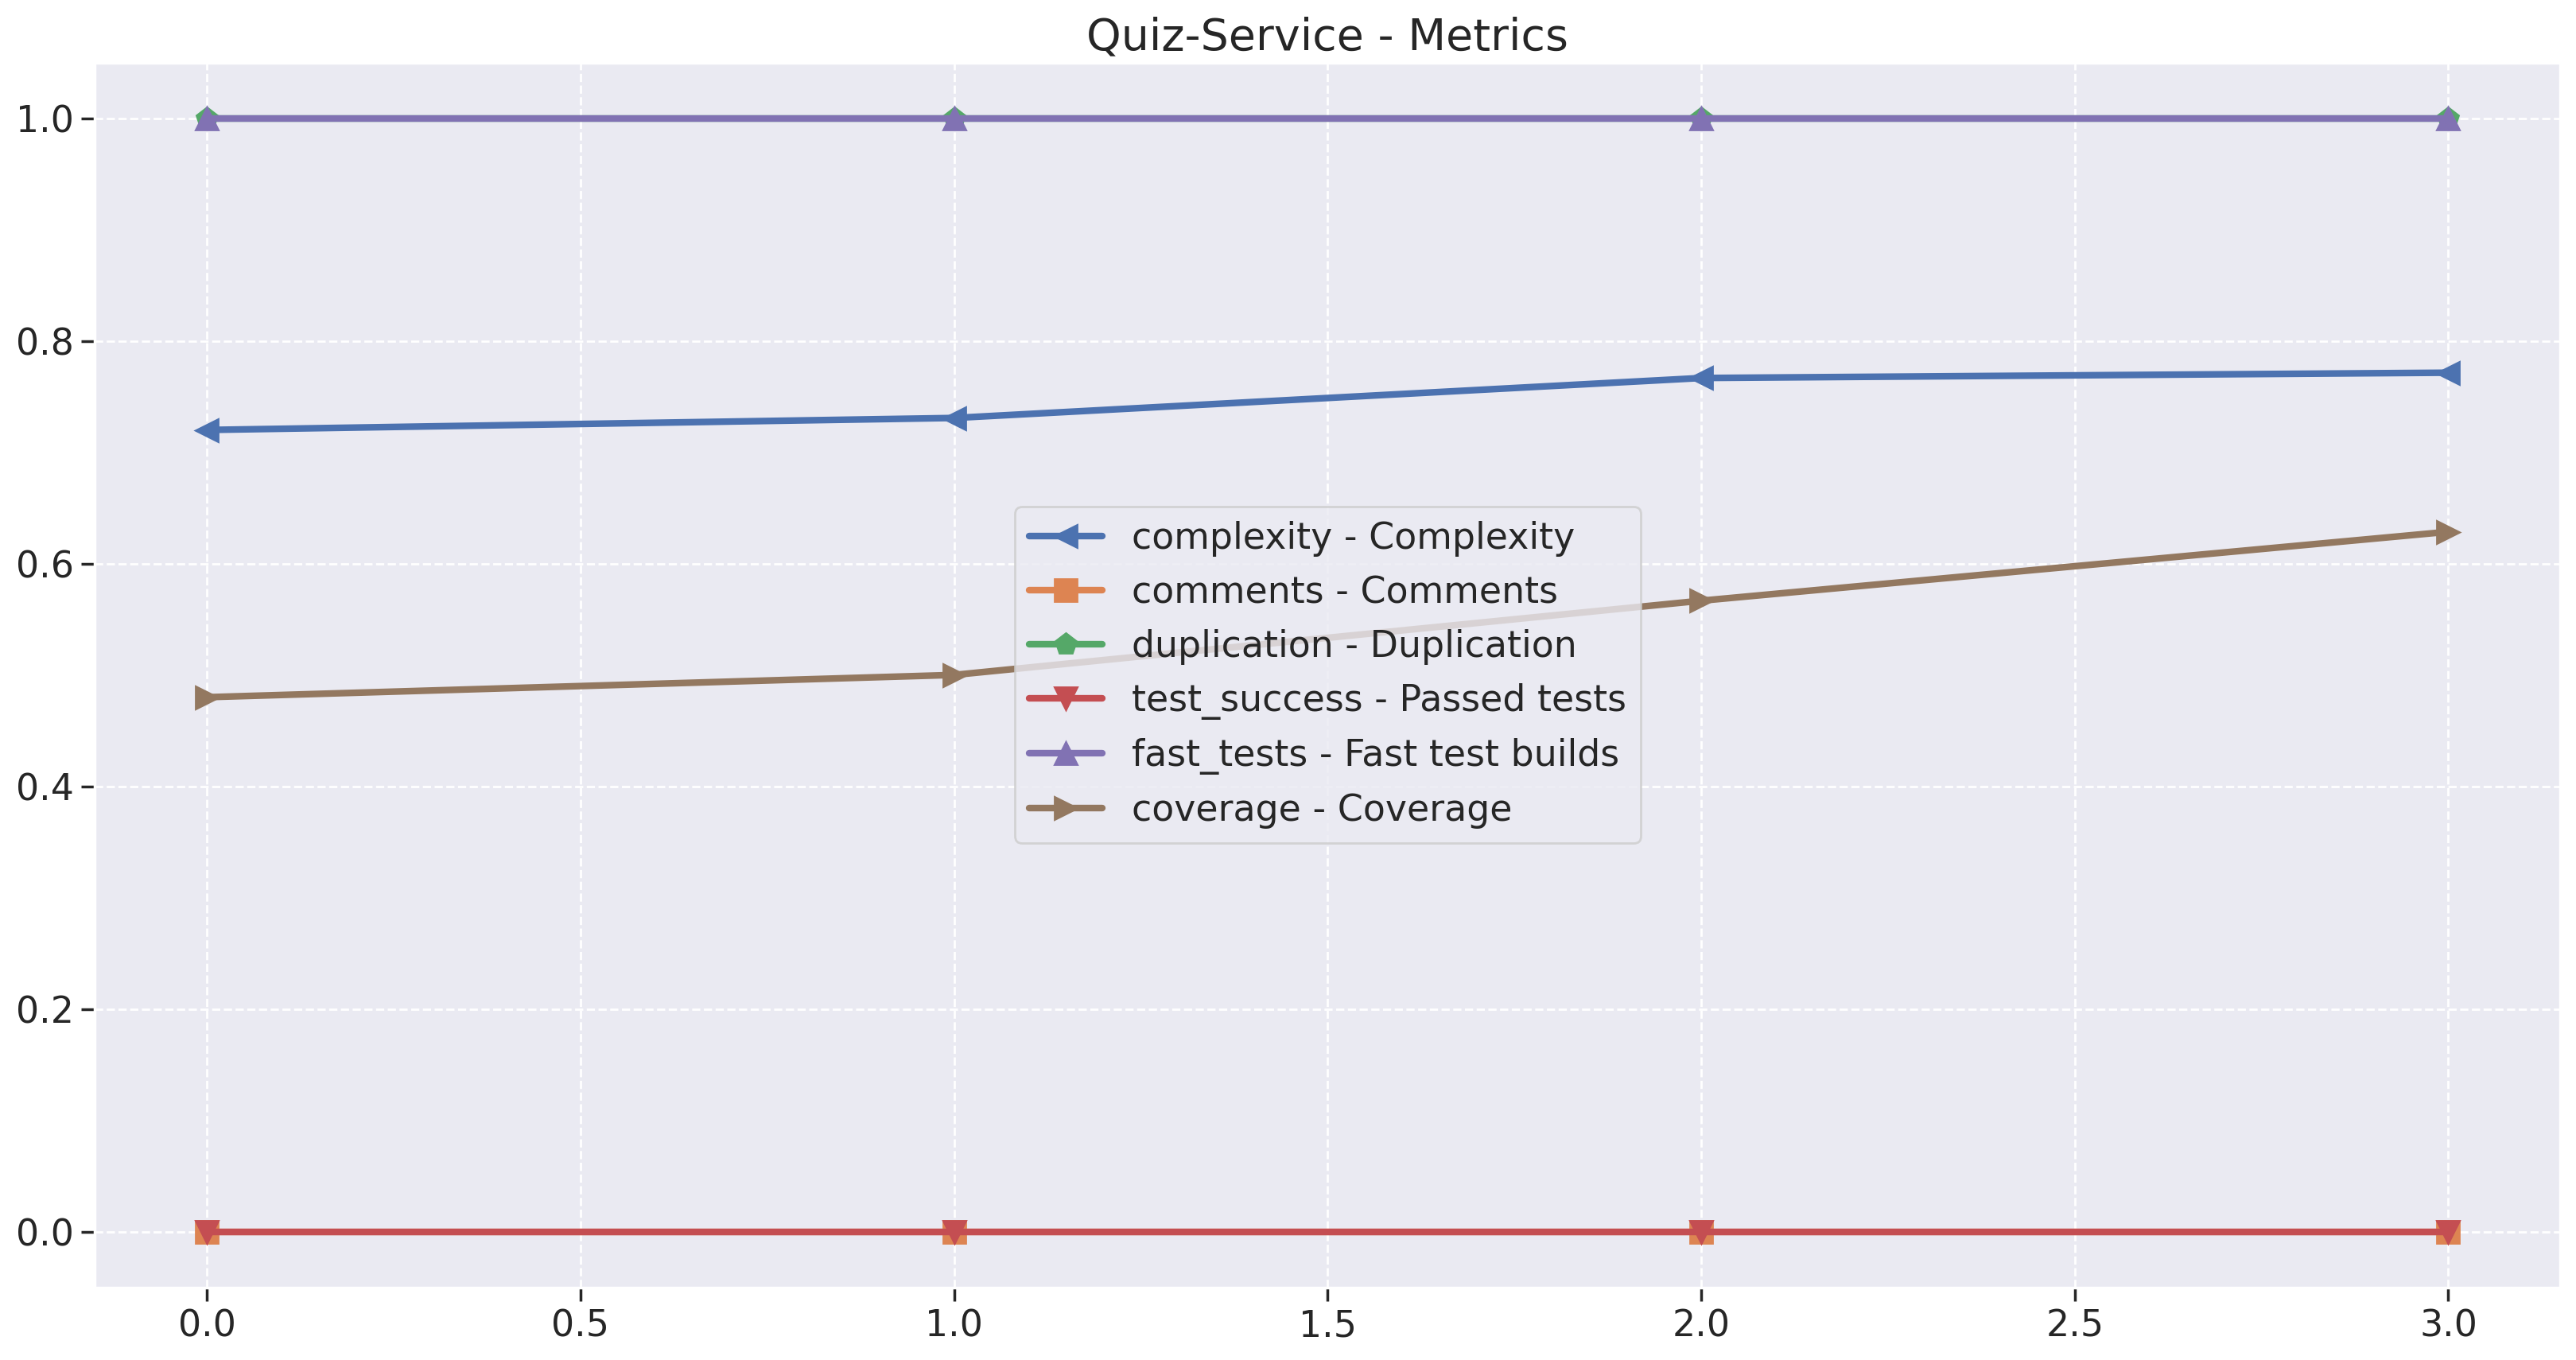

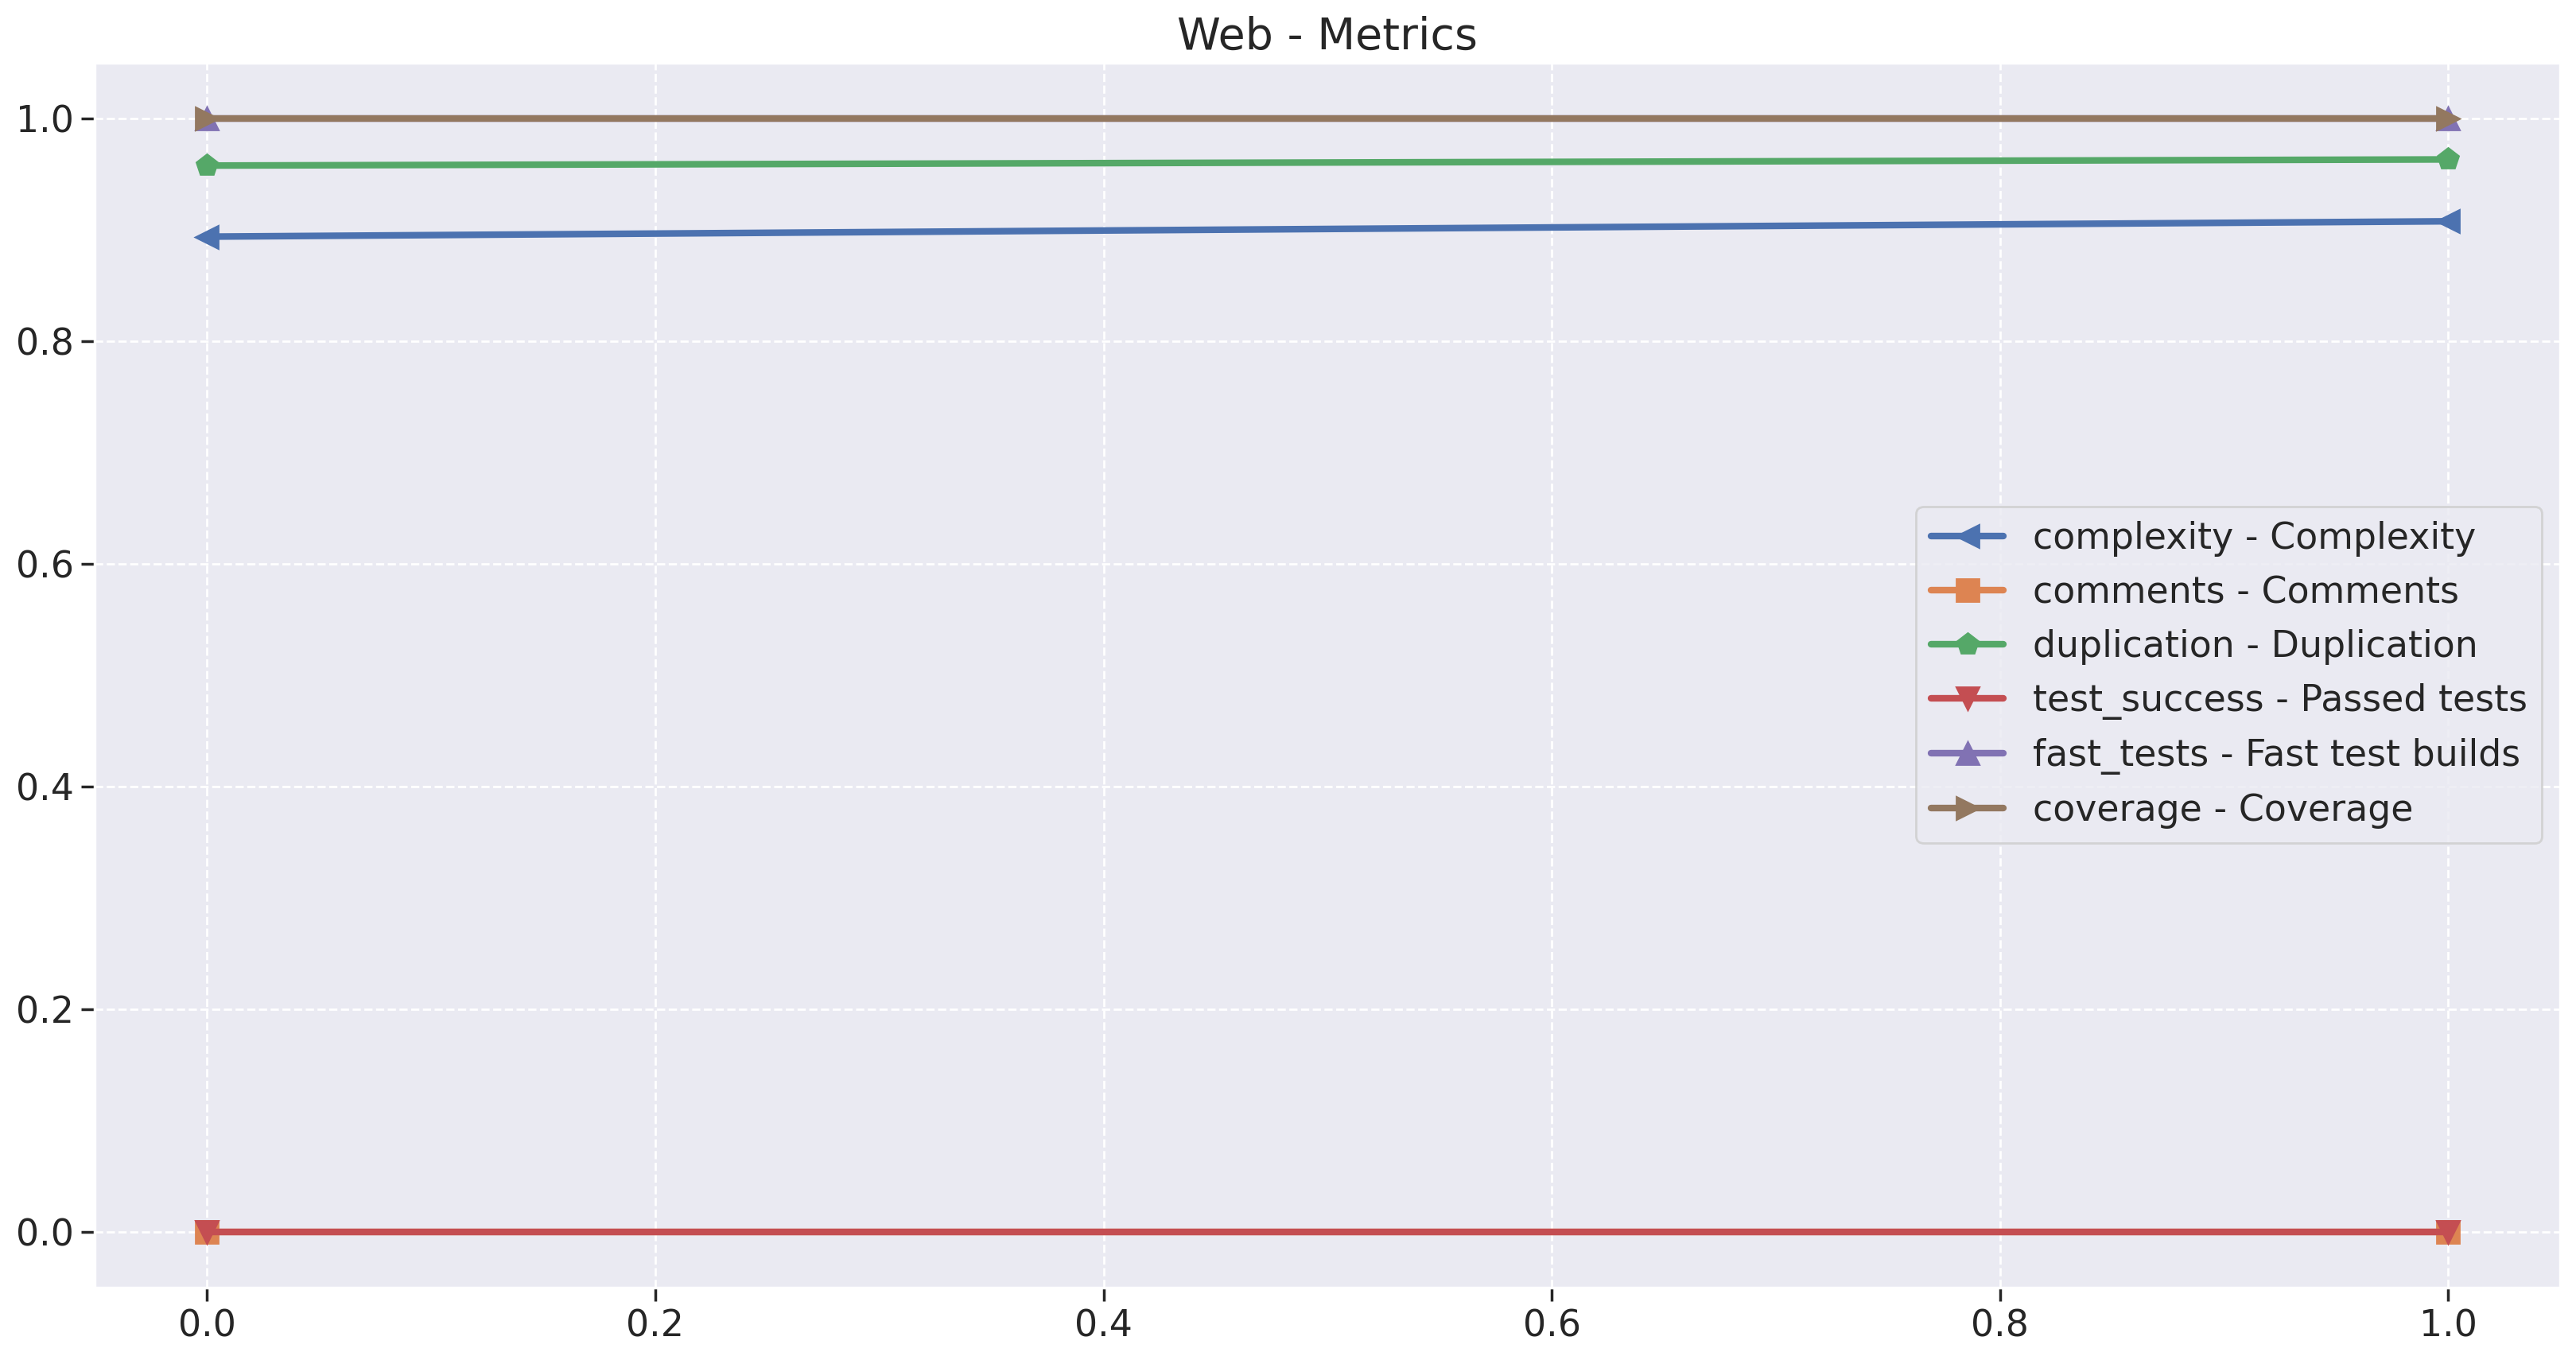

In [73]:
for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))

    plt.plot(data['complexity'], linewidth=3, marker='<', markersize=10, label="complexity - Complexity")
    plt.plot(data['comments'], linewidth=3, marker='s', markersize=10, label="comments - Comments")
    plt.plot(data['duplication'], linewidth=3, marker='p', markersize=10, label="duplication - Duplication")
    plt.plot(data['test_success'], linewidth=3, marker='v', markersize=10, label="test_success - Passed tests")
    plt.plot(data['fast_tests'], linewidth=3, marker='^', markersize=10, label="fast_tests - Fast test builds")
    plt.plot(data['coverage'], linewidth=3, marker='>', markersize=10, label="coverage - Coverage")

    plt.title(f"{name} - Metrics", fontsize=20)
    plt.legend(loc='best')
    plt.show()


## Quality factor and aspect aggregation


In [74]:
psc1 = 1
psc2 = 1
pc1 = 0.5
pc2 = 0.5
pm1 = 0.33
pm2 = 0.33
pm3 = 0.33
pm4 = 0.25
pm5 = 0.25
pm6 = 0.5


# Here you will need to create the code_quality and testing_status metrics for each repository.

for name, data in metrics.items():
    data['code_quality'] = ((data['complexity']*pm1) + (data['comments']*pm2) + (data['duplication']*pm3)) * psc1
    data['testing_status'] = ((data['test_success']*pm4) + (data['fast_tests']*pm5) + (data['coverage']*pm6)) * psc2


### Code Quality visualization


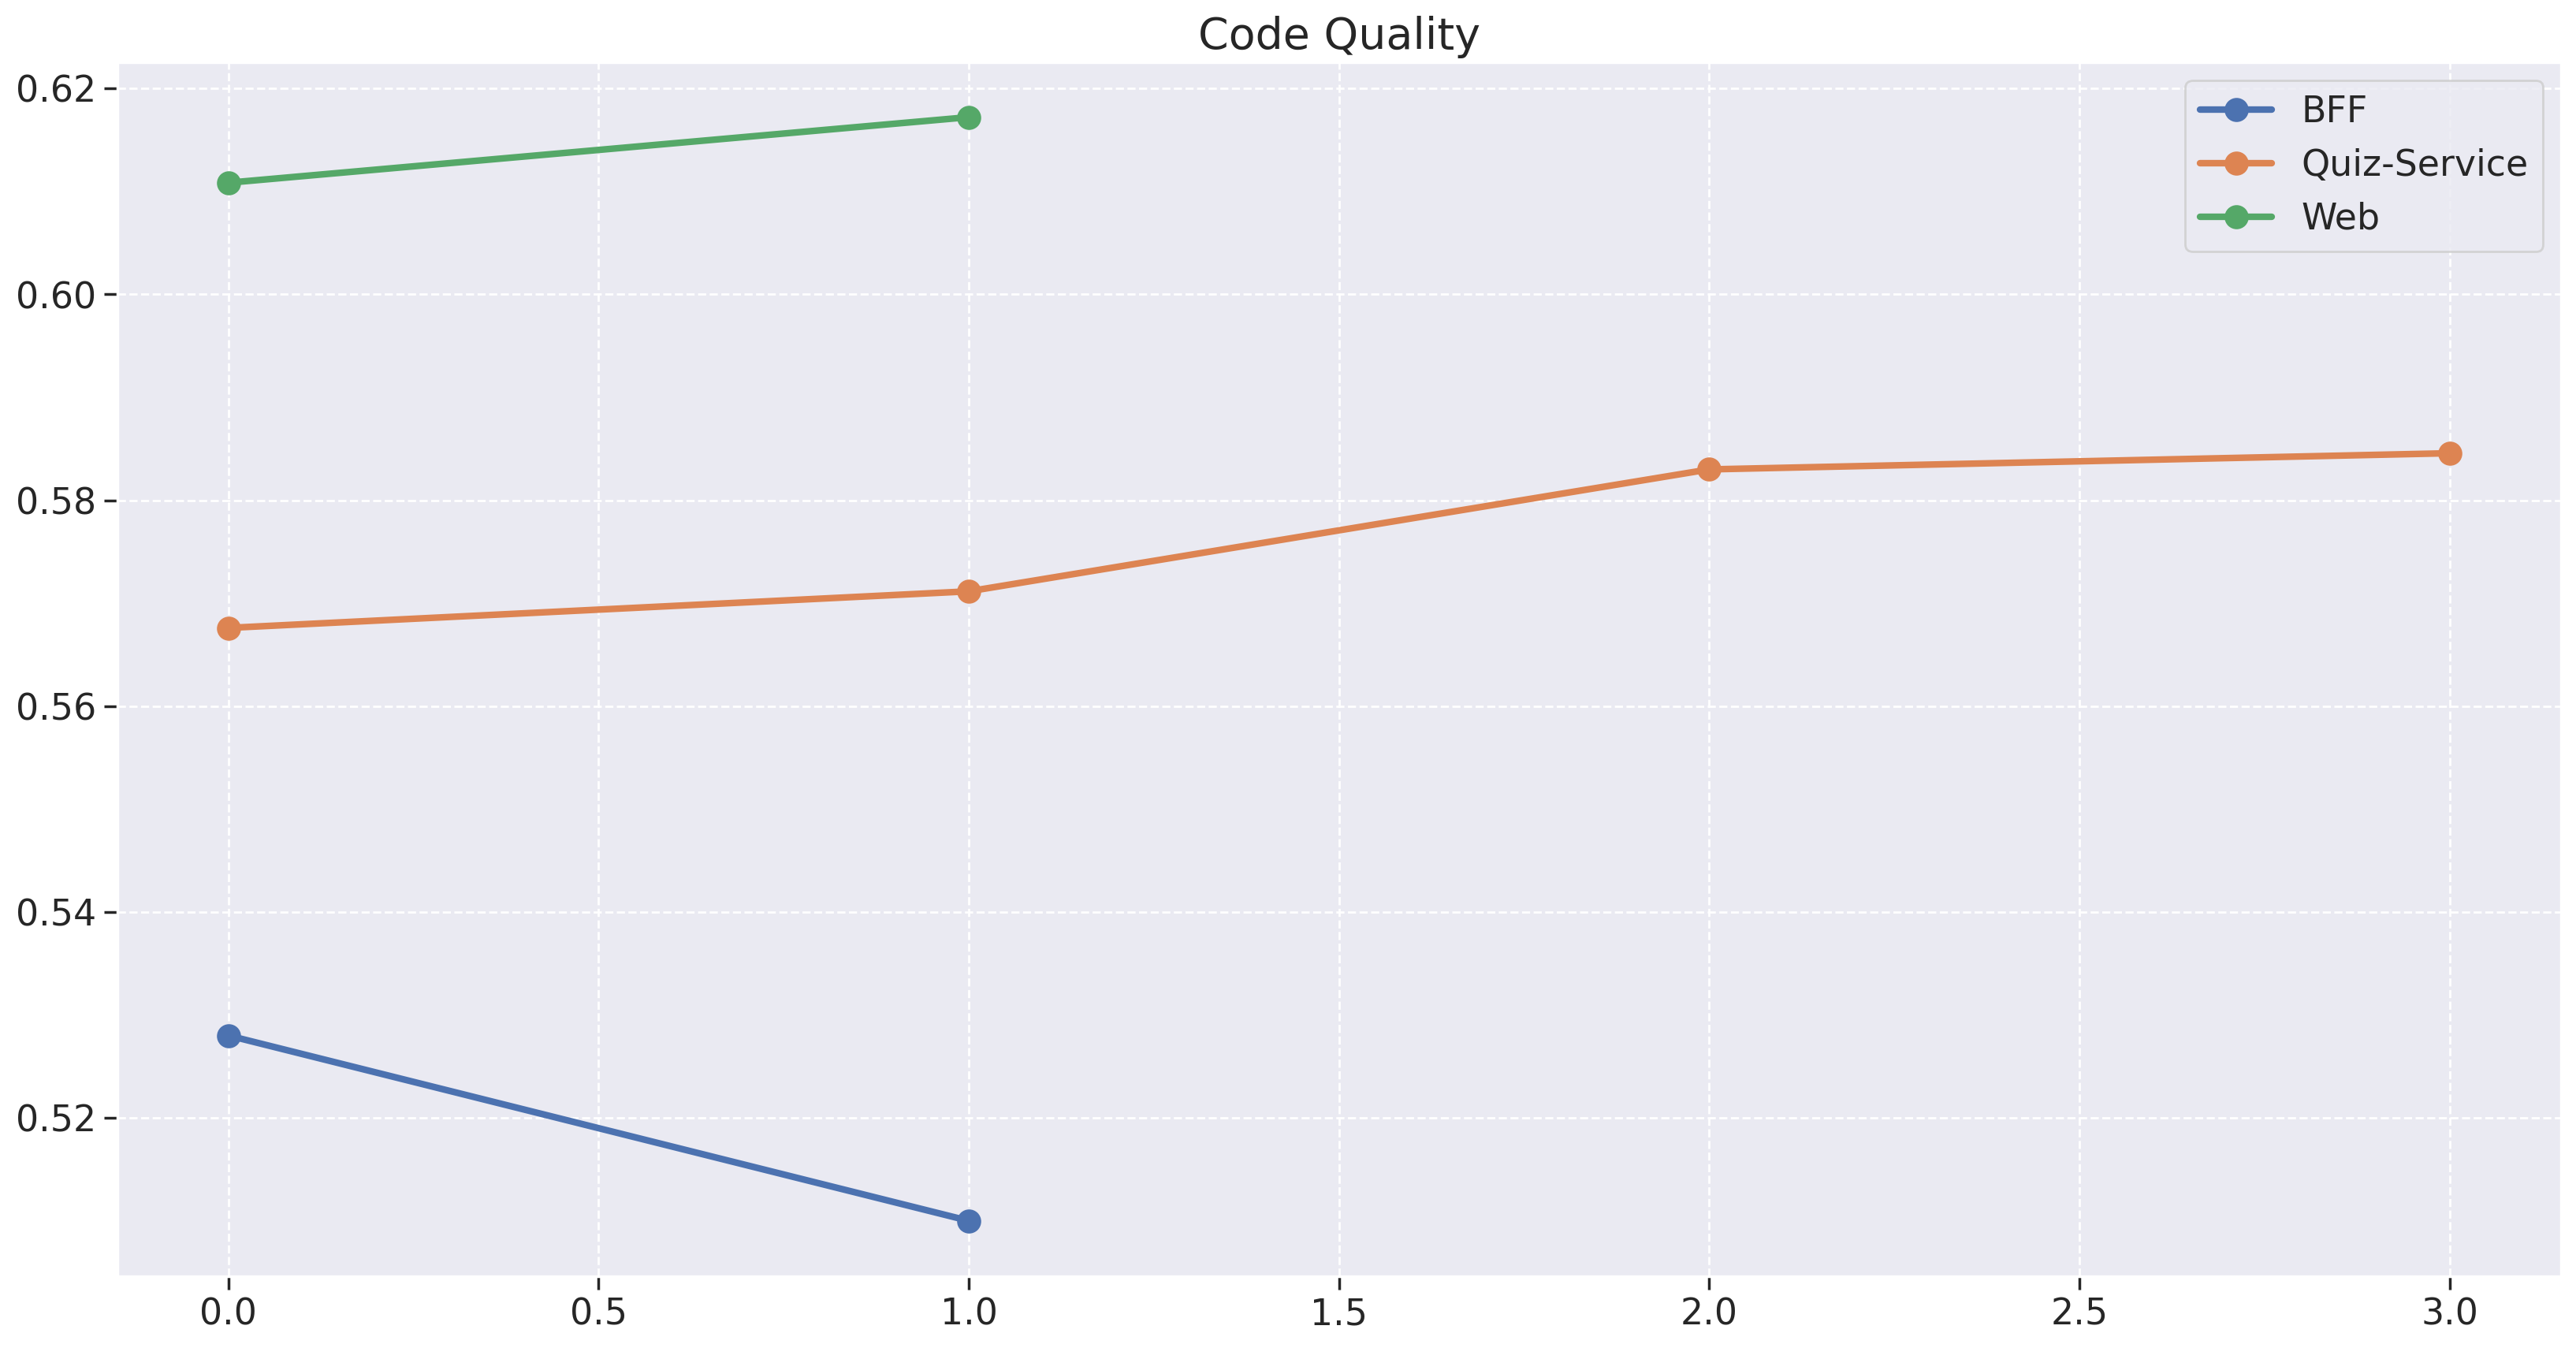

In [75]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['code_quality'], linewidth=3, marker='o', markersize=10, label=name)

plt.title("Code Quality", fontsize=20)
plt.legend(loc='best')
plt.show()


### Testing Status visualization


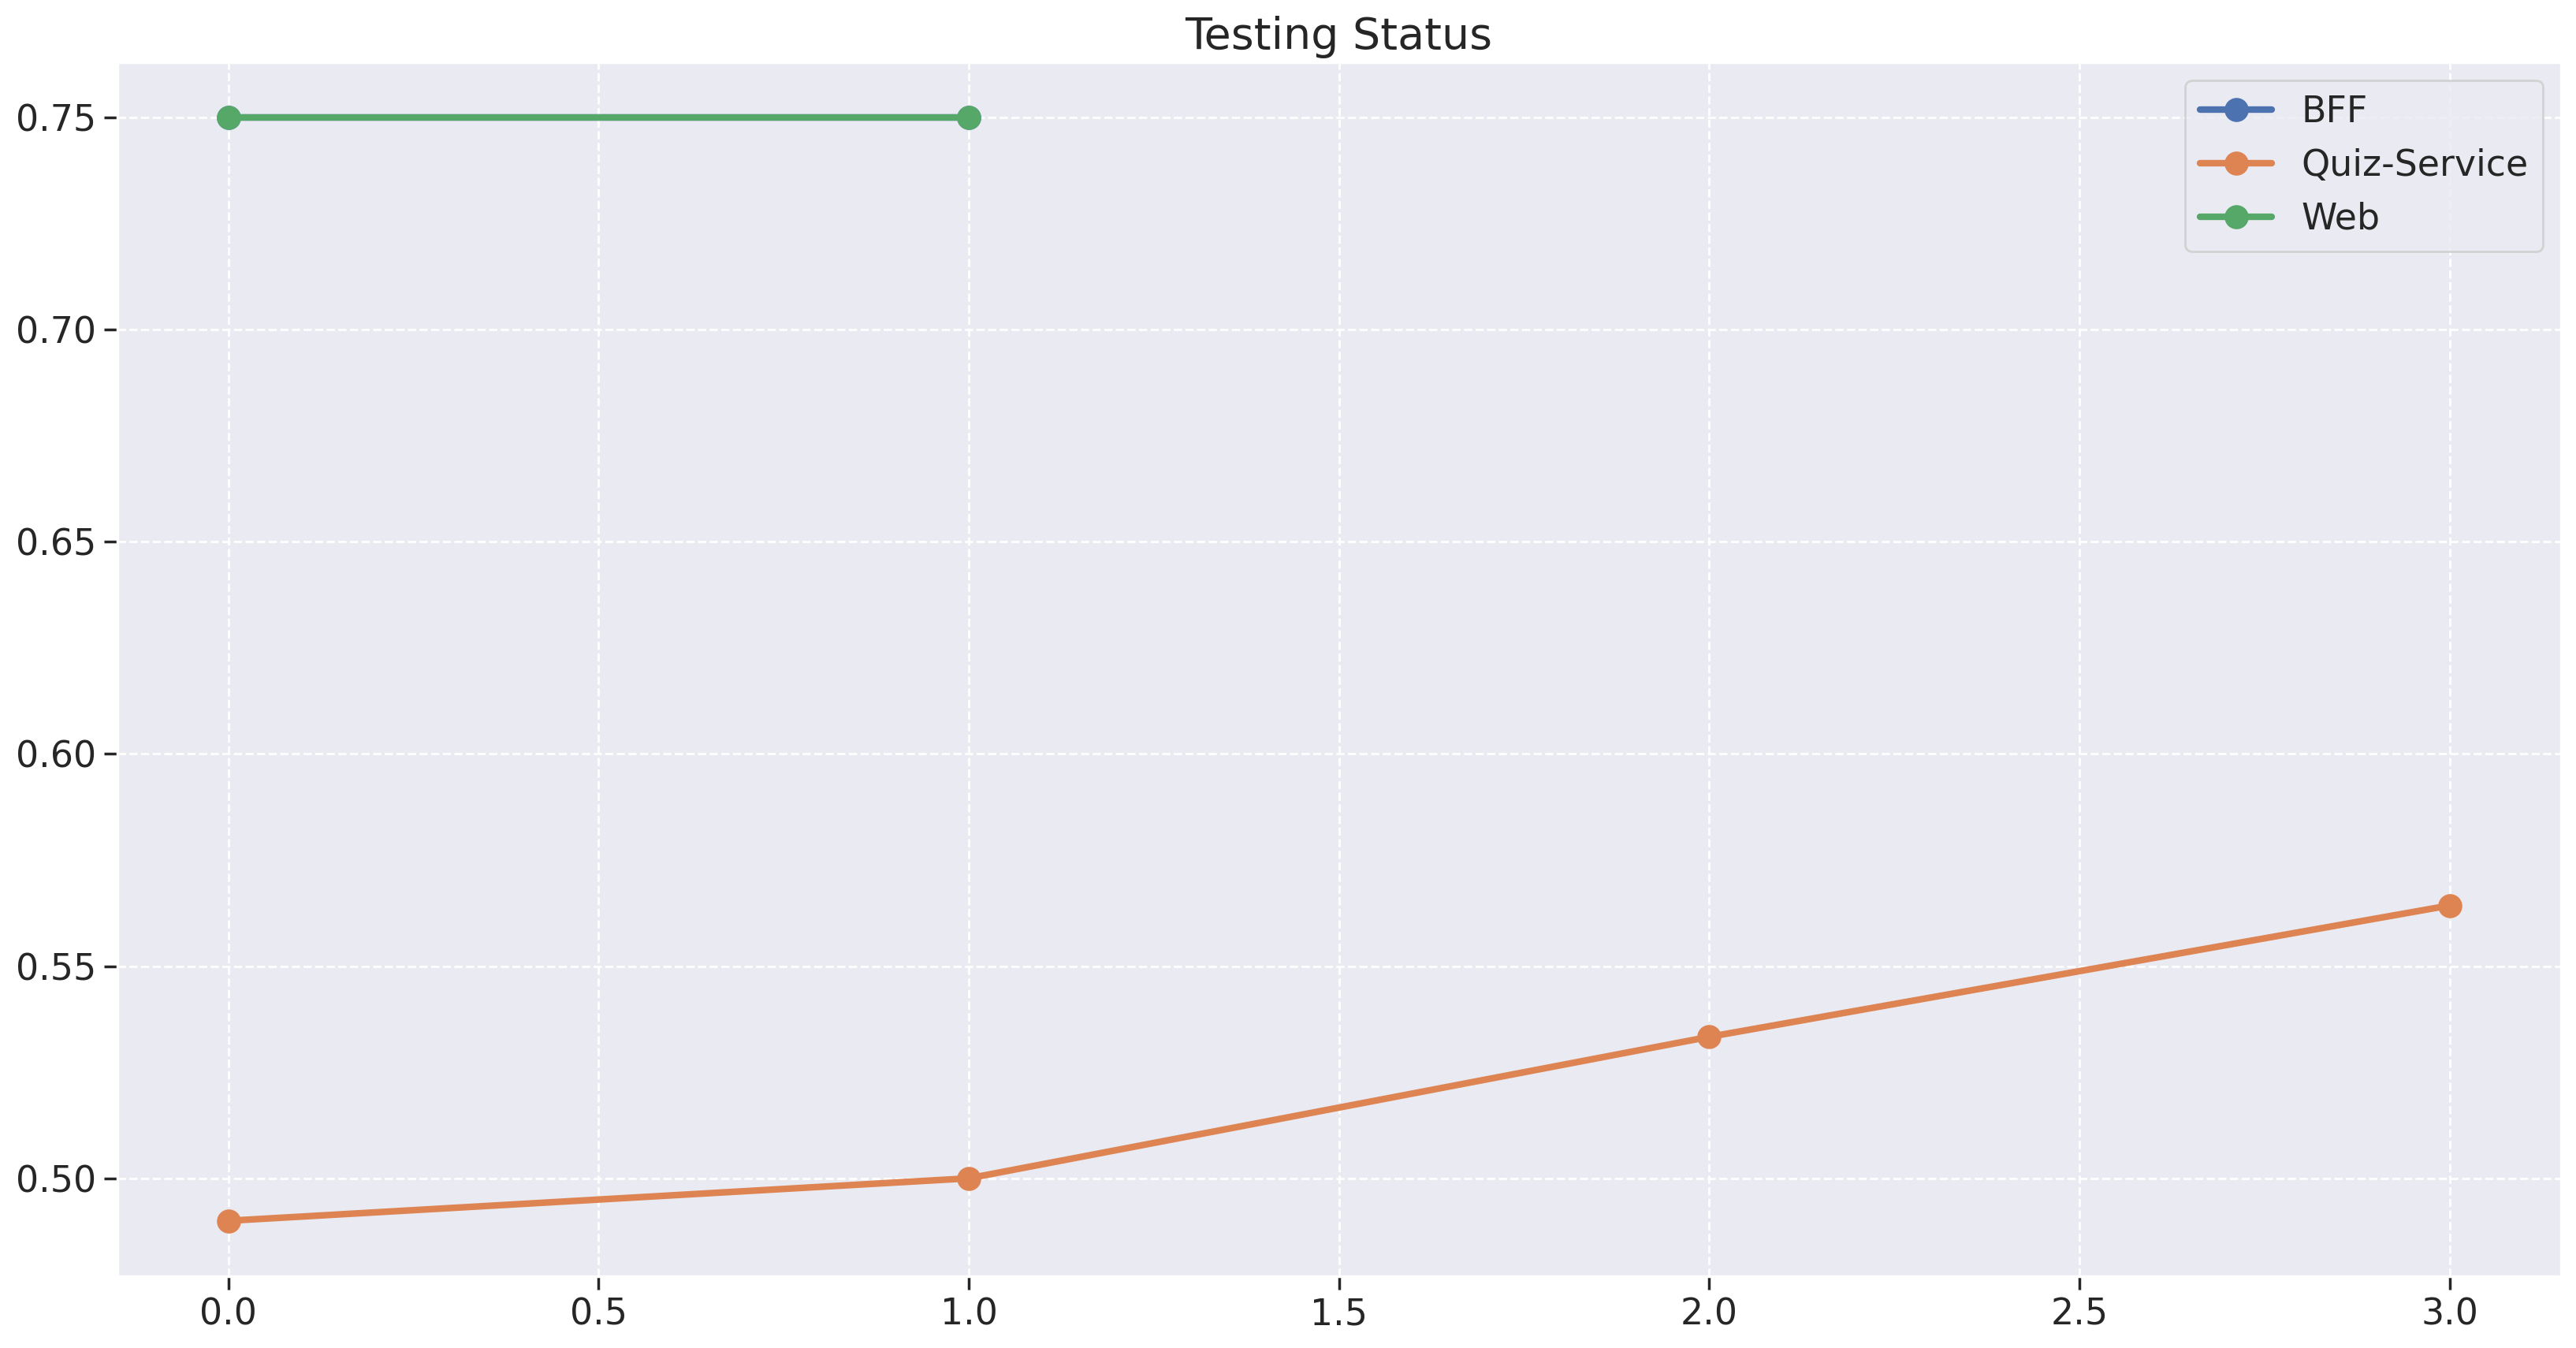

In [76]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['testing_status'], linewidth=3, marker='o', markersize=10, label=name)

plt.title("Testing Status", fontsize=20)
plt.legend(loc='best')
plt.show()


### Aggregations


In [77]:
for name, data in metrics.items():
    data['Maintainability'] = data['code_quality'] * pc1
    data['Reliability'] = data['testing_status'] * pc2
    data['total'] = data['Maintainability'] + data['Reliability']


## Repositories analysis


In [78]:
def get_characteristc_stats(repo_series):
    return {
        'mean': repo_series.mean(),
        'mode': repo_series.mode(),
        'median': repo_series.median(),
        'std': repo_series.std(),
        'var': repo_series.var(),
        'min': repo_series.min(),
        'max': repo_series.max()
    }


In [79]:
def analysis(metrics, name):
    maintainability_stats = pd.DataFrame(get_characteristc_stats(metrics["Maintainability"]),
                                     columns=['mean', 'mode', 'median', 'std', 'var', 'min', 'max'])

    reliability_stats = pd.DataFrame(get_characteristc_stats(metrics["Reliability"]),
                                 columns=['mean', 'mode', 'median', 'std', 'var', 'min', 'max'])


    print("Maintainability Stats")
    print(maintainability_stats.to_string(index=False))

    print("Reliability Stats")
    print(reliability_stats.to_string(index=False))

    fig = plt.figure(figsize=(20, 10))

    plt.plot(metrics['Maintainability'], linewidth=3, marker='o', markersize=10, label="Maintainability")
    plt.plot(metrics['Reliability'], linewidth=3, marker='*', markersize=10, label="Reliability")

    plt.ylim(0.1,1.1)
    plt.title(f'{name} - Maintainability and Reliability', fontsize=20)
    plt.legend(loc='best')
    plt.show()

    fig = plt.figure(figsize=(20, 10))

    plt.plot(metrics['total'], linewidth=3, marker='X', markersize=5)

    plt.ylim(0.1,1.1)
    plt.title(f'{name} - Total', fontsize=20)
    plt.show()


### Analysis loop in each repo


BFF
Maintainability Stats
  mean  mode  median      std      var   min   max
0.2595 0.255  0.2595 0.006364 0.000041 0.255 0.264
0.2595 0.264  0.2595 0.006364 0.000041 0.255 0.264
Reliability Stats
 mean  mode  median  std  var   min   max
0.375 0.375   0.375  0.0  0.0 0.375 0.375


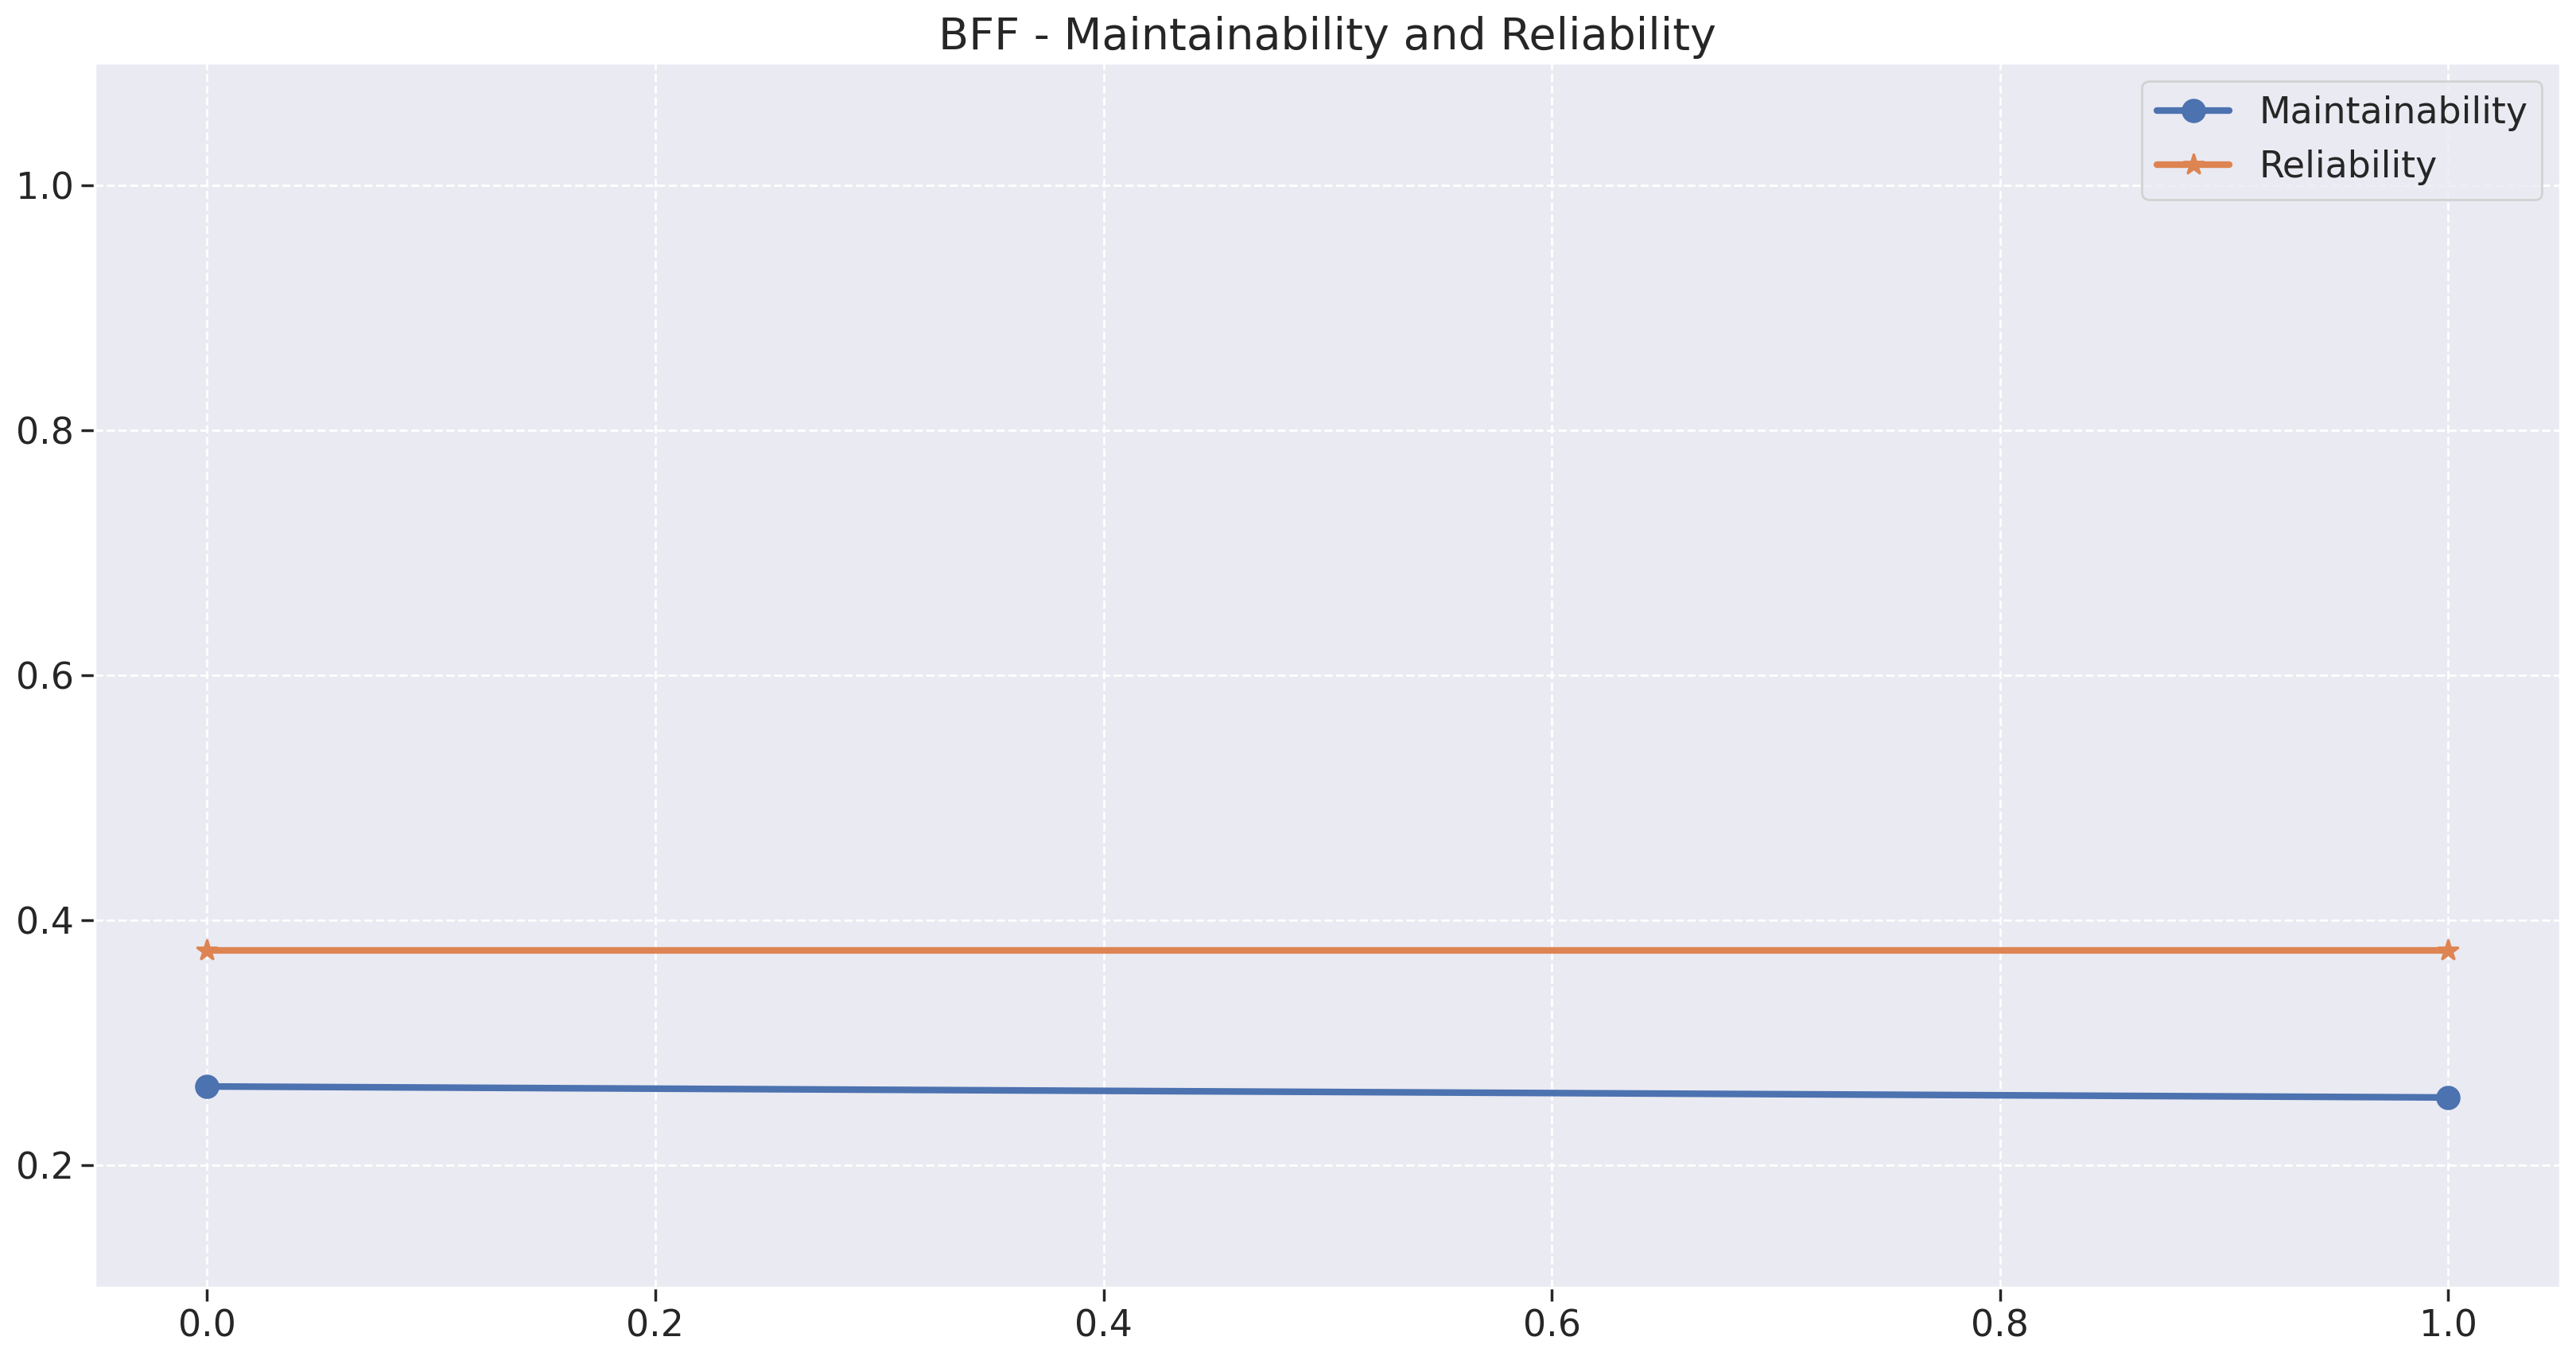

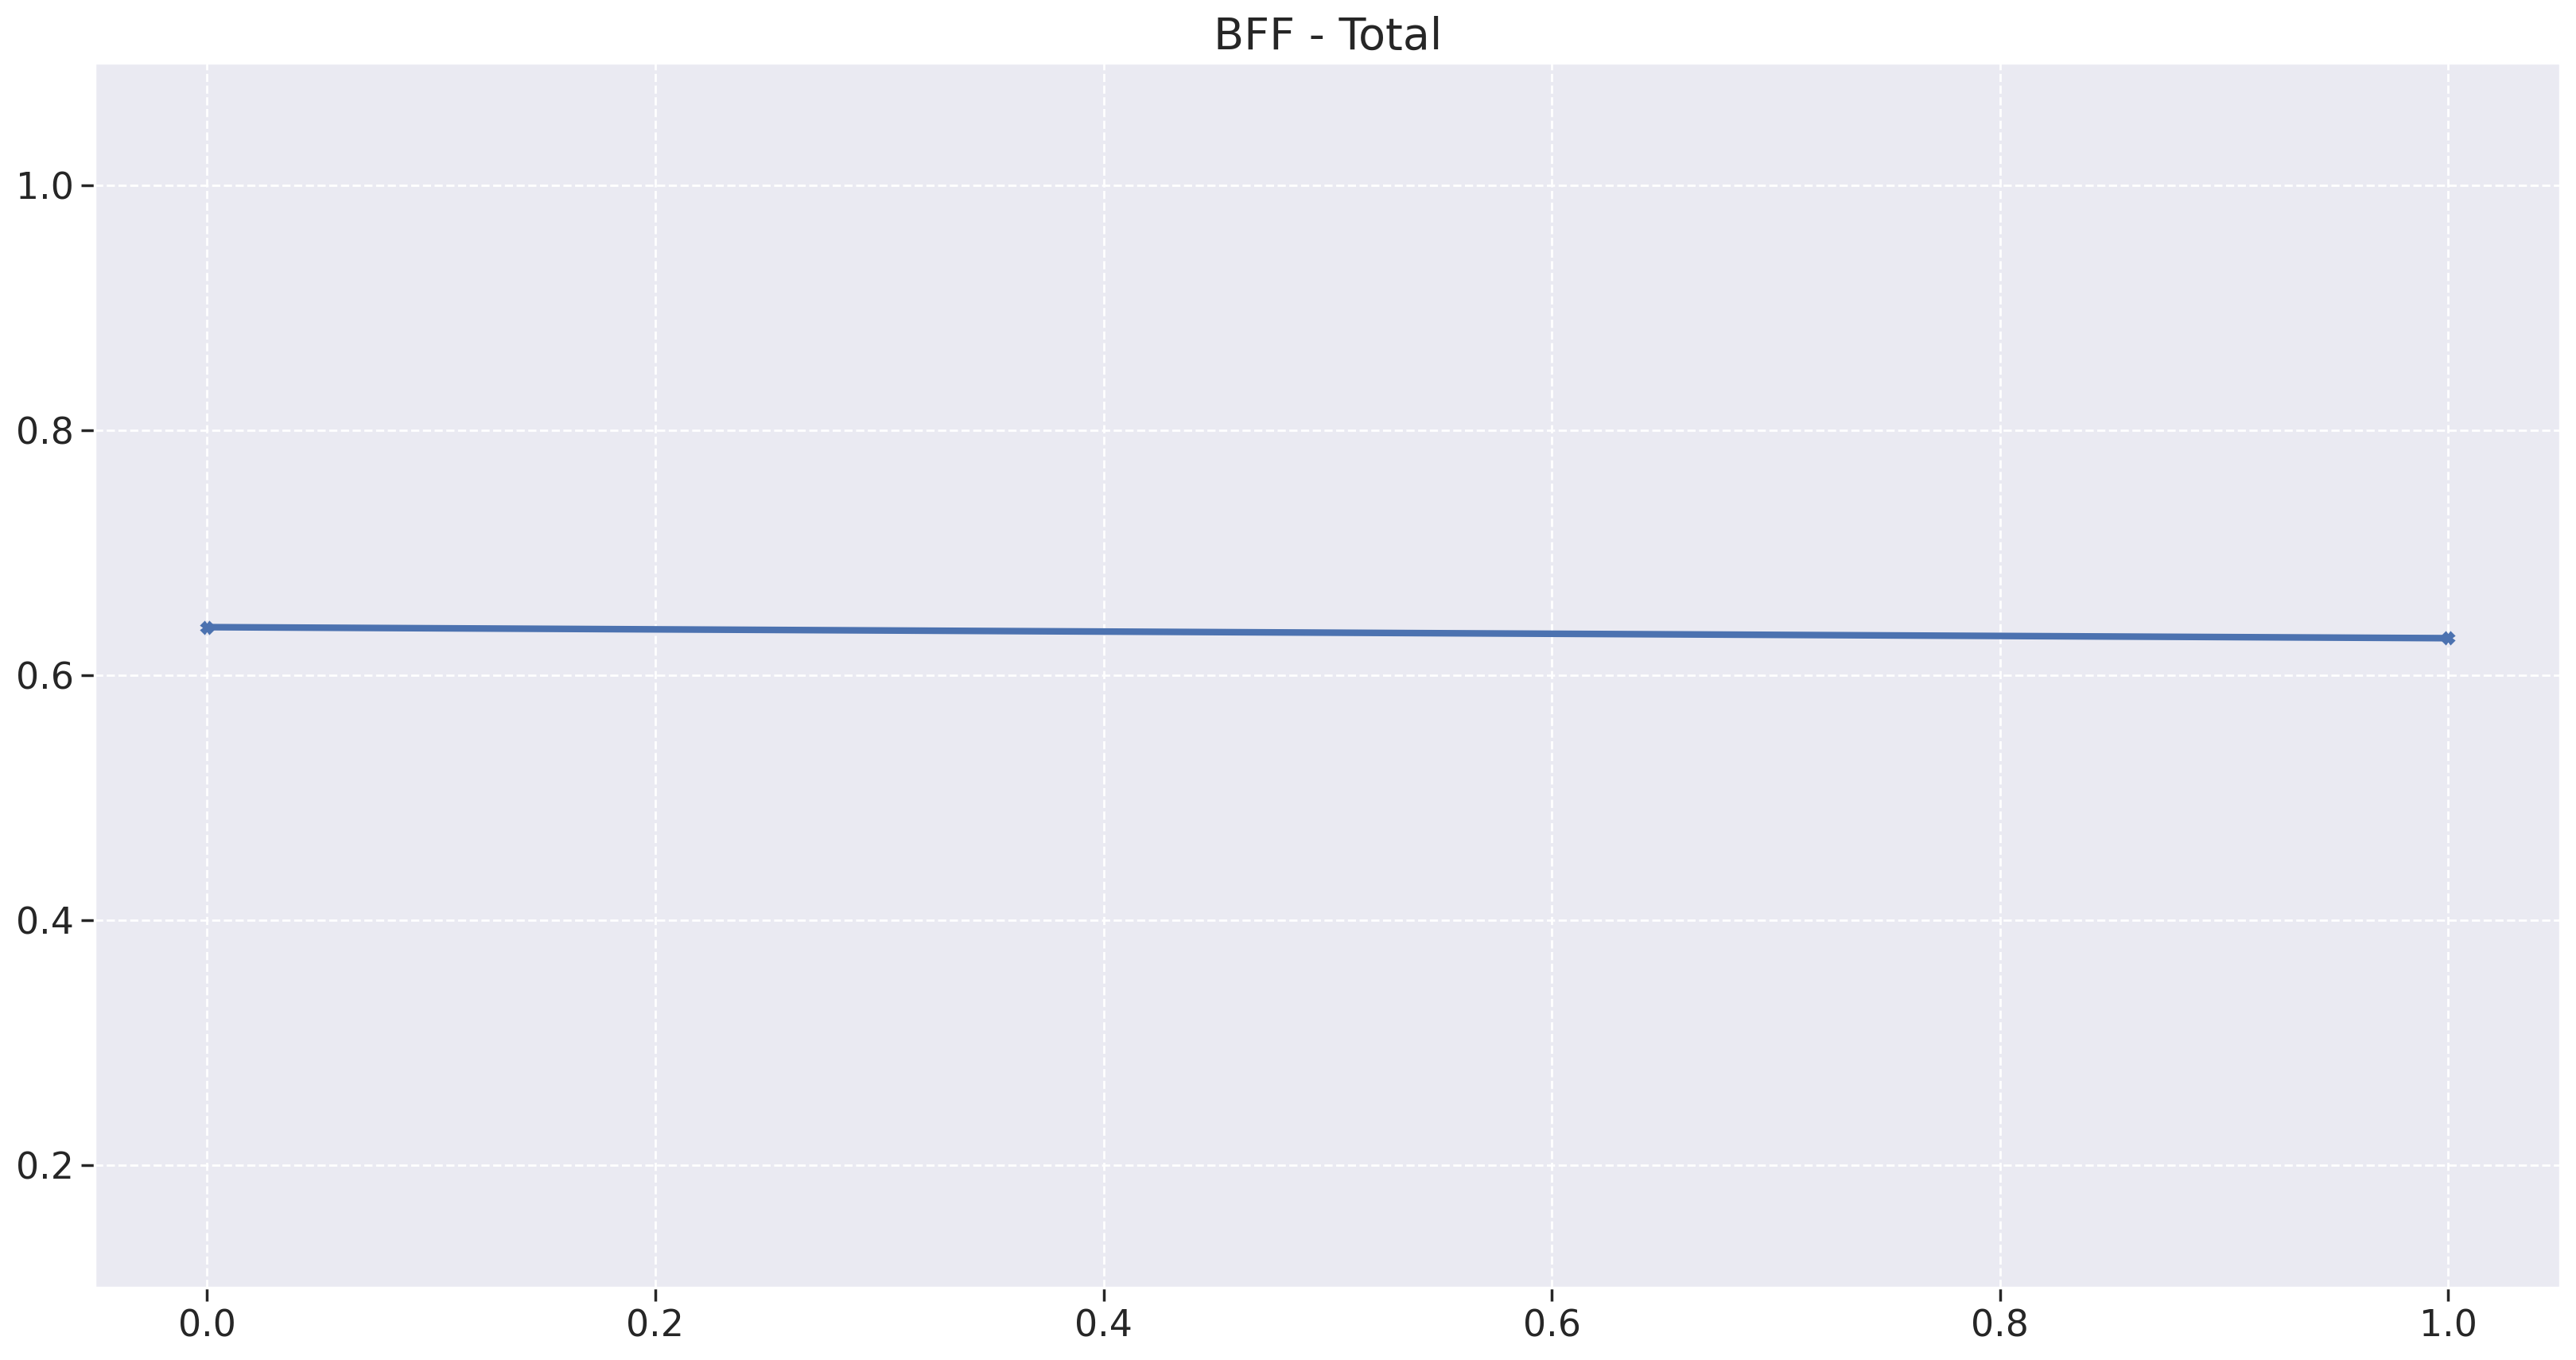

Quiz-Service
Maintainability Stats
    mean     mode   median      std      var    min      max
0.288291 0.283800 0.288538 0.004234 0.000018 0.2838 0.292286
0.288291 0.285577 0.288538 0.004234 0.000018 0.2838 0.292286
0.288291 0.291500 0.288538 0.004234 0.000018 0.2838 0.292286
0.288291 0.292286 0.288538 0.004234 0.000018 0.2838 0.292286
Reliability Stats
    mean     mode   median      std      var   min      max
0.260952 0.245000 0.258333 0.016893 0.000285 0.245 0.282143
0.260952 0.250000 0.258333 0.016893 0.000285 0.245 0.282143
0.260952 0.266667 0.258333 0.016893 0.000285 0.245 0.282143
0.260952 0.282143 0.258333 0.016893 0.000285 0.245 0.282143


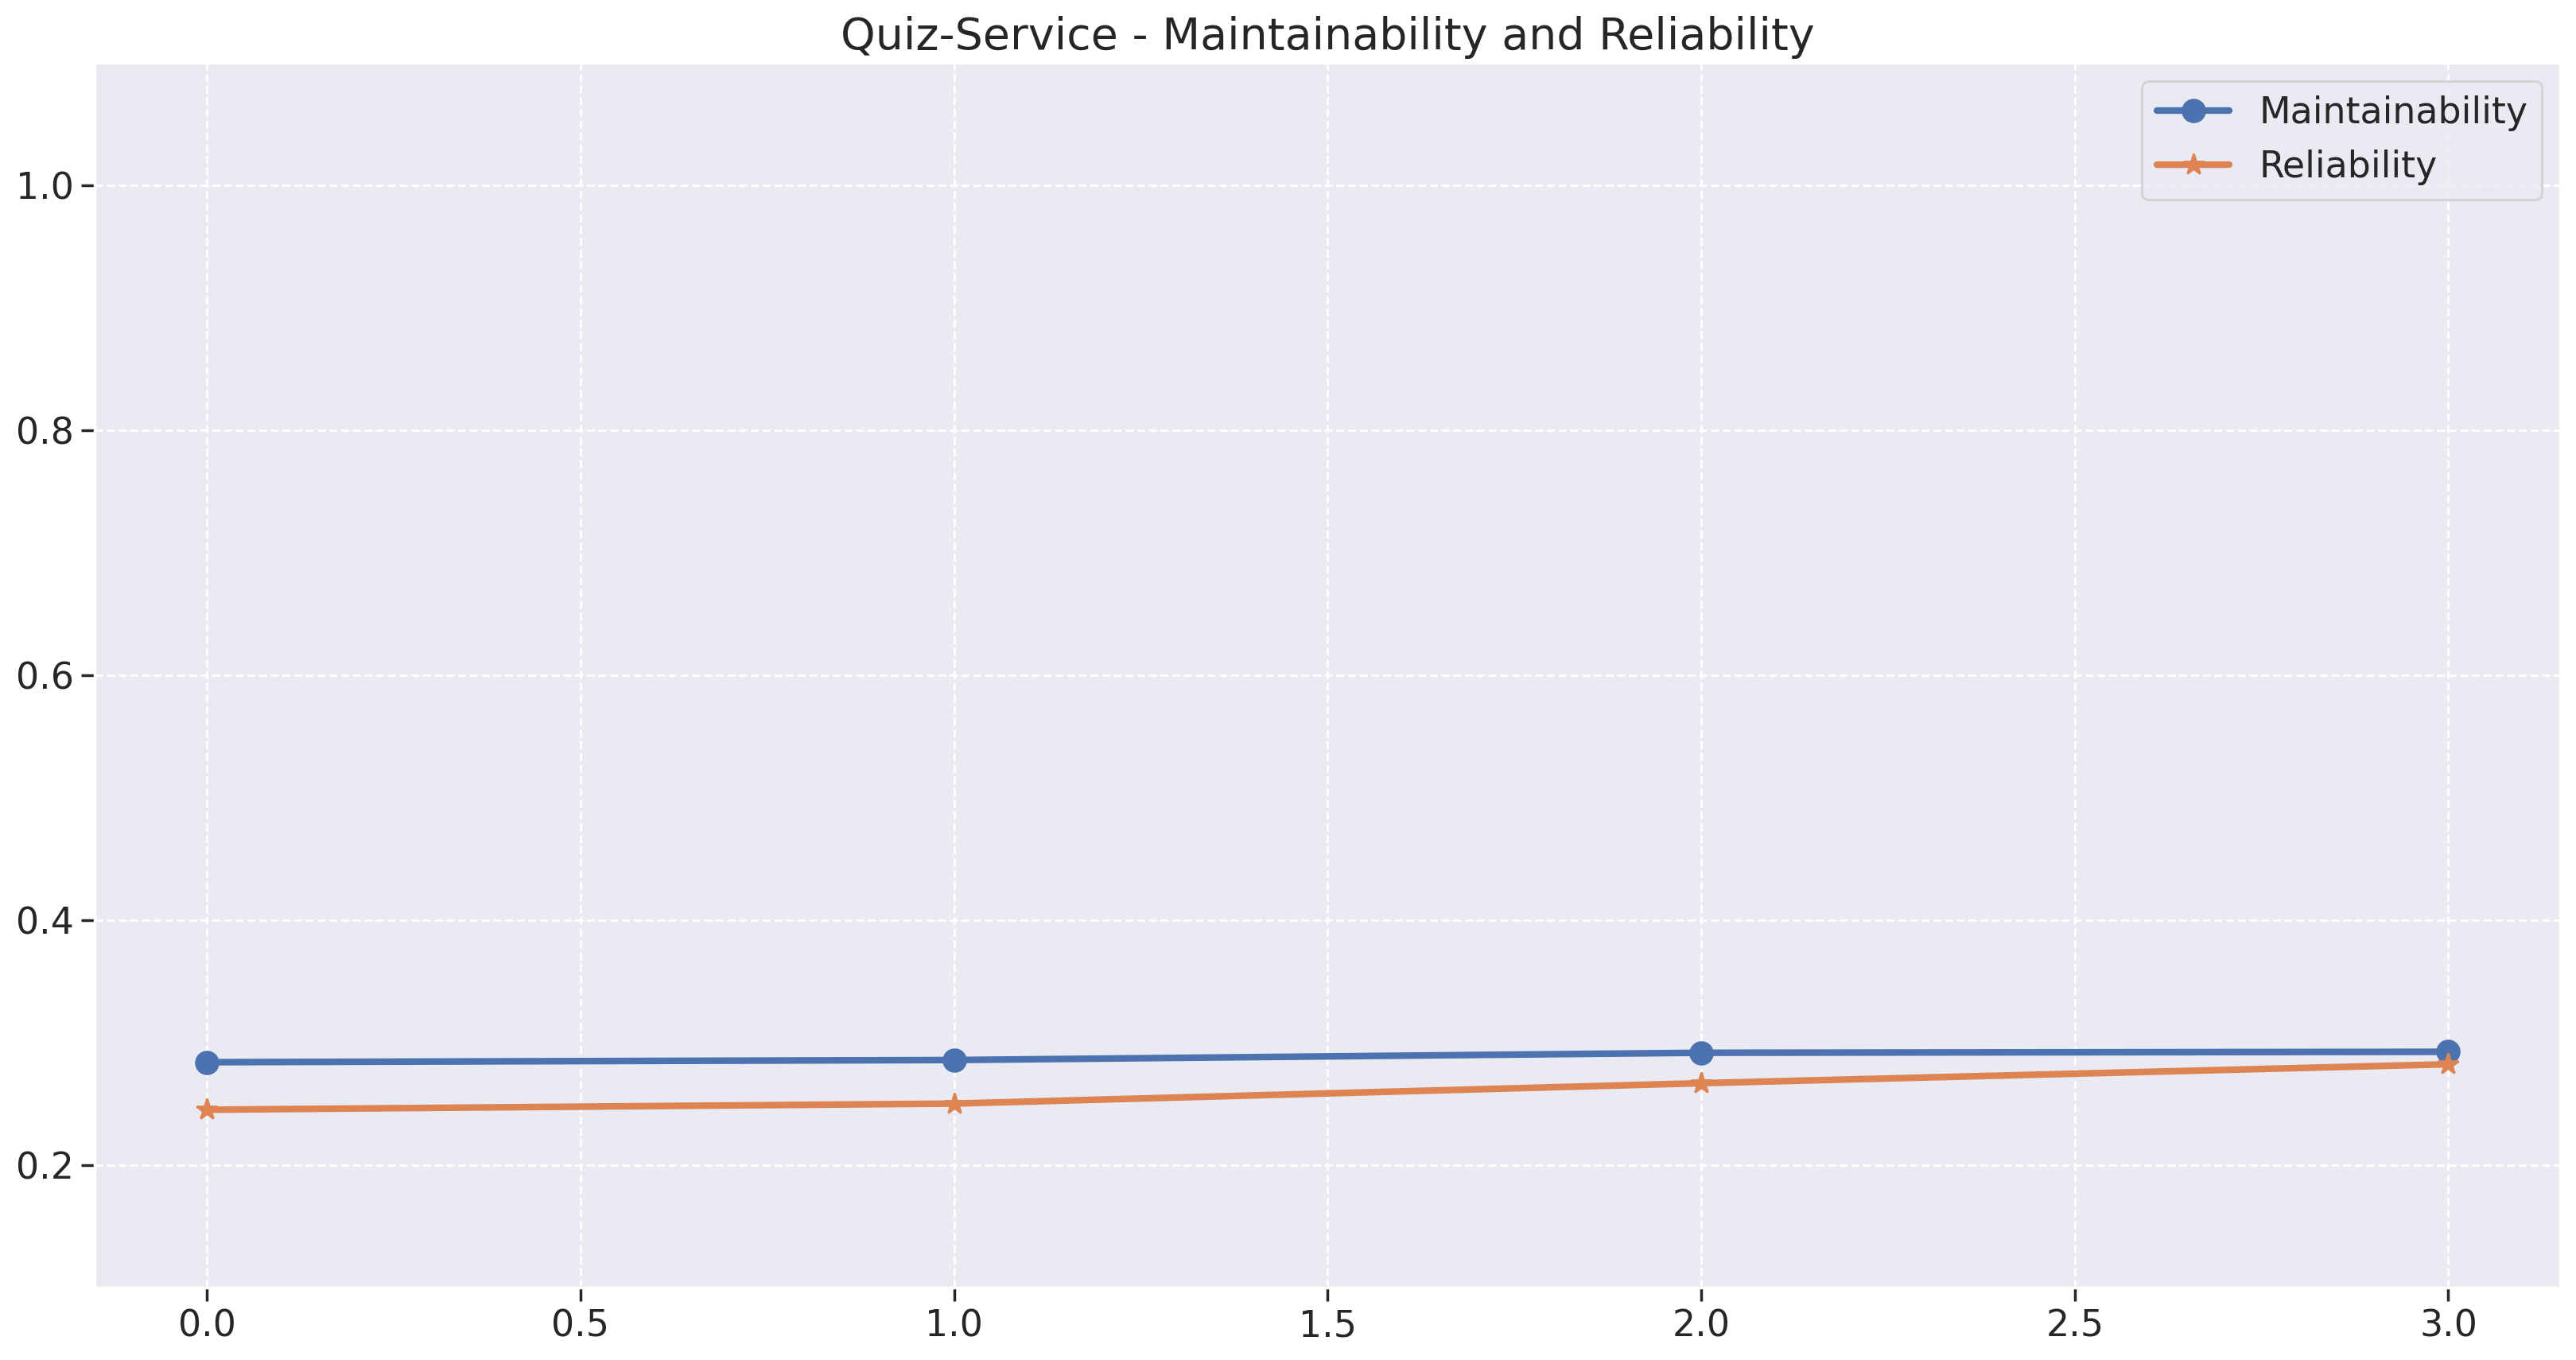

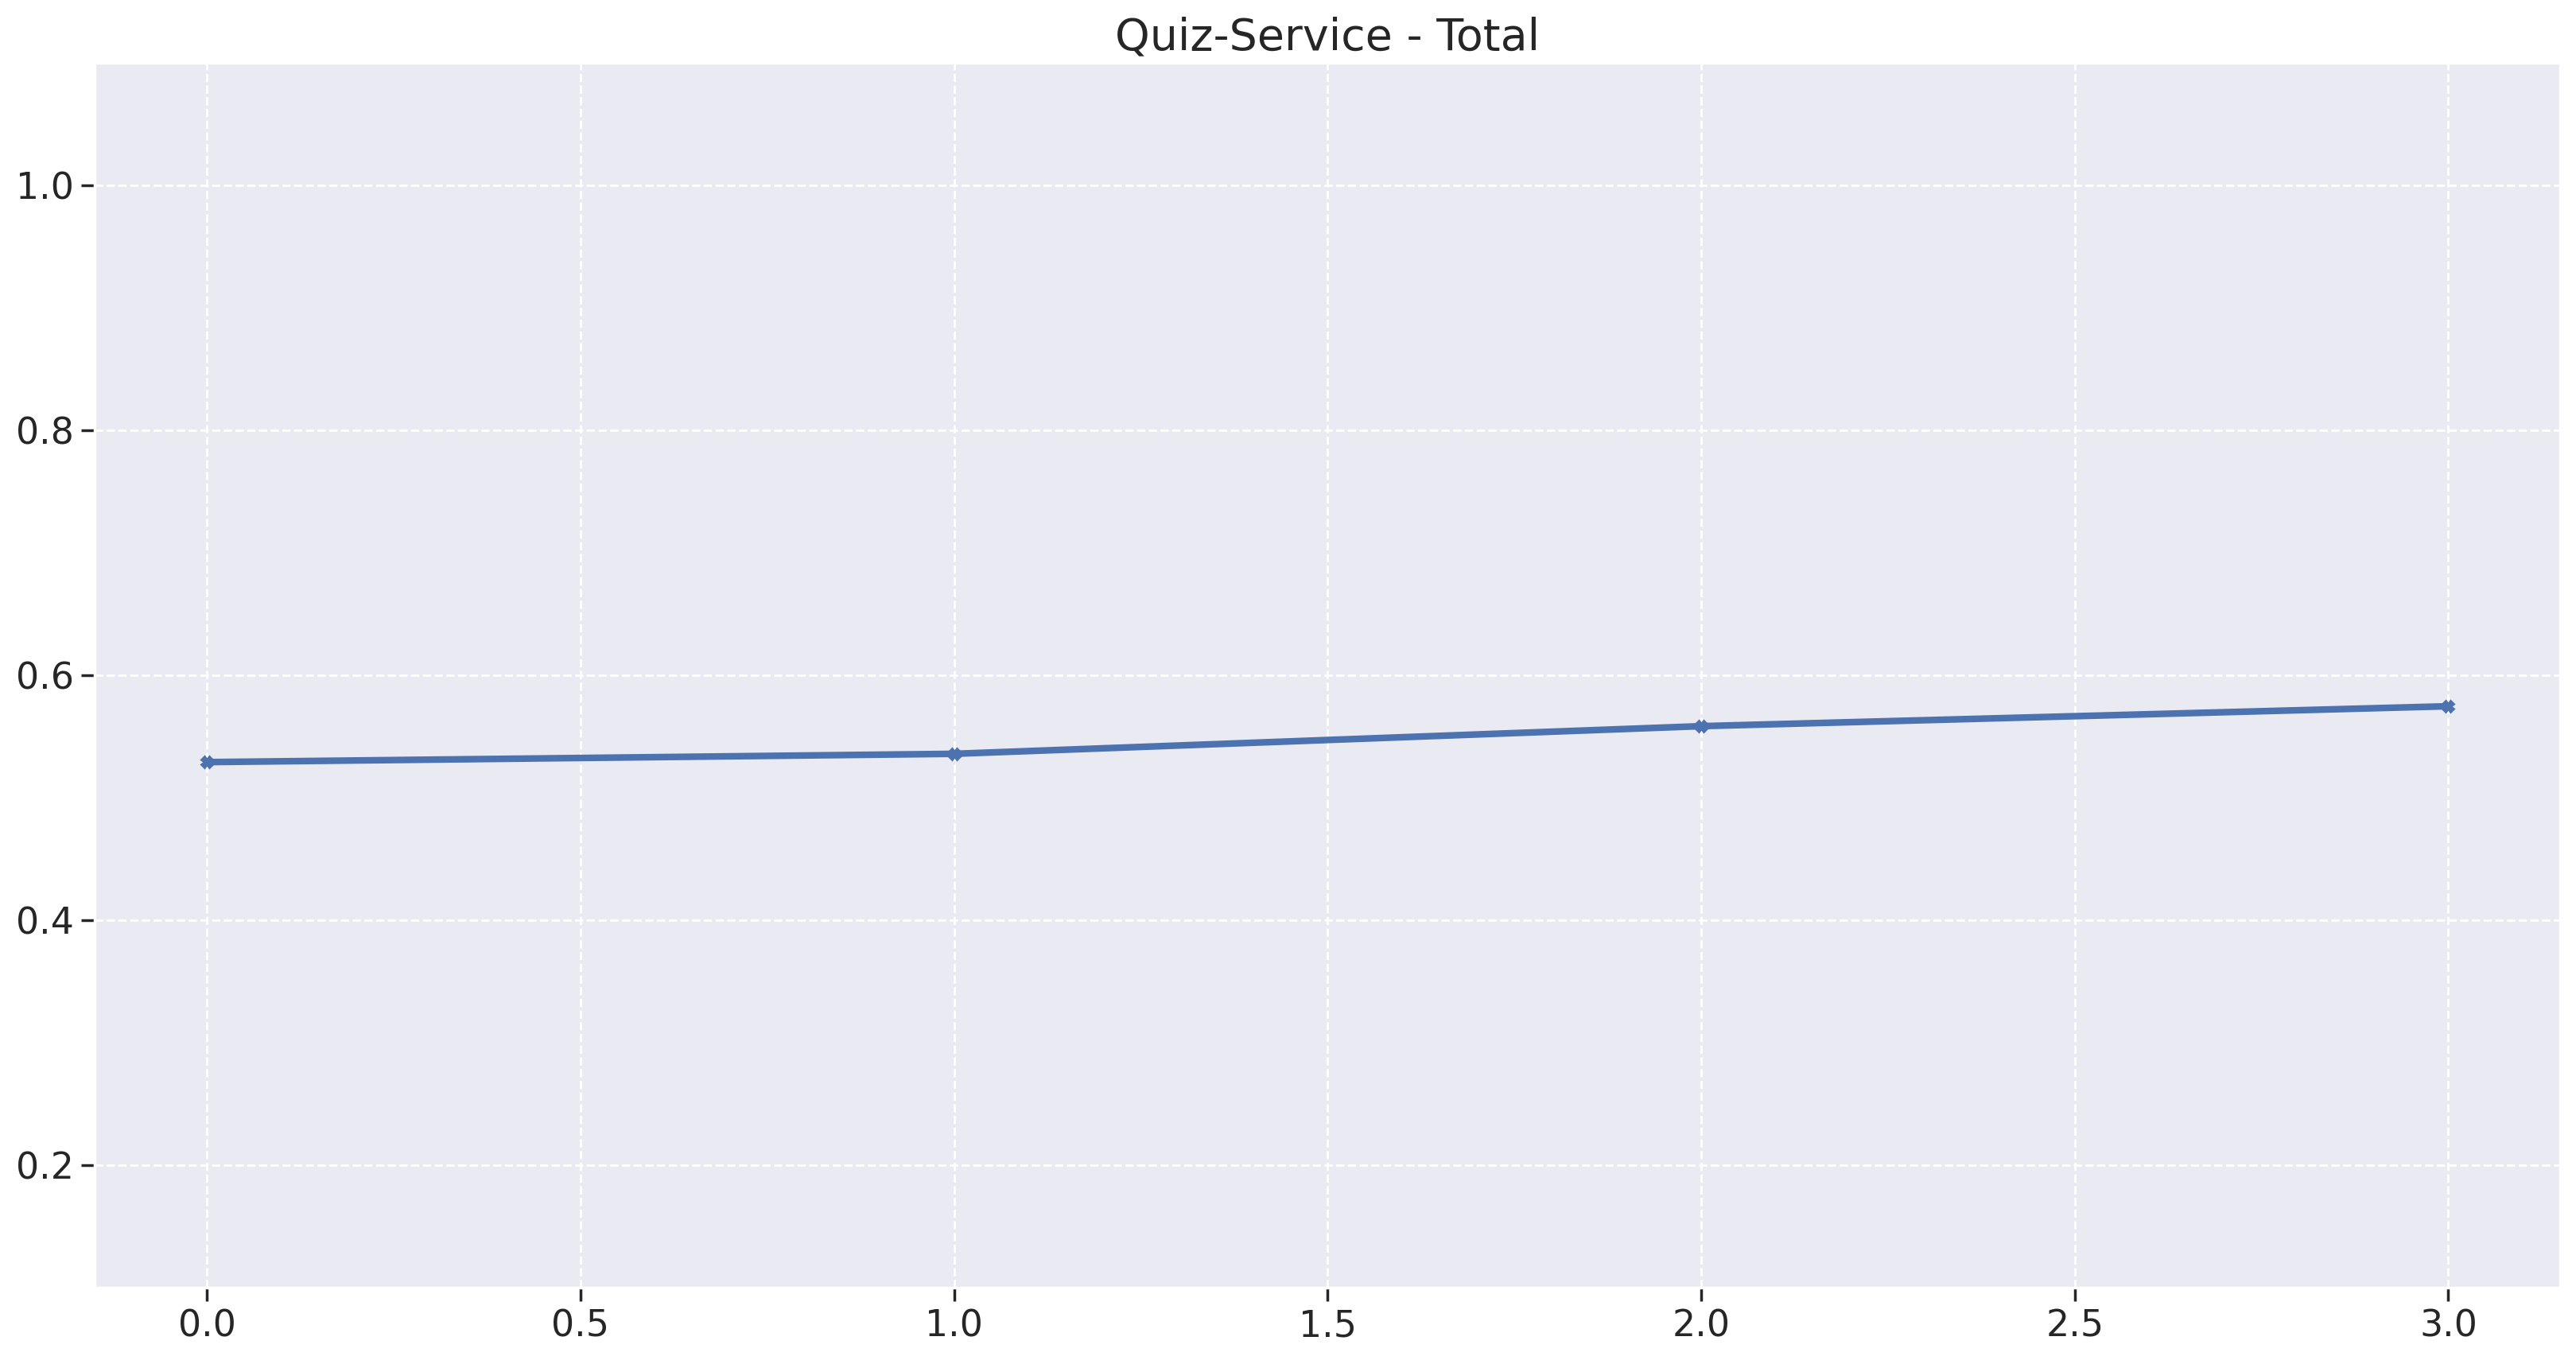

Web
Maintainability Stats
    mean     mode   median      std      var      min      max
0.307018 0.305426 0.307018 0.002253 0.000005 0.305426 0.308611
0.307018 0.308611 0.307018 0.002253 0.000005 0.305426 0.308611
Reliability Stats
 mean  mode  median  std  var   min   max
0.375 0.375   0.375  0.0  0.0 0.375 0.375


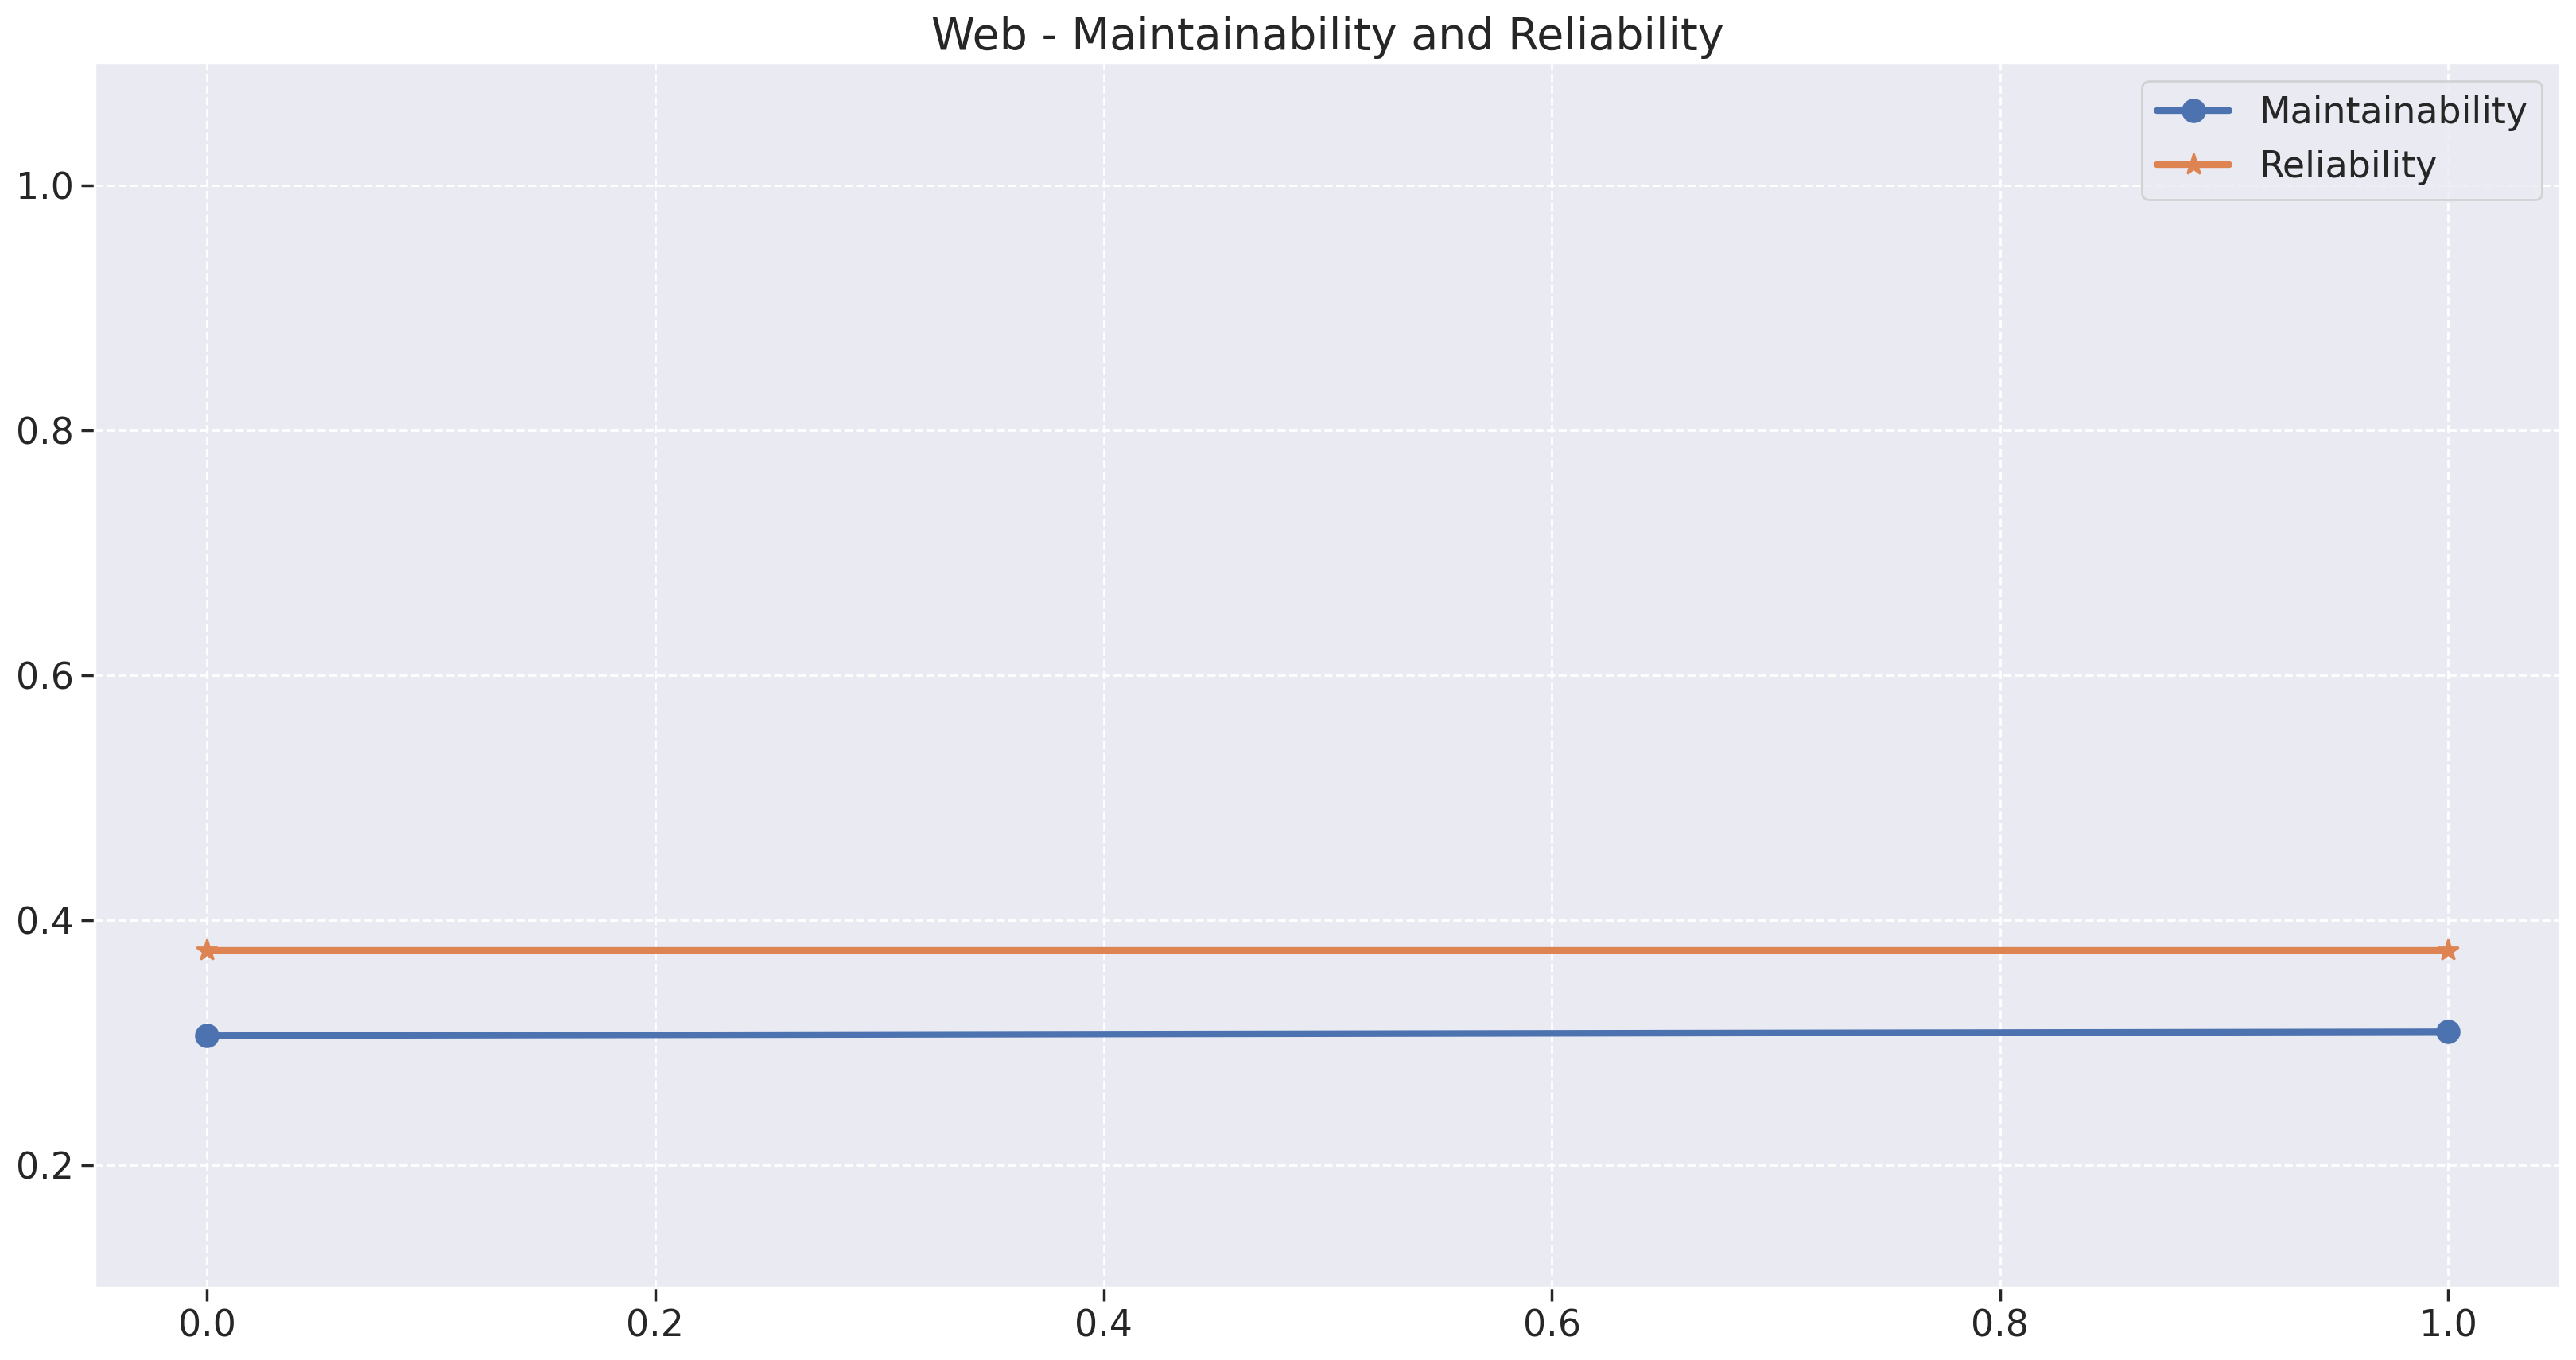

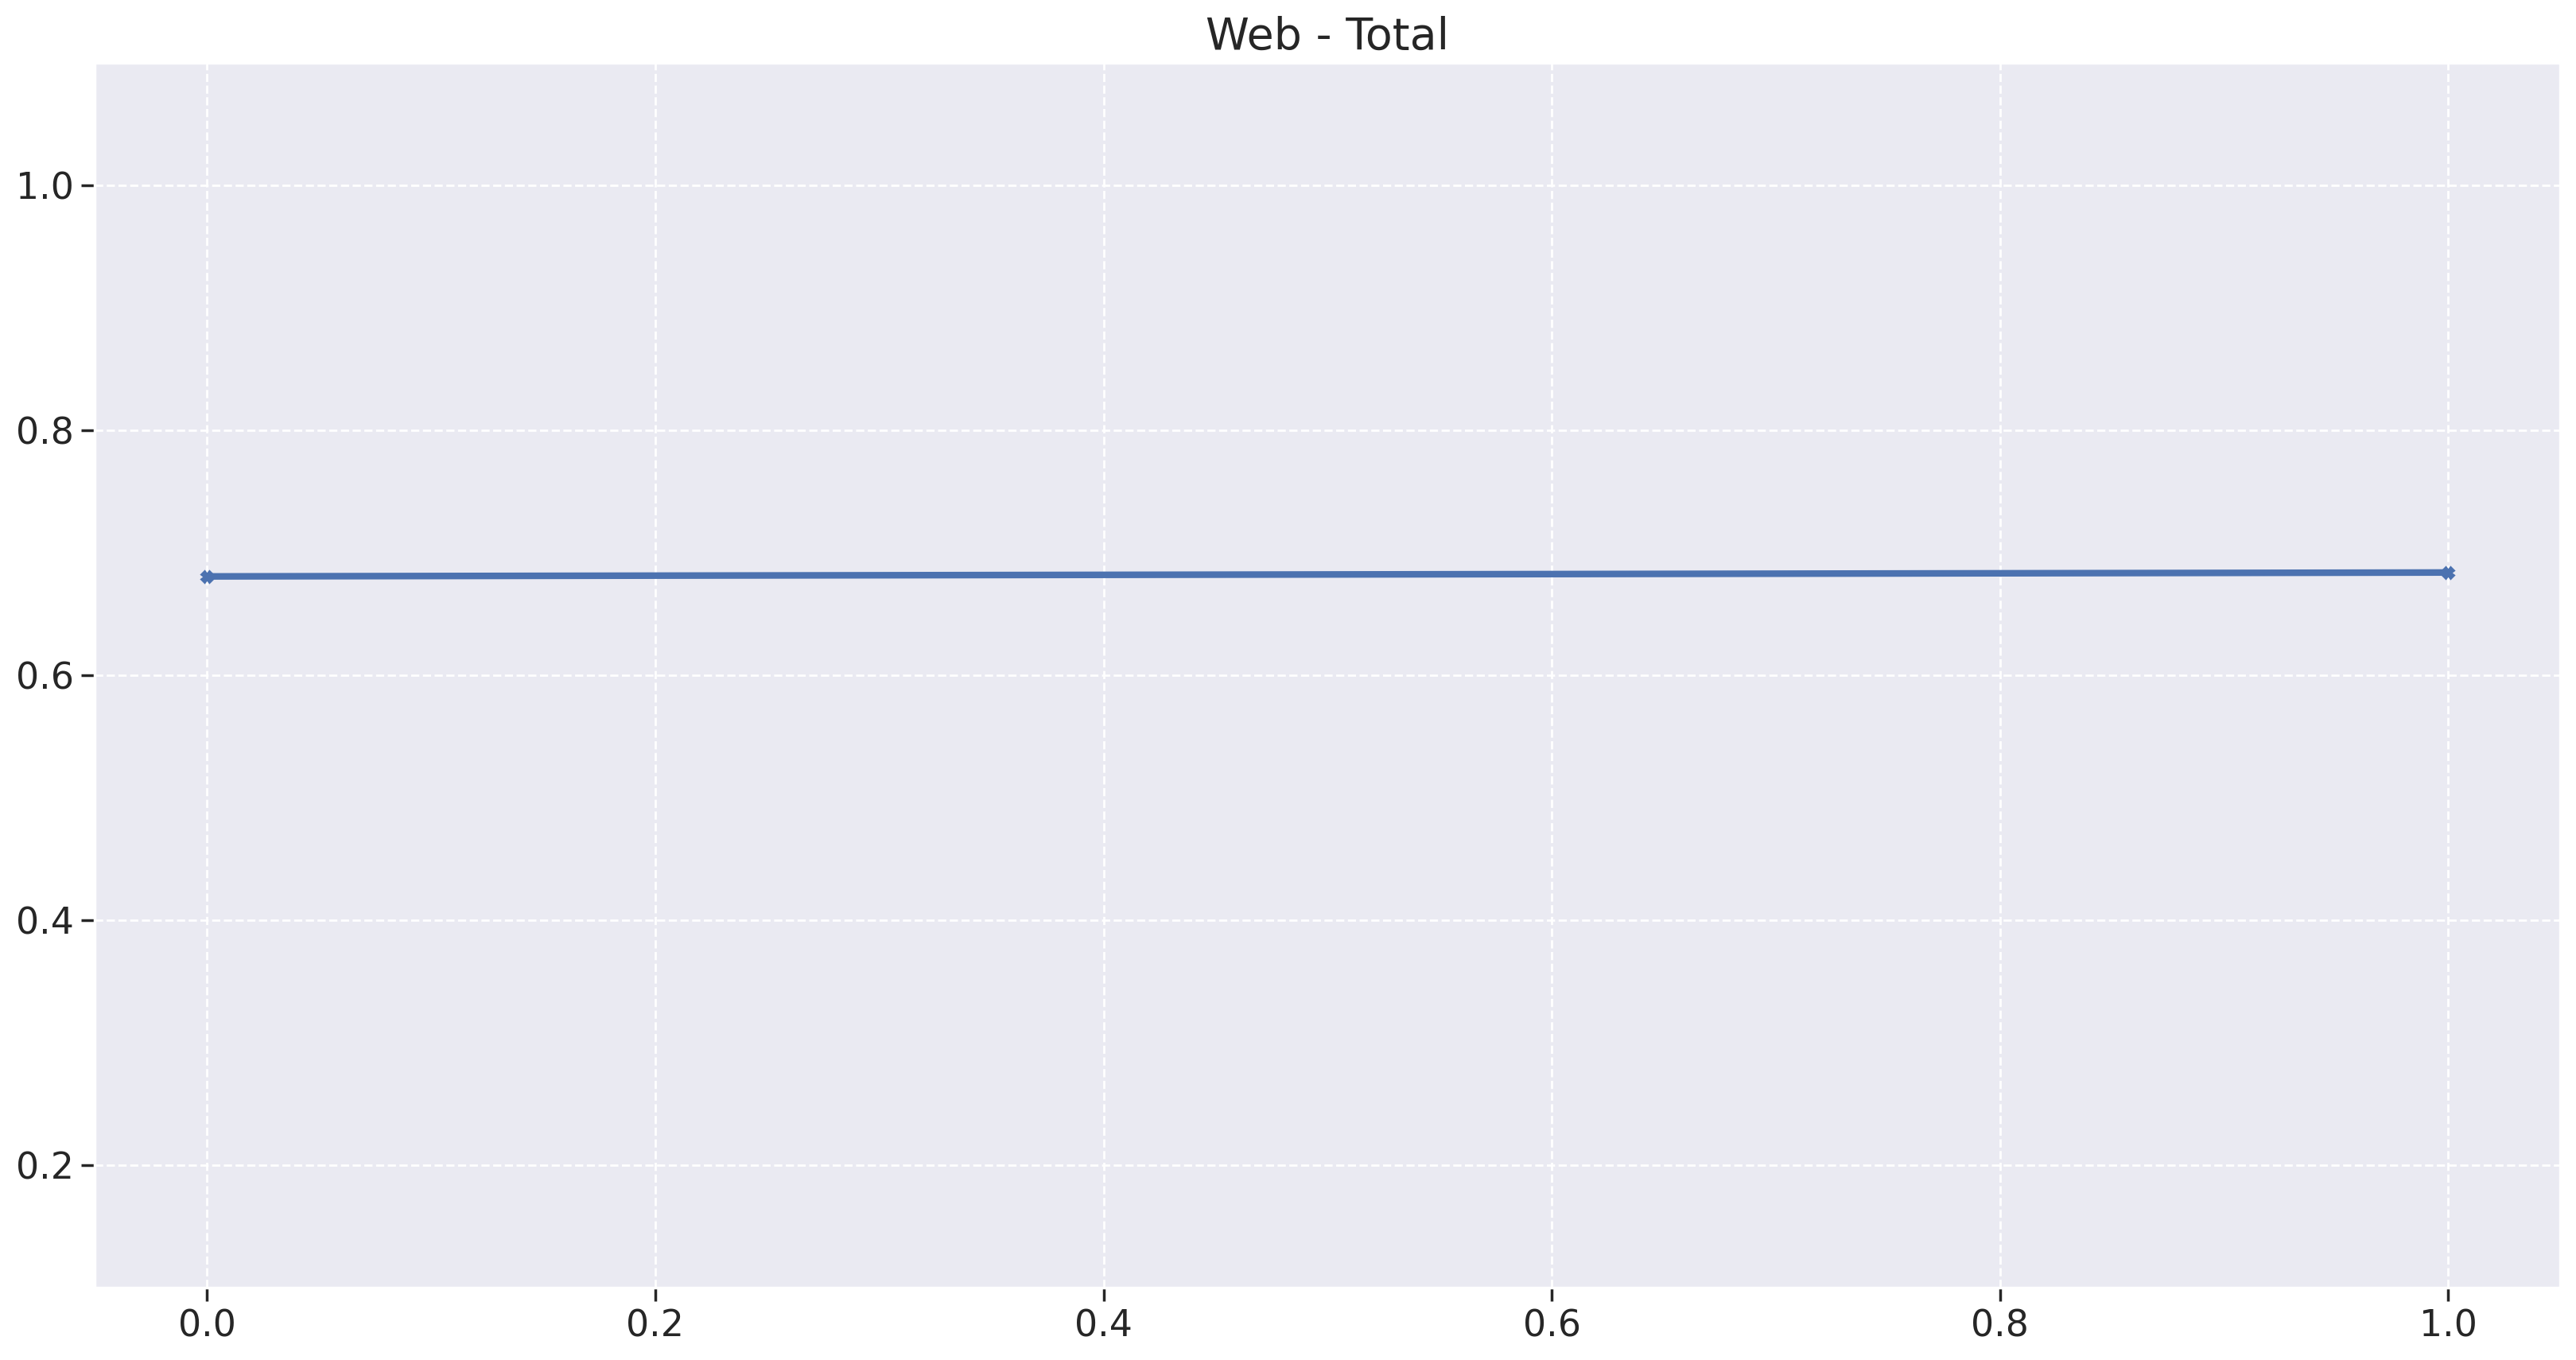

In [80]:
for name, data in metrics.items():
    print(name)
    analysis(data, name)


### Quality characteristic indicator


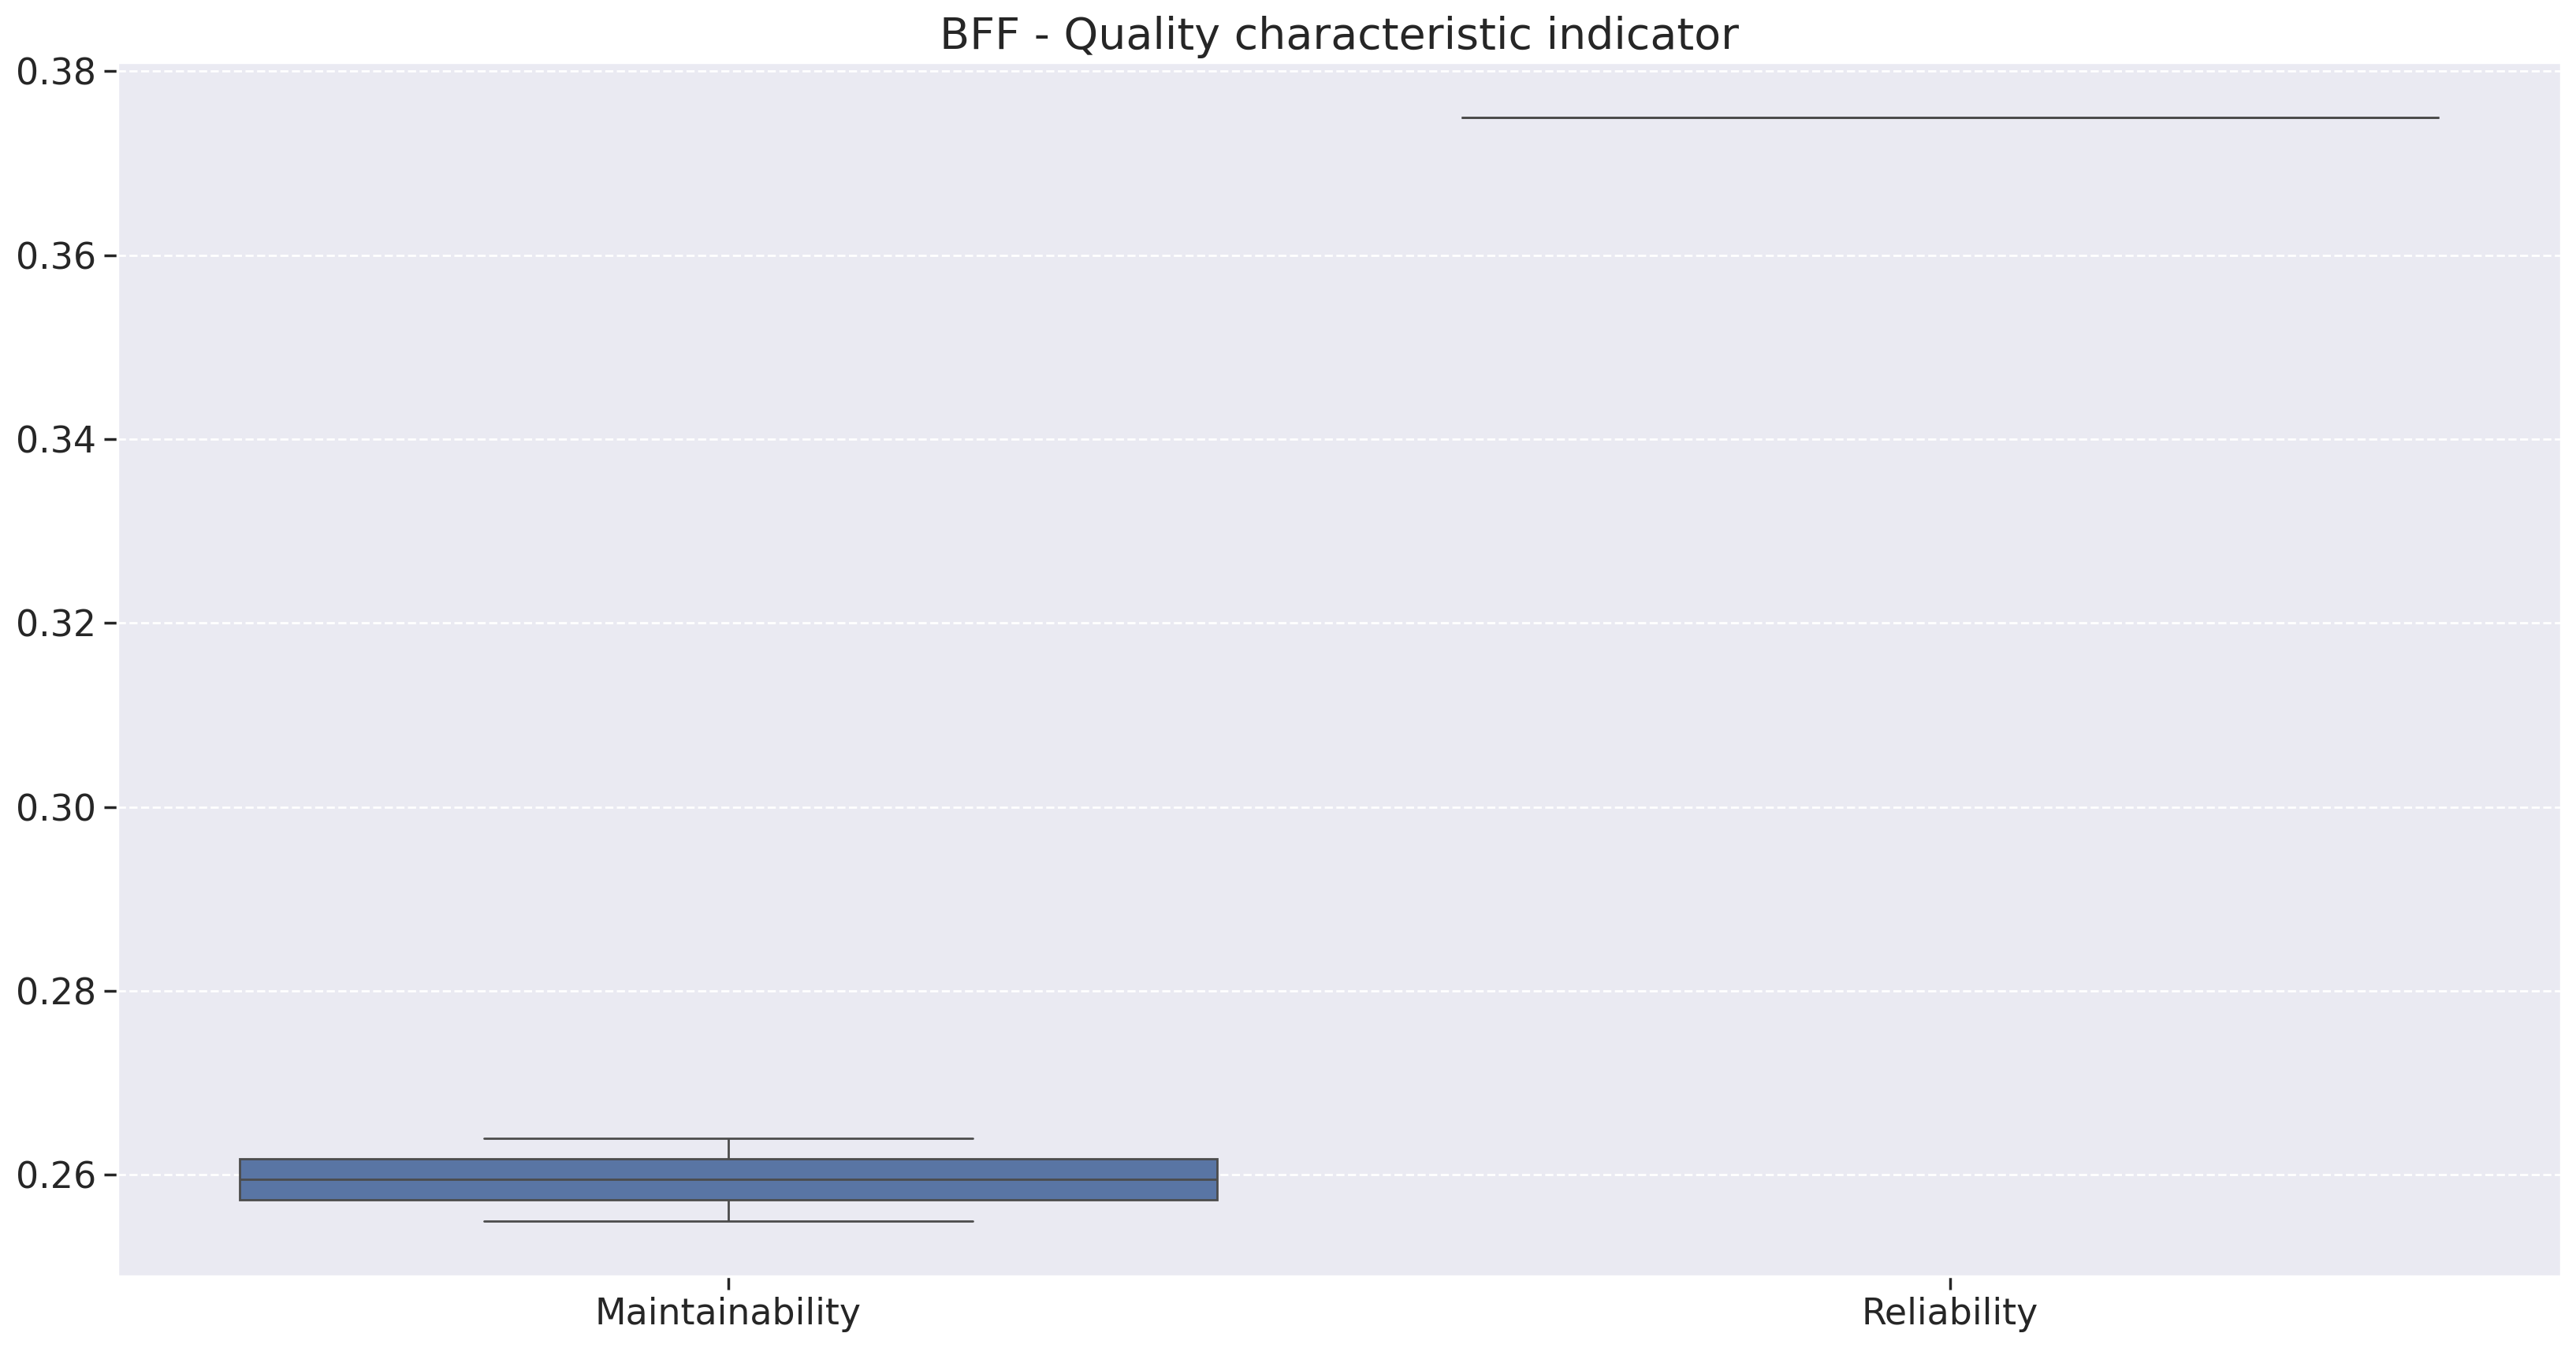

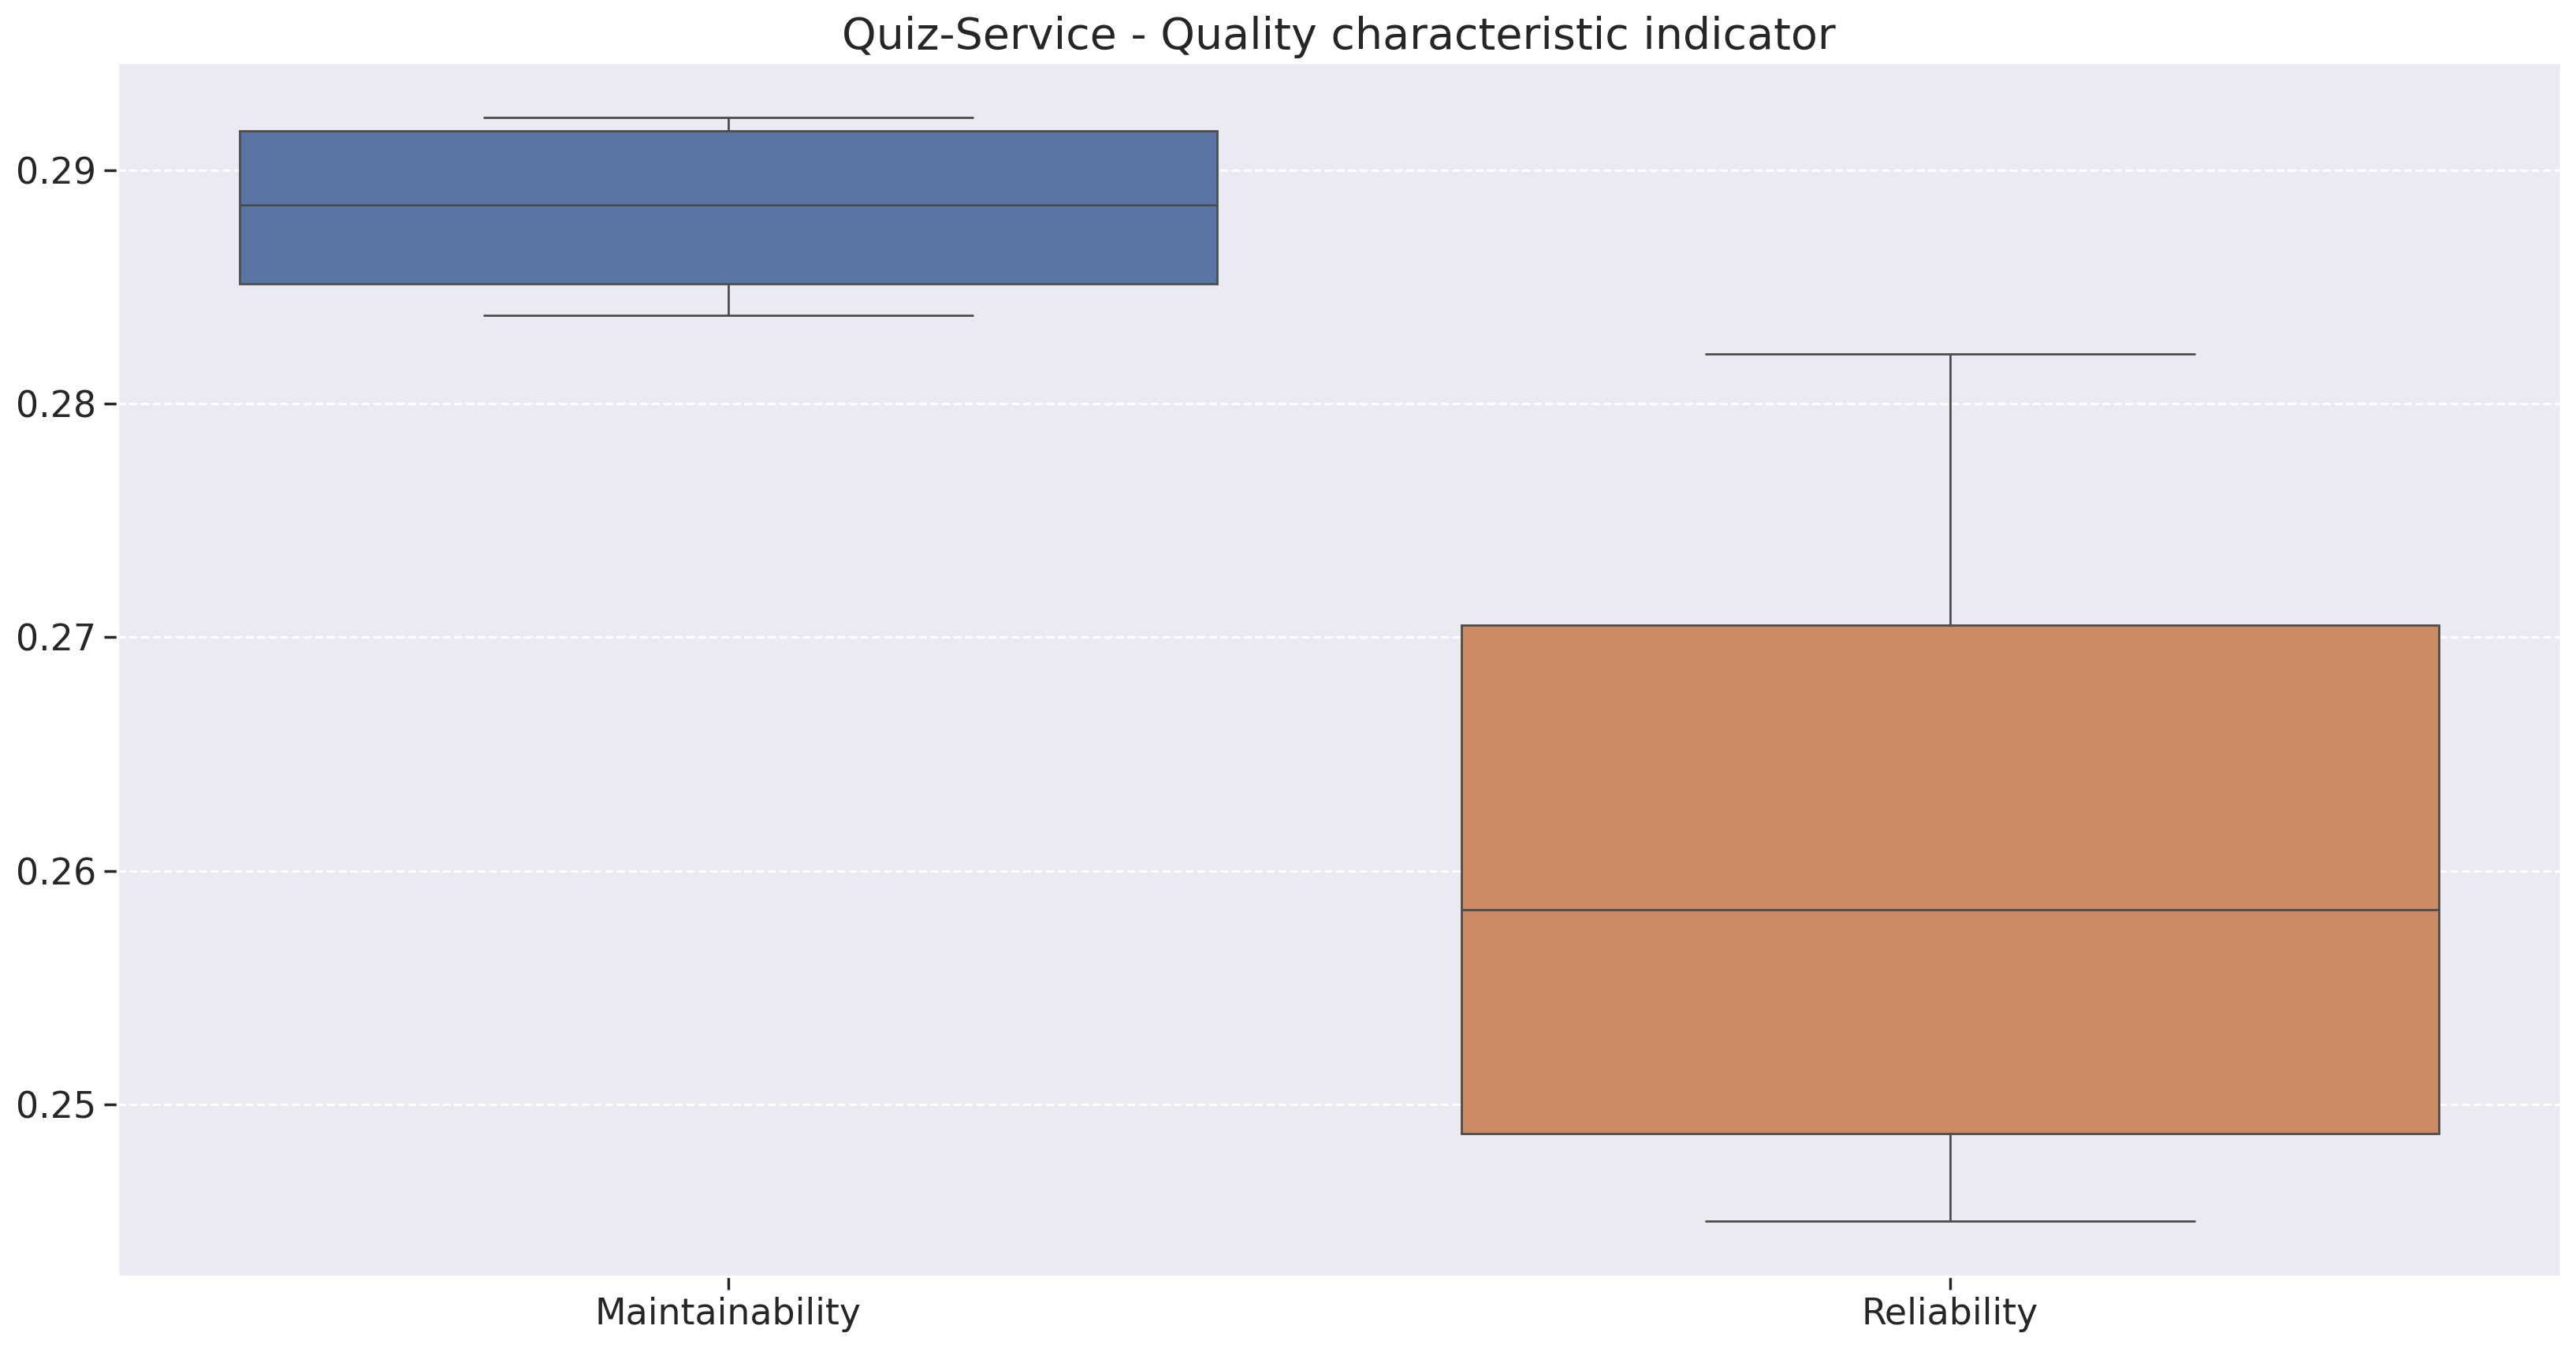

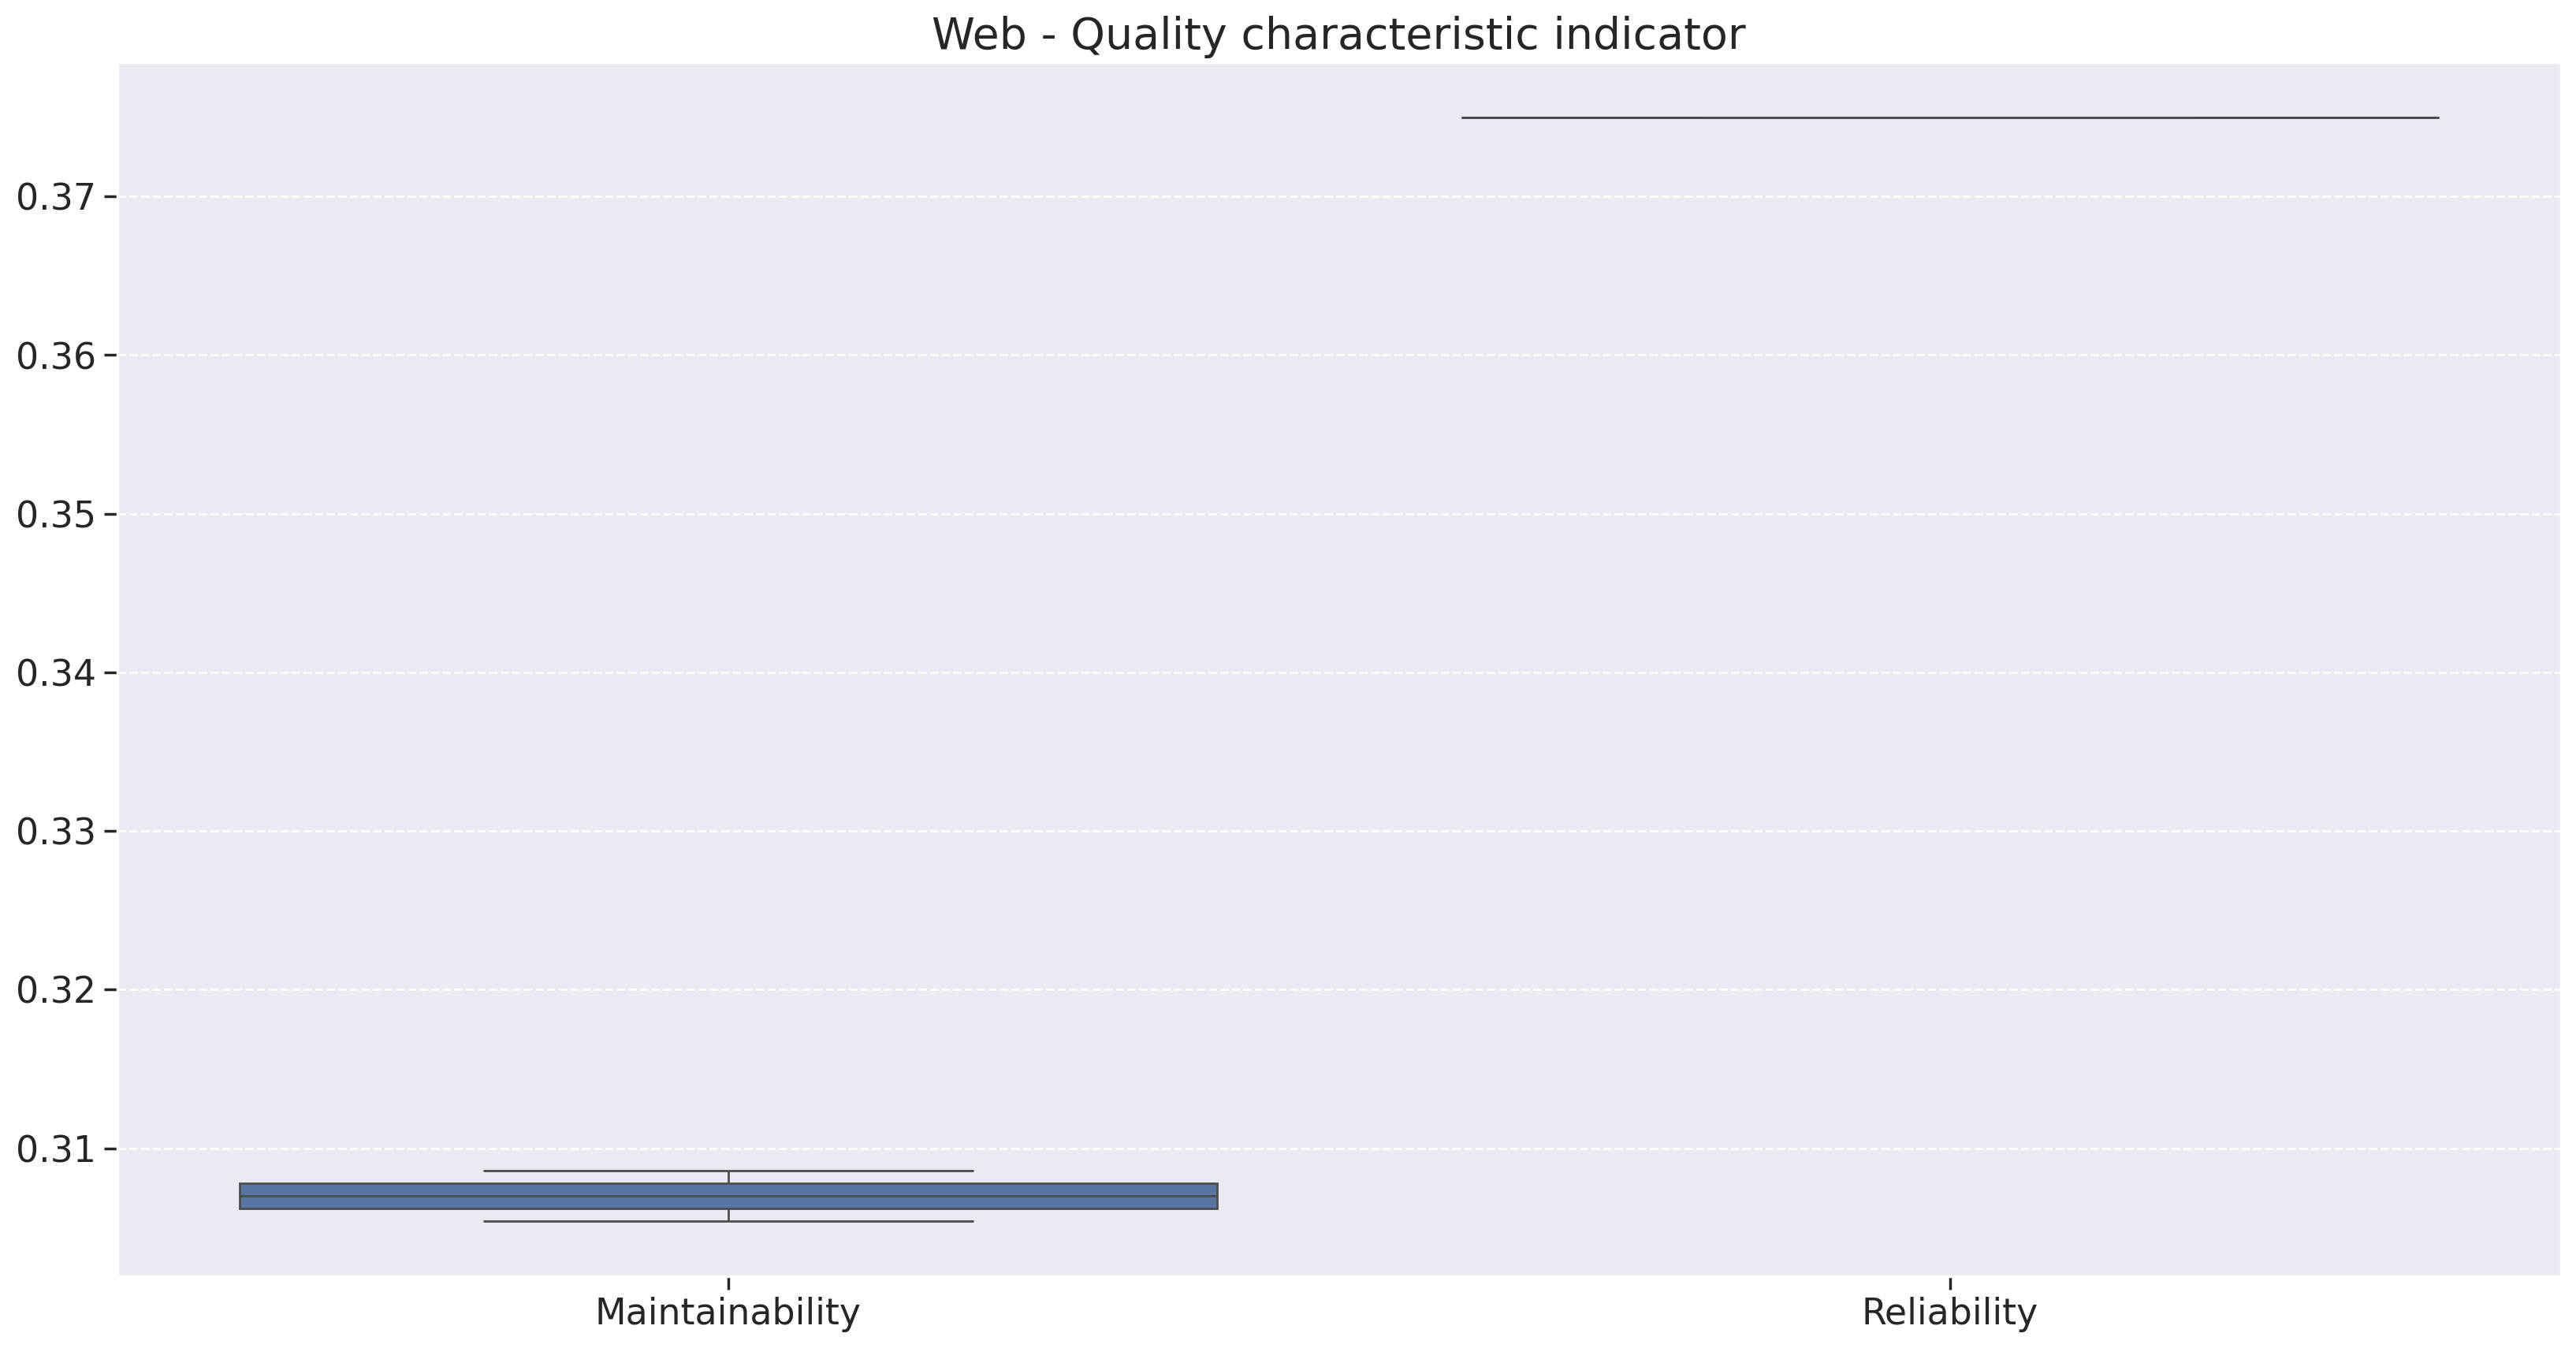

In [81]:
for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))
    sns.boxplot(data=data[['Maintainability','Reliability']])

    plt.title(f"{name} - Quality characteristic indicator", fontsize=20)
    plt.show()


### Quality indicator visualization


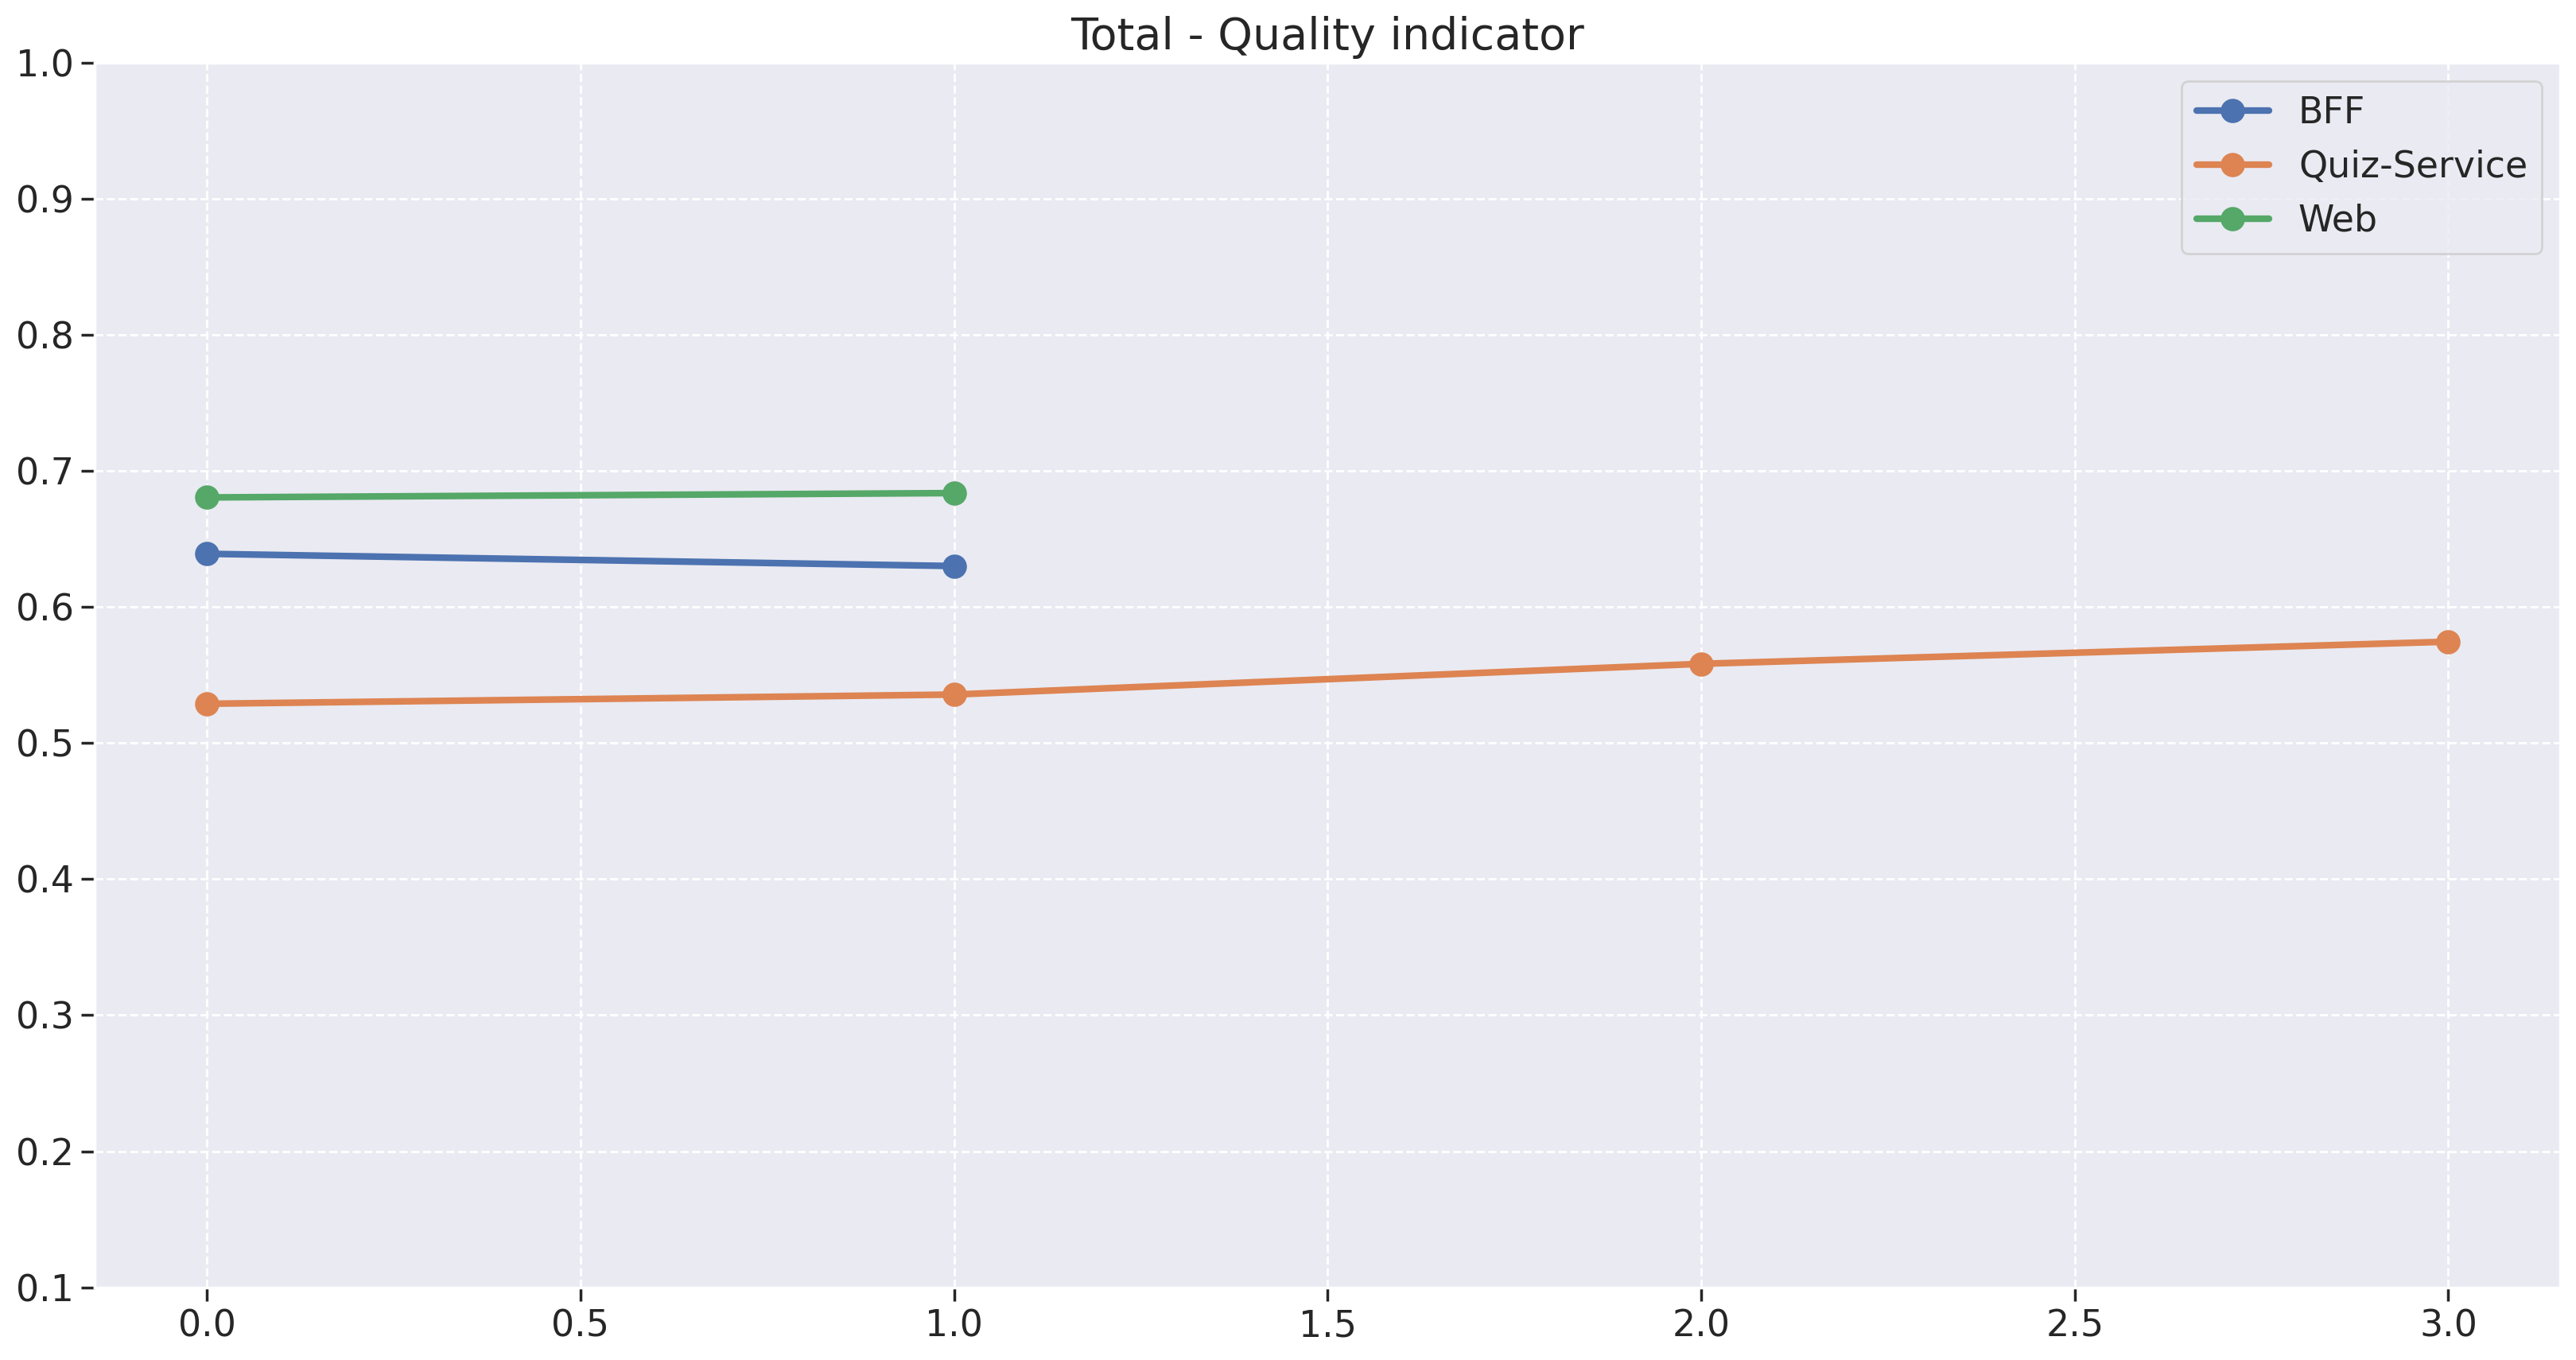

In [82]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['total'], linewidth=3, marker='o', markersize=10, label=name)

plt.ylim(.1,1)
plt.title("Total - Quality indicator", fontsize=20)
plt.legend(loc='best')
plt.show()


## Complementary GitHub metrics

Tratamento dos dados complementares disponíveis localmente em `analytics-raw-data`: GitHub Actions runs e GitHub Issues.


In [ ]:
from pathlib import Path
import re
from IPython.display import HTML, display

RAW_DATA_DIR = Path('./analytics-raw-data')


def safe_ratio(numerator, denominator):
    denominator = float(denominator or 0)
    if denominator == 0:
        return 0.0
    return float(numerator or 0) / denominator


def repository_from_dir(path: Path) -> str:
    return f"{repo_name}{path.parent.name}"


def version_from_runs_file(path: Path) -> str:
    repository = repository_from_dir(path)
    pattern = rf"^GitHub_API-Runs-{re.escape(repository)}-(?P<version>.+)\.json$"
    match = re.match(pattern, path.name)
    return match.group('version') if match else ''


def load_runs_metrics(raw_data_dir: Path = RAW_DATA_DIR) -> pd.DataFrame:
    rows = []

    for path in sorted(raw_data_dir.glob('**/GitHub_API-Runs-*.json')):
        with path.open(encoding='utf-8') as file:
            payload = json.load(file)

        runs = payload.get('workflow_runs', [])
        completed_runs = [run for run in runs if run.get('status') == 'completed']
        success_runs = [run for run in completed_runs if run.get('conclusion') == 'success']
        failed_runs = [run for run in completed_runs if run.get('conclusion') == 'failure']

        rows.append({
            'repository': repository_from_dir(path),
            'version': version_from_runs_file(path),
            'runs_total': len(runs),
            'runs_completed': len(completed_runs),
            'runs_success': len(success_runs),
            'runs_failed': len(failed_runs),
            'build_stability': safe_ratio(len(success_runs), len(completed_runs)),
        })

    return pd.DataFrame(rows)


def load_issues_metrics(raw_data_dir: Path = RAW_DATA_DIR) -> pd.DataFrame:
    rows = []

    for path in sorted(raw_data_dir.glob('**/GitHub_API-Issues-*.json')):
        with path.open(encoding='utf-8') as file:
            issues = json.load(file)

        if not isinstance(issues, list):
            continue

        open_issues = [issue for issue in issues if issue.get('state') == 'open']
        closed_issues = [issue for issue in issues if issue.get('state') == 'closed']
        described_issues = [issue for issue in issues if str(issue.get('body') or '').strip()]

        rows.append({
            'repository': repository_from_dir(path),
            'issues_total': len(issues),
            'issues_open': len(open_issues),
            'issues_closed': len(closed_issues),
            'task_completion': safe_ratio(len(closed_issues), len(issues)),
            'well_defined_issues': safe_ratio(len(described_issues), len(issues)),
        })

    return pd.DataFrame(rows)


runs_metrics_df = load_runs_metrics()
issues_metrics_df = load_issues_metrics()

display(runs_metrics_df)
display(issues_metrics_df)


## Export data


In [ ]:
os.makedirs('data', exist_ok=True)

metrics_list = metrics.values()
sonar_metrics_history_df = pd.concat(metrics_list, ignore_index=True)

product_metrics_history_df = sonar_metrics_history_df.merge(
    runs_metrics_df,
    on=['repository', 'version'],
    how='left',
)
product_metrics_history_df = product_metrics_history_df.merge(
    issues_metrics_df,
    on='repository',
    how='left',
)

numeric_complementary_columns = [
    'runs_total', 'runs_completed', 'runs_success', 'runs_failed', 'build_stability',
    'issues_total', 'issues_open', 'issues_closed', 'task_completion', 'well_defined_issues',
]
for column in numeric_complementary_columns:
    if column in product_metrics_history_df.columns:
        product_metrics_history_df[column] = product_metrics_history_df[column].fillna(0)

product_metrics_history_df['version_datetime'] = pd.to_datetime(
    product_metrics_history_df['version'],
    format='%m-%d-%Y-%H-%M-%S',
    errors='coerce',
)

metrics_df = (
    product_metrics_history_df
    .sort_values(['repository', 'version_datetime'])
    .groupby('repository', as_index=False)
    .tail(1)
    .drop(columns=['version_datetime'])
    .reset_index(drop=True)
)

configured_repositories = [repo_name + repository for repository in repos_language.keys()]
missing_repositories = [
    repository for repository in configured_repositories
    if repository not in set(metrics_df['repository'])
]

if missing_repositories:
    placeholder_rows = pd.DataFrame({
        'repository': missing_repositories,
        'version': 'N/A',
    })
    metrics_df = pd.concat([metrics_df, placeholder_rows], ignore_index=True)

export_columns = [
    'repository', 'version', 'ncloc',
    'complexity', 'comments', 'duplication', 'test_success', 'fast_tests', 'coverage',
    'code_quality', 'testing_status', 'Maintainability', 'Reliability', 'total',
    'build_stability', 'task_completion', 'well_defined_issues',
    'issues_total', 'issues_open', 'issues_closed',
    'runs_total', 'runs_completed', 'runs_success', 'runs_failed',
]
metrics_df = metrics_df[[column for column in export_columns if column in metrics_df.columns]]

for column in metrics_df.columns:
    if column not in ['repository', 'version']:
        metrics_df[column] = pd.to_numeric(metrics_df[column], errors='coerce')

metrics_df = metrics_df.sort_values('repository').reset_index(drop=True)

display(metrics_df)

current_datetime = datetime.datetime.now().strftime('%m-%d-%Y--%H-%M-%S')
export_basename = f'./data/anatoquizup-product-quality-dashboard-{current_datetime}'

csv_path = f'{export_basename}.csv'
xlsx_path = f'{export_basename}.xlsx'

metrics_df.to_csv(csv_path, index=False)

try:
    metrics_df.to_excel(xlsx_path, index=False)
    print(f'Exported consolidated dashboard data to {xlsx_path} and {csv_path}')
except ModuleNotFoundError as error:
    print(f'Exported consolidated dashboard data to {csv_path}')
    print(f'XLSX export skipped because the Excel engine is unavailable: {error.name}')


## Dashboard Eixo Produto - Q-Rapids

Dashboard gerado a partir do dataframe consolidado exportado acima.


In [59]:
def metric_status(value):
    if pd.isna(value):
        return ('na', '#949494')
    if value >= 0.75:
        return ('green', '#1D9E75')
    if value >= 0.50:
        return ('yellow', '#EF9F27')
    return ('red', '#E24B4A')


def fmt_metric(value):
    if pd.isna(value):
        return 'N/A'
    return f'{value:.2f}'


def metric_bar(label, value, source):
    status, color = metric_status(value)
    width = 0 if pd.isna(value) else max(0, min(100, value * 100))
    return f'''
      <div class="metric-item">
        <span class="m-dot dot-{status}" style="background:{color}"></span>
        <span class="m-name">{label}</span>
        <div class="m-bar-wrap"><div class="m-bar" style="width:{width:.0f}%;background:{color}"></div></div>
        <span class="m-val" style="color:{color}">{fmt_metric(value)}</span>
        <span class="m-src">{source}</span>
      </div>
    '''


def score_card(title, subtitle, value):
    _, color = metric_status(value)
    width = max(0, min(100, value * 100))
    return f'''
      <div class="kpq">
        <div class="klq">Indicador estratégico</div>
        <div class="kvq">{title}</div>
        <div class="knum" style="color:{color}">{fmt_metric(value)}</div>
        <div class="score-track"><div style="width:{width:.0f}%;background:{color}"></div></div>
        <div class="ksub">{subtitle}</div>
      </div>
    '''


def repository_coverage_rows(dataframe):
    rows = []
    for _, row in dataframe.sort_values('repository').iterrows():
        repo_label = row['repository'].replace(repo_name, '')
        coverage_value = row.get('coverage', float('nan'))
        coverage_value = float(coverage_value) if not pd.isna(coverage_value) else float('nan')
        _, color = metric_status(coverage_value)
        width = 0 if pd.isna(coverage_value) else coverage_value * 100
        label = 'N/A' if pd.isna(coverage_value) else f'{coverage_value * 100:.0f}%'
        rows.append(f'''
          <div class="repo-row">
            <span>{repo_label}</span>
            <div class="repo-track"><div style="width:{width:.0f}%;background:{color}"></div></div>
            <strong style="color:{color}">{label}</strong>
          </div>
        ''')
    return ''.join(rows)


available_metrics_df = metrics_df.dropna(
    subset=['complexity', 'comments', 'duplication', 'coverage'],
    how='all',
)

product_quality = available_metrics_df[['complexity', 'comments', 'duplication', 'coverage']].mean(axis=1).mean()
blocking = available_metrics_df['well_defined_issues'].mean()
product_readiness = available_metrics_df['build_stability'].mean()
repo_count = len(repos_language)

metric_means = available_metrics_df[[
    'complexity', 'comments', 'duplication', 'coverage',
    'build_stability', 'well_defined_issues',
]].mean(numeric_only=True)

html = f'''
<style>
.qrapids-dashboard{{
  --q-bg-card:#FFFFFF;
  --q-bg-muted:#F6F7FB;
  --q-bg-track:#ECEEF3;
  --q-border:#DDE1EA;
  --q-border-soft:#ECEFF5;
  --q-text-primary:#1F2430;
  --q-text-secondary:#596170;
  --q-text-tertiary:#7B8494;
  --q-accent-bg:#EEEDFE;
  --q-accent-text:#3C3489;
  color:var(--q-text-primary);
}}
@media (prefers-color-scheme: dark){{
  .qrapids-dashboard{{
    --q-bg-card:#171B25;
    --q-bg-muted:#202635;
    --q-bg-track:#2C3342;
    --q-border:#30384A;
    --q-border-soft:#262D3C;
    --q-text-primary:#F2F4F8;
    --q-text-secondary:#B8C0CF;
    --q-text-tertiary:#8E98AA;
    --q-accent-bg:#2B2858;
    --q-accent-text:#D9D5FF;
  }}
}}
.qh{{display:flex;align-items:center;gap:10px;margin-bottom:1.25rem;padding-top:1rem}}
.qa{{width:8px;height:36px;background:#6D63E6;border-radius:3px;flex-shrink:0}}
.qt{{font-size:16px;font-weight:600;color:var(--q-text-primary);margin:0}}
.qs{{font-size:12px;color:var(--q-text-secondary);margin:0;display:flex;align-items:center;gap:8px;flex-wrap:wrap}}
.qb{{margin-left:auto;font-size:11px;background:var(--q-accent-bg);color:var(--q-accent-text);padding:3px 10px;border-radius:6px;white-space:nowrap}}
.kgq{{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:10px;margin-bottom:1.25rem}}
.kpq{{background:var(--q-bg-card);border:1px solid var(--q-border);border-radius:8px;padding:12px 14px;box-shadow:0 1px 2px rgba(15,23,42,.06)}}
.klq{{font-size:11px;color:var(--q-text-secondary);margin-bottom:2px}}
.kvq{{font-size:12px;color:var(--q-text-primary);margin-bottom:6px;font-weight:600}}
.knum{{font-size:22px;font-weight:600}}
.ksub{{font-size:10px;color:var(--q-text-tertiary);margin-top:6px}}
.score-track{{height:4px;background:var(--q-bg-track);border-radius:2px;margin-top:6px;overflow:hidden}}
.score-track div{{height:100%;border-radius:2px}}
.qcard{{background:var(--q-bg-card);border:1px solid var(--q-border);border-radius:10px;padding:1rem 1.25rem;margin-bottom:1rem;box-shadow:0 1px 2px rgba(15,23,42,.06)}}
.qct{{font-size:13px;font-weight:600;color:var(--q-text-primary);margin:0 0 12px}}
.si-row{{display:flex;align-items:stretch;gap:12px;margin-bottom:1rem}}
.si-label{{writing-mode:vertical-rl;text-orientation:mixed;transform:rotate(180deg);font-size:11px;font-weight:600;color:var(--q-text-secondary);display:flex;align-items:center;justify-content:center;padding:4px 0;min-width:22px;border-right:2px solid var(--q-border)}}
.si-body{{flex:1;display:flex;flex-direction:column;gap:6px}}
.factor-row{{display:grid;grid-template-columns:180px minmax(0,1fr);gap:16px;align-items:center}}
.factor-label{{font-size:11px;color:var(--q-text-secondary);padding-top:4px;line-height:1.4}}
.factor-label span{{font-size:10px;color:var(--q-text-tertiary)}}
.metrics-group{{display:flex;flex-direction:column;gap:4px}}
.metric-item{{display:grid;grid-template-columns:10px minmax(360px,1fr) 90px 44px 70px;align-items:center;gap:8px}}
.m-dot{{width:10px;height:10px;border-radius:50%;flex-shrink:0}}
.m-name{{font-size:11px;color:var(--q-text-primary);line-height:1.35;min-width:0}}
.m-val{{font-size:11px;font-weight:600;min-width:36px;text-align:right}}
.m-bar-wrap{{width:90px;height:6px;background:var(--q-bg-track);border-radius:3px;overflow:hidden}}
.m-bar{{height:100%;border-radius:3px}}
.m-src{{font-size:10px;color:var(--q-text-tertiary);min-width:70px;text-align:right}}
.divider{{height:1px;background:var(--q-border-soft);margin:6px 0}}
.legend-inline{{display:inline-flex;align-items:center;gap:8px;color:var(--q-text-secondary)}}
.legend-inline span{{display:inline-flex;align-items:center;gap:4px;white-space:nowrap}}
.legend-inline b{{width:10px;height:10px;border-radius:50%;display:inline-block}}
.legend-row{{display:flex;gap:14px;font-size:11px;color:var(--q-text-secondary);margin-bottom:10px;align-items:center;flex-wrap:wrap}}
.legend-row span{{display:flex;align-items:center;gap:5px}}
.legend-row b{{width:10px;height:10px;border-radius:50%;display:inline-block}}
.source-inline{{color:var(--q-text-tertiary);white-space:nowrap}}
.repo-row{{display:grid;grid-template-columns:120px 1fr 48px;gap:10px;align-items:center;font-size:11px;margin:8px 0;color:var(--q-text-secondary)}}
.repo-track{{height:8px;background:var(--q-bg-track);border-radius:4px;overflow:hidden}}
.repo-track div{{height:100%;border-radius:4px}}
.formula-box{{background:var(--q-bg-muted);border:1px solid var(--q-border-soft);border-radius:8px;padding:10px 12px;font-size:11px;color:var(--q-text-secondary);line-height:1.6}}
.formula-box strong{{color:var(--q-text-primary);font-weight:600}}
.formula-box em{{color:var(--q-text-tertiary)}}
@media (max-width: 900px){{.kgq{{grid-template-columns:1fr}}.qh{{align-items:flex-start}}.qb{{margin-left:0}}.factor-row{{grid-template-columns:1fr;align-items:start}}.metric-item{{grid-template-columns:10px minmax(0,1fr) 72px 42px;align-items:center}}.m-src{{display:none}}.m-bar-wrap{{width:72px}}}}
</style>

<div class="qrapids-dashboard">
<div class="qh">
  <div class="qa"></div>
  <div>
    <p class="qt">Eixo Produto - modelo Q-Rapids sobre dados SonarQube / GitHub</p>
    <p class="qs">AnatoQuizUp 2026.1 · densidades normalizadas [0-1] · <span class="legend-inline"><span><b style="background:#1D9E75"></b> bom</span><span><b style="background:#EF9F27"></b> atenção</span><span><b style="background:#E24B4A"></b> crítico</span></span><span class="source-inline">· fonte: SonarQube / GitHub</span></p>
  </div>
  <div class="qb">{repo_count} repositórios · R1</div>
</div>

<div class="kgq">
  {score_card('Qualidade do Produto', 'Complexidade, comentários, duplicação e cobertura', product_quality)}
  {score_card('Bloqueios', 'Issues com descrição preenchida', blocking)}
  {score_card('Prontidão do Produto', 'Builds bem-sucedidos sobre builds concluídos', product_readiness)}
</div>


<div class="legend-row">
  <span><b style="background:#1D9E75"></b> verde >= 0.75</span>
  <span><b style="background:#EF9F27"></b> amarelo 0.50-0.74</span>
  <span><b style="background:#E24B4A"></b> vermelho &lt; 0.50</span>
  <span><b style="background:#949494"></b> N/A indisponível</span>
</div>

<div class="qcard">
  <p class="qct">Fatores e métricas avaliadas - Qualidade do Produto e Bloqueios</p>
  <div class="si-row">
    <div class="si-label" style="border-color:#534AB7">Qualidade do Produto</div>
    <div class="si-body">
      <div class="factor-row">
        <div class="factor-label">Qualidade do Código<br><span>Manutenibilidade · SonarQube</span></div>
        <div class="metrics-group">
          {metric_bar('Complexidade - arquivos não complexos (ciclomática/função < 10)', metric_means.get('complexity'), 'SonarQube')}
          {metric_bar('Comentários - arquivos com 10%-30% linhas comentadas', metric_means.get('comments'), 'SonarQube')}
          {metric_bar('Duplicação - arquivos com < 5% linhas duplicadas', metric_means.get('duplication'), 'SonarQube')}
          {metric_bar('Cobertura - arquivos com cobertura acima de 60%', metric_means.get('coverage'), 'SonarQube')}
        </div>
      </div>
      <div class="divider"></div>
      <div class="factor-row">
        <div class="factor-label">Estabilidade das Builds<br><span>Confiabilidade · GitHub Actions</span></div>
        <div class="metrics-group">
          {metric_bar('Estabilidade das builds - execuções concluídas com sucesso / execuções concluídas', metric_means.get('build_stability'), 'GitHub')}
        </div>
      </div>
    </div>
  </div>
  <div class="si-row" style="margin-bottom:0">
    <div class="si-label" style="border-color:#D85A30">Bloqueios</div>
    <div class="si-body">
      <div class="factor-row">
        <div class="factor-label">Especificação das Issues de Qualidade<br><span>Blocking · GitHub Issues</span></div>
        <div class="metrics-group">
          {metric_bar('Issues bem definidas - issues com descrição preenchida / total de issues', metric_means.get('well_defined_issues'), 'GitHub')}
        </div>
      </div>
    </div>
  </div>
</div>

<div class="qcard">
  <p class="qct">Fatores e métricas avaliadas - Prontidão do Produto</p>
  <div class="si-row" style="margin-bottom:0">
    <div class="si-label" style="border-color:#0F6E56">Prontidão</div>
    <div class="si-body">
      <div class="factor-row">
        <div class="factor-label">Estabilidade do Produto<br><span>Fator de Produto · GitHub Actions</span></div>
        <div class="metrics-group">
          {metric_bar('Estabilidade das builds - builds bem-sucedidos / builds concluídos', metric_means.get('build_stability'), 'GitHub')}
        </div>
      </div>
    </div>
  </div>
</div>

<div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:1rem">
  <div class="qcard" style="margin-bottom:0">
    <p class="qct">Cobertura por repositório vs. meta 80%</p>
    {repository_coverage_rows(metrics_df)}
  </div>
  <div class="qcard" style="margin-bottom:0">
    <p class="qct">Fórmulas usadas no export consolidado</p>
    <div class="formula-box">
      <strong>Qualidade do Produto</strong> = média de Complexidade, Comentários, Duplicação e Cobertura<br>
      <strong>Bloqueios</strong> = issues com descrição / total de issues<br>
      <strong>Prontidão do Produto</strong> = Estabilidade das Builds<br>
      <strong>Estabilidade das Builds</strong> = execuções com sucesso / execuções concluídas<br><br>
      <em>Campos sem base nos JSONs atuais são exibidos como N/A.</em>
    </div>
  </div>
</div>
</div>
'''

display(HTML(html))


## Dashboard Eixo Produto - Visão SonarQube

Visão de qualidade interna do AnatoQuizUp baseada nas métricas SonarQube consolidadas.


In [60]:
def pct_label(value):
    if pd.isna(value):
        return 'N/A'
    return f'{value * 100:.0f}%'


def pct_width(value):
    if pd.isna(value):
        return 0
    return max(0, min(100, value * 100))


def rating_from_density(value):
    if pd.isna(value):
        return ('N/A', 'ra-na')
    if value >= 0.75:
        return ('A', 'ra-a')
    if value >= 0.50:
        return ('B', 'ra-b')
    return ('C', 'ra-c')


def rating_row(label, raw_value, value_label=None):
    grade, klass = rating_from_density(raw_value)
    value_label = value_label if value_label is not None else (f'Nota {grade}' if grade != 'N/A' else 'N/A')
    return f'''
      <div class="op-rating-row">
        <span class="op-rl">{label}</span>
        <span class="op-rv">{value_label}</span>
        <span class="op-ra {klass}">{grade}</span>
      </div>
    '''


def operational_color(value):
    if pd.isna(value):
        return '#949494'
    if value >= 0.80:
        return '#1D9E75'
    if value >= 0.60:
        return '#534AB7'
    if value >= 0.50:
        return '#EF9F27'
    return '#D85A30'


def repo_short_name(repository):
    return repository.replace(repo_name, '')


def repo_metric_rows(dataframe):
    rows = []
    for _, row in dataframe.sort_values('repository').iterrows():
        coverage = row.get('coverage', float('nan'))
        label = pct_label(coverage)
        width = pct_width(coverage)
        color = operational_color(coverage)
        rows.append(f'''
          <div class="op-mb-row">
            <span class="op-mb-label">{repo_short_name(row['repository'])}</span>
            <div class="op-mb-track"><div class="op-mb-fill" style="width:{width:.0f}%;background:{color}"></div></div>
            <span class="op-mb-num" style="color:{color}">{label}</span>
          </div>
        ''')
    return ''.join(rows)


def radar_svg(dataframe):
    radar_df = dataframe.dropna(subset=['coverage']).sort_values('repository')
    if radar_df.empty:
        return '<div class="op-empty">Sem dados de cobertura para montar o radar.</div>'

    labels = [repo_short_name(repo) for repo in radar_df['repository']]
    values = [float(v) * 100 for v in radar_df['coverage']]
    size = 260
    cx = cy = size / 2
    radius = 82
    import math

    def point(index, value):
        angle = -math.pi / 2 + (2 * math.pi * index / len(values))
        r = radius * value / 100
        return (cx + r * math.cos(angle), cy + r * math.sin(angle))

    def ring(value):
        pts = [point(i, value) for i in range(len(values))]
        return ' '.join(f'{x:.1f},{y:.1f}' for x, y in pts)

    current_points = ' '.join(f'{x:.1f},{y:.1f}' for x, y in [point(i, v) for i, v in enumerate(values)])
    meta_points = ring(80)
    axes = []
    label_nodes = []
    point_nodes = []

    for i, (label, value) in enumerate(zip(labels, values)):
        x, y = point(i, 100)
        lx, ly = point(i, 116)
        px, py = point(i, value)
        axes.append(f'<line x1="{cx}" y1="{cy}" x2="{x:.1f}" y2="{y:.1f}" class="op-radar-axis" />')
        label_nodes.append(f'<text x="{lx:.1f}" y="{ly:.1f}" class="op-radar-label" text-anchor="middle" dominant-baseline="middle">{label}</text>')
        point_nodes.append(f'<circle cx="{px:.1f}" cy="{py:.1f}" r="4" class="op-radar-dot"><title>{label}: {value:.0f}%</title></circle>')

    return f'''
      <svg class="op-radar" viewBox="0 0 {size} {size}" role="img" aria-label="Radar de cobertura de testes por repositório">
        <polygon points="{ring(100)}" class="op-radar-ring" />
        <polygon points="{ring(80)}" class="op-radar-ring op-radar-goal-bg" />
        <polygon points="{meta_points}" class="op-radar-goal" />
        {''.join(axes)}
        <polygon points="{current_points}" class="op-radar-area" />
        <polyline points="{current_points} {current_points.split()[0]}" class="op-radar-line" />
        {''.join(point_nodes)}
        {''.join(label_nodes)}
      </svg>
    '''


available_operational_df = metrics_df.dropna(subset=['coverage', 'duplication', 'complexity'], how='all')
repo_count_operational = len(repos_language)
coverage_mean = available_operational_df['coverage'].mean()
non_complex_density = available_operational_df['complexity'].mean()
non_duplicate_density = available_operational_df['duplication'].mean()
duplication_risk = 1 - non_duplicate_density if not pd.isna(non_duplicate_density) else float('nan')
reliability_density = available_operational_df['Reliability'].mean() / 0.5 if 'Reliability' in available_operational_df else float('nan')
maintainability_density = available_operational_df['Maintainability'].mean() / 0.5 if 'Maintainability' in available_operational_df else float('nan')
security_density = float('nan')

bugs_total = metrics_df['bugs'].sum() if 'bugs' in metrics_df.columns else float('nan')
vulnerabilities_total = metrics_df['vulnerabilities'].sum() if 'vulnerabilities' in metrics_df.columns else float('nan')
code_smells_total = metrics_df['code_smells'].sum() if 'code_smells' in metrics_df.columns else float('nan')

html = f'''
<style>
.op-dashboard{{
  --op-bg-card:#FFFFFF;
  --op-bg-muted:#F6F7FB;
  --op-bg-track:#ECEEF3;
  --op-border:#DDE1EA;
  --op-border-soft:#ECEFF5;
  --op-text-primary:#1F2430;
  --op-text-secondary:#596170;
  --op-text-tertiary:#7B8494;
  --op-accent-bg:#EEEDFE;
  --op-accent-text:#3C3489;
  color:var(--op-text-primary);
}}
@media (prefers-color-scheme: dark){{
  .op-dashboard{{
    --op-bg-card:#171B25;
    --op-bg-muted:#202635;
    --op-bg-track:#2C3342;
    --op-border:#30384A;
    --op-border-soft:#262D3C;
    --op-text-primary:#F2F4F8;
    --op-text-secondary:#B8C0CF;
    --op-text-tertiary:#8E98AA;
    --op-accent-bg:#2B2858;
    --op-accent-text:#D9D5FF;
  }}
}}
.op-sr-only{{position:absolute;width:1px;height:1px;padding:0;margin:-1px;overflow:hidden;clip:rect(0,0,0,0);white-space:nowrap;border:0}}
.op-qh{{display:flex;align-items:center;gap:10px;margin-bottom:1.25rem;padding-top:1rem}}
.op-qa{{width:8px;height:36px;background:#6D63E6;border-radius:3px;flex-shrink:0}}
.op-qt{{font-size:16px;font-weight:600;color:var(--op-text-primary);margin:0}}
.op-qs{{font-size:12px;color:var(--op-text-secondary);margin:0}}
.op-qb{{margin-left:auto;font-size:11px;background:var(--op-accent-bg);color:var(--op-accent-text);padding:3px 10px;border-radius:6px;white-space:nowrap}}
.op-qkg{{display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:10px;margin-bottom:1.25rem}}
.op-qkp{{background:var(--op-bg-card);border:1px solid var(--op-border);border-radius:8px;padding:12px 14px;box-shadow:0 1px 2px rgba(15,23,42,.06)}}
.op-qkl{{font-size:11px;color:var(--op-text-secondary);margin-bottom:4px}}
.op-qkv{{font-size:21px;font-weight:600}}
.op-qcard{{background:var(--op-bg-card);border:1px solid var(--op-border);border-radius:10px;padding:1rem 1.25rem;box-shadow:0 1px 2px rgba(15,23,42,.06)}}
.op-qct{{font-size:13px;font-weight:600;color:var(--op-text-primary);margin:0 0 10px}}
.op-rating-row{{display:grid;grid-template-columns:1fr auto 28px;align-items:center;gap:12px;padding:7px 0;border-bottom:1px solid var(--op-border-soft);font-size:12px}}
.op-rating-row:last-child{{border-bottom:none}}
.op-rl{{color:var(--op-text-secondary)}}
.op-rv{{font-weight:500;color:var(--op-text-primary)}}
.op-ra{{font-size:12px;font-weight:600;width:24px;height:24px;border-radius:5px;display:flex;align-items:center;justify-content:center}}
.ra-a{{background:#EAF3DE;color:#27500A}}
.ra-b{{background:#FAEEDA;color:#633806}}
.ra-c{{background:#FAECE7;color:#712B13}}
.ra-na{{background:var(--op-bg-track);color:var(--op-text-tertiary)}}
.op-metric-bar{{display:flex;flex-direction:column;gap:8px}}
.op-mb-row{{display:flex;align-items:center;gap:8px;font-size:11px}}
.op-mb-label{{width:132px;color:var(--op-text-secondary);flex-shrink:0}}
.op-mb-track{{flex:1;height:12px;background:var(--op-bg-track);border-radius:4px;overflow:hidden}}
.op-mb-fill{{height:100%;border-radius:4px}}
.op-mb-num{{min-width:42px;text-align:right;font-weight:600;font-size:11px}}
.op-qleg{{display:flex;flex-wrap:wrap;gap:10px;margin-bottom:8px;font-size:11px;color:var(--op-text-secondary)}}
.op-qleg span{{display:flex;align-items:center;gap:4px}}
.op-qls{{width:12px;height:12px;border-radius:2px;display:inline-block}}
.op-issues-row{{display:flex;align-items:center;gap:6px;padding:6px 0;border-bottom:1px solid var(--op-border-soft);font-size:12px;color:var(--op-text-secondary)}}
.op-issues-row:last-child{{border-bottom:none}}
.op-issues-pill{{font-size:10px;padding:2px 7px;border-radius:10px;font-weight:600}}
.op-ip-bug{{background:#FCEBEB;color:#791F1F}}
.op-ip-vuln{{background:#FAEEDA;color:#633806}}
.op-ip-smell{{background:#EEEDFE;color:#3C3489}}
.op-empty{{font-size:12px;color:var(--op-text-tertiary);padding:20px;text-align:center;background:var(--op-bg-muted);border-radius:8px}}
.op-radar{{width:100%;height:220px;display:block}}
.op-radar-ring{{fill:none;stroke:var(--op-border);stroke-width:1}}
.op-radar-goal-bg{{fill:rgba(180,178,169,.07)}}
.op-radar-goal{{fill:none;stroke:#B4B2A9;stroke-width:1.5;stroke-dasharray:4 3}}
.op-radar-axis{{stroke:var(--op-border-soft);stroke-width:1}}
.op-radar-area{{fill:rgba(83,74,183,.18)}}
.op-radar-line{{fill:none;stroke:#534AB7;stroke-width:2}}
.op-radar-dot{{fill:#534AB7}}
.op-radar-label{{font-size:10px;fill:var(--op-text-tertiary)}}
.op-footnote{{font-size:10px;color:var(--op-text-tertiary);margin-top:8px;line-height:1.5}}
.op-ideal-grid{{display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:8px}}
.op-ideal-item{{background:var(--op-bg-muted);border:1px solid var(--op-border-soft);border-radius:8px;padding:10px 12px}}
.op-ideal-name{{font-size:11px;color:var(--op-text-secondary);margin-bottom:4px}}
.op-ideal-value{{font-size:15px;font-weight:700;color:var(--op-text-primary)}}
@media (max-width:900px){{.op-qkg{{grid-template-columns:1fr 1fr}}.op-two-col,.op-bottom-grid,.op-ideal-grid{{grid-template-columns:1fr!important}}.op-qh{{align-items:flex-start}}.op-qb{{margin-left:0}}}}
</style>

<div class="op-dashboard">
  <h2 class="op-sr-only">Dashboard eixo Produto - Visão SonarQube do AnatoQuizUp 2026.1</h2>

  <div class="op-qh">
    <div class="op-qa"></div>
    <div>
      <p class="op-qt">Eixo Produto - Visão SonarQube</p>
      <p class="op-qs">AnatoQuizUp 2026.1 · cobertura, duplicação, confiabilidade e manutenibilidade</p>
    </div>
    <div class="op-qb">{repo_count_operational} repositórios</div>
  </div>

  <div class="op-qkg">
    <div class="op-qkp"><div class="op-qkl">Cobertura de testes</div><div class="op-qkv" style="color:{operational_color(coverage_mean)}">{pct_label(coverage_mean)}</div></div>
    <div class="op-qkp"><div class="op-qkl">Duplicação estimada</div><div class="op-qkv" style="color:{operational_color(non_duplicate_density)}">{pct_label(duplication_risk)}</div></div>
    <div class="op-qkp"><div class="op-qkl">Defeitos detectados</div><div class="op-qkv" style="color:#A32D2D">{'N/A' if pd.isna(bugs_total) else int(bugs_total)}</div></div>
    <div class="op-qkp"><div class="op-qkl">Code Smells</div><div class="op-qkv" style="color:#854F0B">{'N/A' if pd.isna(code_smells_total) else int(code_smells_total)}</div></div>
  </div>

  <div class="op-two-col" style="display:grid;grid-template-columns:2fr 3fr;gap:14px;margin-bottom:1rem">
    <div class="op-qcard">
      <p class="op-qct">Classificações de qualidade - Q-Rapids</p>
      {rating_row('Confiabilidade', reliability_density)}
      {rating_row('Segurança', security_density)}
      {rating_row('Manutenibilidade', maintainability_density)}
      {rating_row('Cobertura', coverage_mean, pct_label(coverage_mean))}
      {rating_row('Duplicação', non_duplicate_density, pct_label(duplication_risk))}
      {rating_row('Complexidade', non_complex_density)}
      {rating_row('Complexidade cognitiva', float('nan'))}
    </div>
    <div class="op-qcard">
      <p class="op-qct">Radar de métricas - cobertura vs. meta por repositório</p>
      <div class="op-qleg">
        <span><span class="op-qls" style="background:#534AB7"></span> Cobertura atual</span>
        <span><span class="op-qls" style="background:#D3D1C7"></span> Meta >= 80%</span>
      </div>
      {radar_svg(metrics_df)}
    </div>
  </div>

  <div class="op-bottom-grid" style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:1rem">
    <div class="op-qcard">
      <p class="op-qct">Cobertura de testes por repositório</p>
      <div class="op-metric-bar">
        {repo_metric_rows(metrics_df)}
        <div style="margin-top:4px;padding-top:6px;border-top:1px solid var(--op-border-soft);display:flex;align-items:center;gap:6px;font-size:11px;color:var(--op-text-secondary)">
          <div style="flex:1;height:2px;background:linear-gradient(to right,#D85A30 0%,#D85A30 80%,#1D9E75 80%)"></div>
          <span>Meta: 80%</span>
        </div>
      </div>
    </div>
    <div class="op-qcard">
      <p class="op-qct">Problemas de qualidade - violações por tipo</p>
      <div class="op-empty">Os JSONs SonarQube disponíveis não trazem defeitos, vulnerabilidades ou Code Smells. Estes campos ficam como N/A até a exportação incluir essas métricas.</div>
      <div style="display:flex;flex-direction:column;gap:4px;margin-top:8px">
        <div class="op-issues-row"><span>Defeitos críticos</span><span class="op-issues-pill op-ip-bug">N/A</span><span>Confiabilidade N/A</span></div>
        <div class="op-issues-row"><span>Vulnerabilidades</span><span class="op-issues-pill op-ip-vuln">N/A</span><span>Segurança N/A</span></div>
        <div class="op-issues-row"><span>Code Smells</span><span class="op-issues-pill op-ip-smell">N/A</span><span>Dívida técnica N/A</span></div>
      </div>
    </div>
  </div>

  <div class="op-qcard">
    <p class="op-qct">Métricas ideais de referência</p>
    <div class="op-ideal-grid">
      <div class="op-ideal-item"><div class="op-ideal-name">Cobertura de testes</div><div class="op-ideal-value">&ge; 80%</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Duplicação de código</div><div class="op-ideal-value">&le; 5%</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Defeitos críticos</div><div class="op-ideal-value">0</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Vulnerabilidades</div><div class="op-ideal-value">0</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Code Smells</div><div class="op-ideal-value">0</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Complexidade ciclomática por função</div><div class="op-ideal-value">&le; 10</div></div>
      <div class="op-ideal-item"><div class="op-ideal-name">Complexidade cognitiva por função</div><div class="op-ideal-value">&le; 15</div></div>
    </div>
  </div>

</div>
'''

display(HTML(html))
